# Descriptive Analysis — Interactive Notebook

This notebook reproduces the descriptive analysis from `Pricescraper/6_analysis/descriptive_analysis.py` and displays all figures inline. It also writes the same outputs to `reports/figures/descriptive_analysis/` for record keeping.


In [1]:
# Imports and module loader
import sys
from pathlib import Path
from IPython.display import display, Image, Markdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt

# Load analysis module by path (no package needed)
import importlib.util

# Notebook is trying to import 'descriptive_analysis.py' as a module from the current working directory,
# but the notebook's working directory is not guaranteed to be where that .py file sits.
# FileNotFoundError occurs when the script isn't found at the given relative path.

# --- Fix: Search for the actual file location up to a few parent directories, then import ---

possible_locations = [
    Path('descriptive_analysis.py'),
    Path('6_analysis/descriptive_analysis.py'),
    Path('../6_analysis/descriptive_analysis.py'),
    Path('Pricescraper/6_analysis/descriptive_analysis.py'),
    Path('../Pricescraper/6_analysis/descriptive_analysis.py'),
]

module_path = None
for loc in possible_locations:
    if loc.exists():
        module_path = loc
        break

if module_path is None:
    raise FileNotFoundError("Could not locate 'descriptive_analysis.py' in expected locations. Please check your working directory.")

spec = importlib.util.spec_from_file_location('descriptive_analysis', str(module_path))
desc = importlib.util.module_from_spec(spec)
spec.loader.exec_module(desc)

# Output directory used by the script
figures_dir = Path('reports/figures/descriptive_analysis')
figures_dir.mkdir(parents=True, exist_ok=True)

figures_dir


WindowsPath('reports/figures/descriptive_analysis')

In [2]:
from IPython.display import display
import pandas as pd
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 50)



In [3]:

# Override seaborn styling from imported module with simple matplotlib style
plt.style.use('default')  # Use default matplotlib style
plt.rcParams.update(plt.rcParamsDefault)  # Reset to default matplotlib parameters



import matplotlib.cm as cm

# Default plot parameters
grid_alpha = 0.5
fill_alpha = 0.2
color_ecobee = "#840404"
color_bosch = "gray"
fontsize = 14

def get_color_dict():
    '''
    Returns: 
        a dictionary with colors that can be used to create nice plots with matplotlib (i.e. for handing over to the parameter color=...)
    '''
    return {
        'color_light': '#c2d0d4',
        'color_dark': '#35626f',
        'color_red': '#E55451',
        'color_yellow': cm.cividis(0.70),
        'color_blue': cm.viridis(0.50),
        'color_green': cm.viridis(0.30),
        'color_purple': cm.viridis_r(1.0),
    }

# Set global parameters
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['figure.figsize'] = (6, 5)  # can override with default_figsize when plotting
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=list(get_color_dict().values()))
plt.rcParams['axes.titlesize'] = fontsize + 2  # Set default title size
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['legend.fontsize'] = fontsize - 2  # Set default legend font size
plt.rcParams['axes.grid'] = True  # Set grid to always appear
plt.rcParams['figure.autolayout'] = True  # Set layout to be tight


In [4]:
# Load and clean data
import os
from pathlib import Path

# Ensure working directory is the project root so relative data paths work
needed = Path('data/processed/filtered_hplib_w_prices_and_decoding.csv')
if not needed.exists():
    # Walk up to 6 levels to find the repo root containing 'data/processed/...'
    cur = Path.cwd()
    for _ in range(6):
        candidate = cur / needed
        if candidate.exists():
            os.chdir(cur)
            break
        cur = cur.parent

df = desc.load_data()
df = desc.clean_data(df)
display(df.head())
print(f"Loaded {len(df)} rows and {df.shape[1]} columns")


,Manufacturer,Model,Titel,Date,Model/Type,Price,Currency,Website,Date_scraped,Type,Subtype,Group,Config,Storage,Storage Size (L),Rated Power low T [kW],Rated Power medium T [kW],Refrigerant,Mass of Refrigerant [kg],SPL indoor low Power [dBA],SPL outdoor low Power [dBA],SPL indoor high Power [dBA],SPL outdoor high Power [dBA],Bivalence temperature [°C],Tolerance temperature [°C],Max. water heating temperature [°C],Power heating rod low T [kW],Power heating rod medium T [kW],Poff [W],PTOS [W],PSB [W],PCKS [W],eta low T [%],eta medium T [%],SCOP,SEER low T,SEER medium T,P_th_h_ref [W],P_th_c_ref [W],P_el_h_ref [W],P_el_c_ref [W],COP_ref,EER_c_ref,Configuration_Group
0,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS6800iAW 7 ORE-S,30.03.2023,Bosch Set BOPA CS772 AW 7 OR-S CS6800iAW 12 E ...,9933.0,EUR,idealo,2025-03-14,Outdoor Air/Water,Regulated,1.0,monoblock,hydraulic module,0.0,6.6,6.6,R290,"0,950 kg",31.0,42.0,31.0,42.0,-7.0,-10.0,75.0,0.74,1.39,15.0,15.0,15.0,32.0,180.0,138.0,4.58,NaN,NaN,5940.0,NaN,2842.0,NaN,2.09,NaN,monoblock - hydraulic module
1,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 4 ORM-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS761 AW 4 OR...,10999.0,€,raleo,2025-03-12,Outdoor Air/Water,Regulated,1.0,monoblock,warm-water tank,170.0,4.4,4.0,R290,"0,950 kg",37.0,40.0,37.0,40.0,-7.0,-10.0,75.0,0.79,0.90,15.0,14.0,15.0,33.0,179.0,127.0,4.55,NaN,NaN,3510.0,NaN,1671.0,NaN,2.10,NaN,monoblock - warm-water tank
2,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 5 ORMB-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS774 AW 5 OR...,10999.0,€,raleo,2025-03-12,Outdoor Air/Water,Regulated,1.0,monoblock,hydraulic module,70.0,6.2,6.2,R290,"0,950 kg",37.0,42.0,37.0,42.0,-7.0,-10.0,75.0,0.76,1.12,16.0,16.0,16.0,31.0,179.0,136.0,4.55,NaN,NaN,5530.0,NaN,2646.0,NaN,2.09,NaN,monoblock - hydraulic module
3,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 4 ORMB-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS776 AW 4 OR...,10999.0,€,raleo,2025-03-12,Outdoor Air/Water,Regulated,1.0,monoblock,hydraulic module,70.0,4.4,4.0,R290,"0,950 kg",37.0,40.0,37.0,40.0,-7.0,-10.0,75.0,0.78,0.87,15.0,14.0,15.0,33.0,179.0,128.0,4.55,NaN,NaN,3530.0,NaN,1673.0,NaN,2.11,NaN,monoblock - hydraulic module
4,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 7 ORMB-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS775 AW 7 OR...,11499.0,€,raleo,2025-03-12,Outdoor Air/Water,Regulated,1.0,monoblock,hydraulic module,70.0,6.6,6.6,R290,"0,950 kg",37.0,42.0,37.0,42.0,-7.0,-10.0,75.0,0.74,1.41,15.0,15.0,15.0,32.0,180.0,136.0,4.56,NaN,NaN,5980.0,NaN,2917.0,NaN,2.05,NaN,monoblock - hydraulic module


Loaded 696 rows and 44 columns


In [5]:
refrigerant_avg_price = df.groupby('Refrigerant')['Price'].mean().sort_values(ascending=False)
print("Average price for different refrigerants:")
print(refrigerant_avg_price)


Average price for different refrigerants:
Refrigerant
R290    10746.47628
R32      7862.52204
Name: Price, dtype: float64


In [6]:
# mapping: feature_name -> {'label': for axis, 'title': for title}
feature_label_map = {
    'Rated Power medium T [kW]': {
        'label': 'Rated power [kW]',
        'title': 'Rated power'
    },
    'Storage Size (L)': {
        'label': 'Storage size [L]',
        'title': 'Storage size'
    },
    'SPL outdoor high Power [dBA]': {
        'label': 'Noise [dBA]',
        'title': 'Outdoor noise at high power'
    },
    'Refrigerant': {
        'label': 'Refrigerant type',
        'title': 'Refrigerant types'
    },
    'Poff [W]': {
        'label': 'Standby power [W]',
        'title': 'Standby power consumption'
    },
    'Rated Power low T [kW]': {
        'label': 'Rated power [kW]',
        'title': 'Rated power (low T$_{outdoor}$)'
    },
    'Storage': {
        'label': 'Storage configuration',
        'title': 'Storage configuration'
    },
    'Storage2': {
        'label': 'Storage configuration',
        'title': 'Storage configuration'
    },
    'COP_ref': {
        'label': 'COP (Reference @ -7°C/52°C)',
        'title': 'Coefficient of performance (Reference condition)'
    },
    'Configuration_Group': {
        'label': 'Configuration group',
        'title': 'Configuration groups'
    },
    'P_el_h_ref [W]': {
        'label': 'Power of el. heater [W]',
        'title': 'E-heater power'
    },
    'Price': {
        'label': 'Price [EUR]',
        'title': 'Price'
    },
    "SPL outdoor low Power [dBA]": {
        'label': 'Noise [dBA]',
        'title': 'Outdoor noise\n@ low power'
    },
    "Max. water heating temperature [°C]": {
        'label': 'Max. water heating temperature [°C]',
        'title': 'Max. water heating\ntemperature'
    }
}

In [7]:
df.replace({"SPL outdoor low Power [dBA]": {0: np.nan}}, inplace=True)

In [8]:
df["SPL outdoor low Power [dBA]"].sort_values(ascending=True)

47     40.0
71     40.0
72     40.0
121    40.0
32     40.0
       ... 
496    66.0
234    67.0
233    67.0
278     NaN
279     NaN
Name: SPL outdoor low Power [dBA], Length: 696, dtype: float64

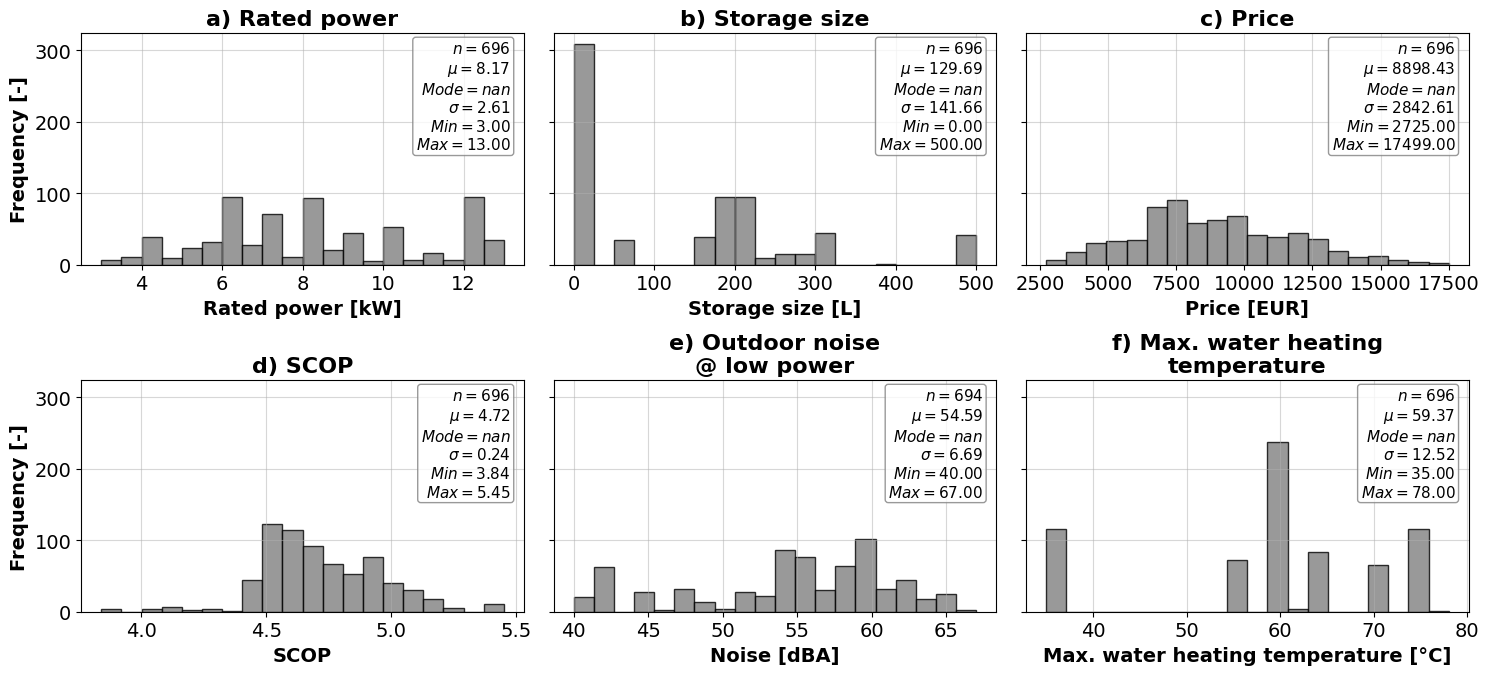

In [9]:
import math
import matplotlib.pyplot as plt
from scipy.stats import mode

# Use feature_label_map to get label dictionary info or fallback to default
def get_label(col):
    entry = feature_label_map.get(col)
    if isinstance(entry, dict):
        return entry.get('label', col)
    return col

def get_title(col):
    entry = feature_label_map.get(col)
    if isinstance(entry, dict):
        return entry.get('title', get_label(col))
    return get_label(col)

columns = [
    "Rated Power medium T [kW]",
    "Storage Size (L)",
    "Price",
    "SCOP",
    "SPL outdoor low Power [dBA]",
    "Max. water heating temperature [°C]"
]
num_cols = len(columns)

ncols = 3
nrows = math.ceil(num_cols / ncols)
figsize = (15, 7)

sharey_setting = True
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharey=sharey_setting)
axs = axs.flatten()

subplot_labels = [f"{chr(97 + i)})" for i in range(num_cols)]

# First, calculate max y value across all plots (histograms and bar plots)
global_max_y = 0
plot_types = []
plot_datas = []

for i, col in enumerate(columns):
    data = df[col].dropna()
    coltype = df[col].dtype
    if pd.api.types.is_numeric_dtype(coltype):
        counts, _ = np.histogram(data, bins=20)
        y_max = counts.max() if len(counts) else 0
        plot_types.append("hist")
        plot_datas.append(data)
    elif pd.api.types.is_categorical_dtype(coltype) or df[col].nunique() < 25:
        vc = data.value_counts().sort_values(ascending=False)
        y_max = vc.max() if len(vc) else 0
        plot_types.append("bar")
        plot_datas.append(vc)
    else:
        vc = data.astype(str).value_counts().sort_values(ascending=False).head(20)
        y_max = vc.max() if len(vc) else 0
        plot_types.append("bar")
        plot_datas.append(vc)
    global_max_y = max(global_max_y, y_max)

for i, col in enumerate(columns):
    ax = axs[i]
    x_lab = get_label(col)
    title_str = f"{subplot_labels[i]} {get_title(col)}"

    # Calculate extended statistics
    data = df[col].dropna()
    is_numeric = pd.api.types.is_numeric_dtype(df[col].dtype)
    n = len(data)
    if is_numeric:
        mean = data.mean()
        std = data.std()
        min_val = data.min()
        max_val = data.max()
        try:
            mode_val = mode(data, nan_policy='omit')[0][0]
        except Exception:
            mode_val = np.nan
        stats_text = (
            f"$n={n}$\n"
            f"$\\mu={mean:.2f}$\n"
            f"$Mode={mode_val:.2f}$\n"
            f"$\\sigma={std:.2f}$\n"
            f"$Min={min_val:.2f}$\n"
            f"$Max={max_val:.2f}$"
        )
    else:
        # For categorical/bar, show n, mode (most frequent), min/max category
        try:
            mode_val = mode(data.astype(str), nan_policy='omit')[0][0]
        except Exception:
            mode_val = "n/a"
        min_val = str(data.min()) if not data.empty else "n/a"
        max_val = str(data.max()) if not data.empty else "n/a"
        stats_text = (
            f"$n={n}$\n"
            f"$Mode={mode_val}$\n"
            f"$Min={min_val}$\n"
            f"$Max={max_val}$"
        )

    is_leftmost = (i % ncols == 0)
    if plot_types[i] == "hist":
        data = plot_datas[i]
        ax.hist(data, bins=20, color='gray', edgecolor='k', alpha=0.8)
        if (not sharey_setting) or is_leftmost:
            ax.set_ylabel("Frequency [-]")
        ax.set_xlabel(x_lab)
        ax.set_title(title_str)
        ax.set_ylim(0, global_max_y * 1.05)
    else:
        vc = plot_datas[i]
        vc.plot(kind='bar', ax=ax, color='gray', edgecolor='k', alpha=0.8)
        ax.set_title(title_str)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        if (not sharey_setting) or is_leftmost:
            ax.set_ylabel("Frequency [-]")
        ax.set_xlabel(x_lab)
        ax.set_ylim(0, global_max_y * 1.05)

    # Insert the stats box (top right for histogram, top left for bar)
    bbox_props = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="gray", alpha=0.8)
    if plot_types[i] == "hist":
        ax.text(
            0.97, 0.97, stats_text,
            transform=ax.transAxes, ha='right', va='top',
            fontsize=11, bbox=bbox_props
        )
    else:
        ax.text(
            0.03, 0.97, stats_text,
            transform=ax.transAxes, ha='left', va='top',
            fontsize=11, bbox=bbox_props
        )

    ax.tick_params(axis='both', which='major')

# Delete extra unused axes, if any
for j in range(i+1, nrows*ncols):
    fig.delaxes(axs[j])

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


In [10]:
for col in df.columns:
    print(col)

Manufacturer
Model
Titel
Date
Model/Type
Price
Currency
Website
Date_scraped
Type
Subtype
Group
Config
Storage
Storage Size (L)
Rated Power low T [kW]
Rated Power medium T [kW]
Refrigerant
Mass of Refrigerant [kg]
SPL indoor low Power [dBA]
SPL outdoor low Power [dBA]
SPL indoor high Power [dBA]
SPL outdoor high Power [dBA]
Bivalence temperature [°C]
Tolerance temperature [°C]
Max. water heating temperature [°C]
Power heating rod low T [kW]
Power heating rod medium T [kW]
Poff [W]
PTOS [W]
PSB [W]
PCKS [W]
eta low T [%]
eta medium T [%]
SCOP
SEER low T
SEER medium T
P_th_h_ref [W]
P_th_c_ref [W]
P_el_h_ref [W]
P_el_c_ref [W]
COP_ref
EER_c_ref
Configuration_Group


In [11]:
monoblock_mean = df.loc[df['Config'] == 'monoblock', 'Price'].mean()
split_mean = df.loc[df['Config'] == 'split', 'Price'].mean()

abs_diff = abs(monoblock_mean - split_mean)
rel_diff = abs_diff / ((monoblock_mean + split_mean) / 2) * 100  # Relative to the mean of both

print(f"Average cost of HPS with config 'monoblock': {monoblock_mean:.2f}")
print(f"Average cost of HPS with config 'split': {split_mean:.2f}")
print(f"Absolute difference: {abs_diff:.2f}")
print(f"Relative difference: {rel_diff:.2f}%")

# Calculate price per kW for each heat pump, then take the average
price_per_kw_each = df['Price'] / df['Rated Power medium T [kW]']
avg_price_per_kw = price_per_kw_each.mean()
print(f"Average price per kW (average of per-HP values): {avg_price_per_kw:.2f}")



Average cost of HPS with config 'monoblock': 9813.22
Average cost of HPS with config 'split': 7842.02
Absolute difference: 1971.20
Relative difference: 22.33%
Average price per kW (average of per-HP values): 1161.56


In [50]:
### Add some features

manufacturer_region_map = {
    'Bosch': 'European',
    'Viessmann': 'European',
    'AIT': 'European',
    'Buderus': 'European',
    'Vaillant': 'European',
    'Wolf': 'European',
    'Daikin': 'Japanese',
    'Mitsubishi': 'Japanese',
    'Panasonic': 'Japanese',
    'Toshiba': 'Japanese',
    'Johnson / Hitachi': 'Japanese',
    'Samsung': 'Korean',
    'LG': 'Korean'
}

def add_region_features(df, region_encoding='label'):
    """
    Add region features to df:
    - 'label' (default): Region column as current (European, Japanese, etc)
    - 'binary': Region column is 1 if European, 0 otherwise
    In all cases, also add Region_str which is 'EU' or 'non-EU'
    """
    # Add categorical region label
    def get_region(manufacturer):
        for name, region in manufacturer_region_map.items():
            if name.lower() in (str(manufacturer) or "").lower():
                return region
        return "Other"
    
    # Add high-level EU/non-EU string
    def get_region_str(manufacturer):
        reg = get_region(manufacturer)
        return "EU" if reg == "European" else "non-EU"

    # Assign Region by encoding
    if region_encoding == 'label':
        df["Region"] = df["Manufacturer"].apply(get_region)
    elif region_encoding == 'binary':
        df["Region"] = df["Manufacturer"].apply(
            lambda x: 1 if get_region(x) == 'European' else 0
        )
    else:
        raise ValueError("region_encoding must be either 'label' or 'binary'")

    # Always add Region_str
    df["Region_str"] = df["Manufacturer"].apply(get_region_str)
    return df

# Default: keep "Region" as binary and add Region_str (EU/non-EU)
df = add_region_features(df, region_encoding='binary')

print(df["Region"].value_counts())
print(df["Region_str"].value_counts())

Region
0    413
1    283
Name: count, dtype: int64
Region_str
non-EU    413
EU        283
Name: count, dtype: int64


In [51]:
# Print descriptive statistics
desc.print_descriptive_stats(df)



DESCRIPTIVE STATISTICS FOR HEAT PUMP DATA

Dataset Overview:
Total number of records: 696
Number of manufacturers: 13

PRICE DISTRIBUTION (EUR):
Count: 696
Mean: 8898.43
Median: 8573.24
Mode: 10999.0
Standard Deviation: 2842.61
Min: 2725.00
Max: 17499.00
25th percentile: 6979.25
75th percentile: 10844.00
Interquartile Range: 3864.75

SCOP VALUES:
Count: 696
Mean: 4.72
Median: 4.68
Mode: 4.55
Standard Deviation: 0.24
Min: 3.84
Max: 5.45

RATED POWER LOW T (kW):
Count: 696
Mean: 8.25
Median: 8.00
Mode: 6.0
Standard Deviation: 2.51
Min: 3.44
Max: 13.00

NOISE LEVELS - SPL OUTDOOR HIGH POWER (dBA):
Count: 696
Mean: 54.65
Median: 56.00
Mode: 54.0
Standard Deviation: 6.69
Min: 40.00
Max: 69.00

MAX WATER HEATING TEMPERATURE (°C):
Count: 696
Mean: 59.37
Median: 60.00
Mode: 60.0
Standard Deviation: 12.52
Min: 35.00
Max: 78.00

PRICE BY MANUFACTURER:
                                                          count      mean    median      std
Manufacturer                                        

In [52]:
from IPython.display import display
import pandas as pd
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 50)




0      Below or equal mean
1      Below or equal mean
2      Below or equal mean
3      Below or equal mean
4      Below or equal mean
              ...         
691             Above mean
692             Above mean
693             Above mean
694             Above mean
695             Above mean
Name: Power_mean_group, Length: 696, dtype: object

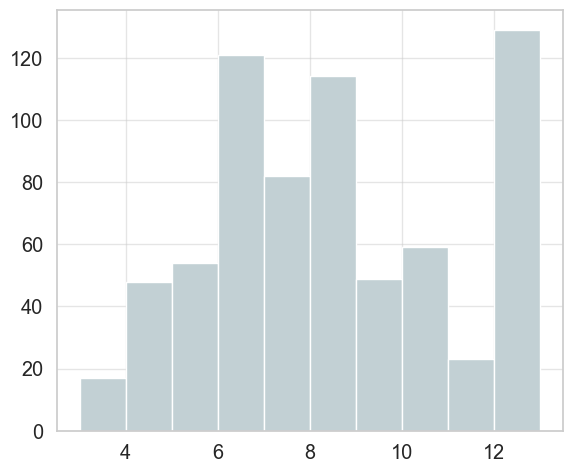

In [53]:
df["Rated Power medium T [kW]"].hist()

# Create a new column 'Power_mean_group' that divides rows into two groups: above and below (or equal to) the mean of "Rated Power medium T [kW]"
mean_power = df["Rated Power medium T [kW]"].mean()
df["Power_mean_group"] = df["Rated Power medium T [kW]"].apply(lambda x: "Above mean" if x > mean_power else "Below or equal mean")
df["Power_mean_group"]

Pearson correlation between Price and SCOP: r=0.123, p-value=0.0012
Spearman correlation between Price and SCOP: r=0.146, p-value=0.0001
There is a statistically significant association between model price and SCOP.


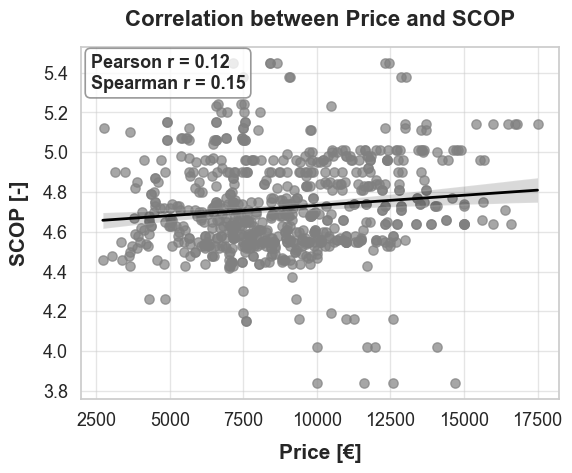

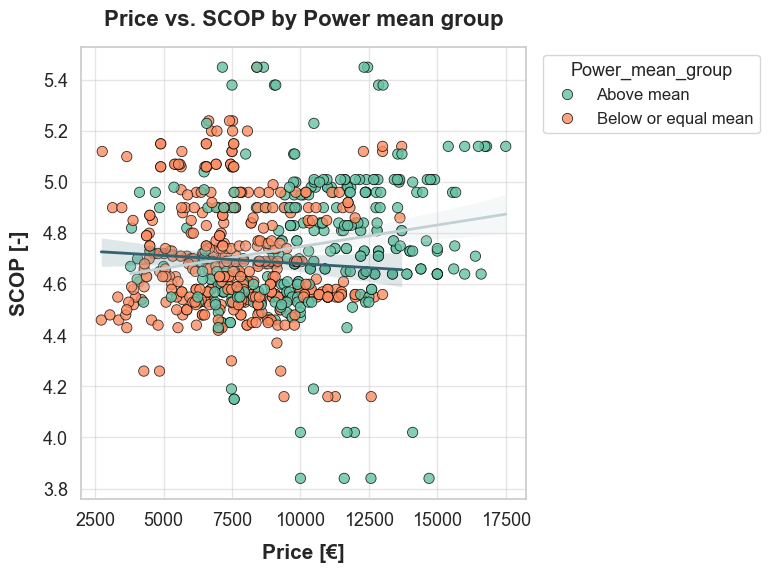

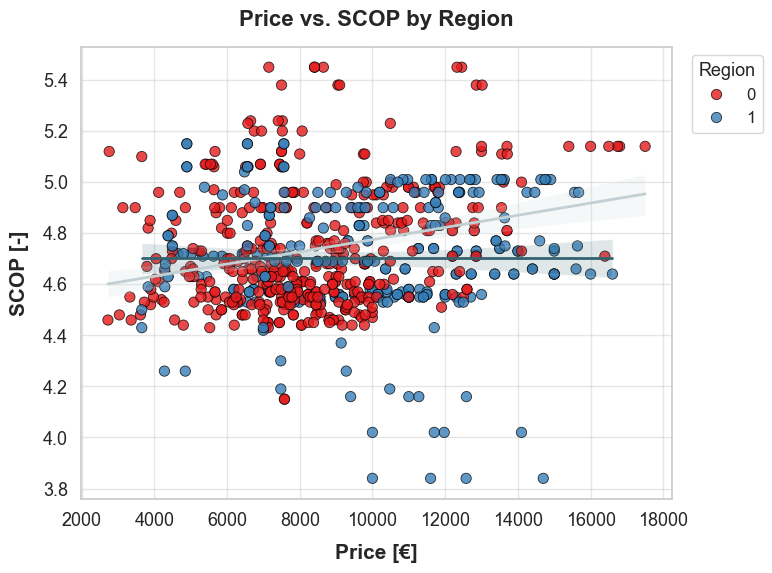

In [54]:
# Statistical test: Are more expensive models associated with higher SCOP?
import scipy.stats as stats
import numpy as np

# Drop rows with missing values for the relevant columns
test_df = df[['Price', 'SCOP']].dropna()

# Option 1: Pearson correlation (linear association)
pearson_corr, pearson_p = stats.pearsonr(test_df['Price'], test_df['SCOP'])
print(f"Pearson correlation between Price and SCOP: r={pearson_corr:.3f}, p-value={pearson_p:.4f}")

# Option 2: Spearman correlation (monotonic association, robust to outliers)
spearman_corr, spearman_p = stats.spearmanr(test_df['Price'], test_df['SCOP'])
print(f"Spearman correlation between Price and SCOP: r={spearman_corr:.3f}, p-value={spearman_p:.4f}")

# Short text interpretation
if pearson_p < 0.05 or spearman_p < 0.05:
    print("There is a statistically significant association between model price and SCOP.")
else:
    print("No statistically significant association detected between model price and SCOP.")

import matplotlib.pyplot as plt
import seaborn as sns

# Set white grid style for clarity and white background
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.3)

# -- Plot 1: as before --
fig, ax = plt.subplots(figsize=(6, 5), facecolor='white')

sns.regplot(
    data=test_df,
    x="Price",
    y="SCOP",
    ax=ax,
    scatter_kws={'alpha': 0.7, 's': 45, 'color': 'gray'},
    line_kws={'color': 'black', 'lw': 2}
)

ax.set_xlabel("Price [€]", fontsize=15, fontweight='bold', labelpad=10)
ax.set_ylabel("SCOP [-]", fontsize=15, fontweight='bold', labelpad=10)
ax.set_title("Correlation between Price and SCOP", fontsize=16, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=13)

# Annotate Pearson r
ax.text(
    0.02, 0.98,
    f"Pearson r = {pearson_corr:.2f}\nSpearman r = {spearman_corr:.2f}",
    ha="left", va="top",
    fontsize=13,
    fontweight='bold',
    transform=ax.transAxes,
    bbox=dict(facecolor="white", edgecolor="gray", linewidth=1.2, alpha=0.8, boxstyle="round,pad=0.3")
)

# Make background white (in case style is overridden)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

# --- Additional plot: Same as above, but divided by power group ---

power_group_col = None
if 'Power_mean_group' in df.columns:
    power_group_col = 'Power_mean_group'
else:
    power_group_col = None

if power_group_col is not None:
    # Merge Power_new into test_df for plotting
    test_df_power = test_df.merge(
        df[[power_group_col]], left_index=True, right_index=True, how='left'
    )

    # Sort legend order if categorical
    group_order = None
    if pd.api.types.is_categorical_dtype(df[power_group_col]):
        group_order = df[power_group_col].cat.categories.tolist()
    else:
        group_order = sorted(test_df_power[power_group_col].dropna().unique())

    plt.figure(figsize=(8, 6))
    ax2 = plt.gca()
    sns.scatterplot(
        data=test_df_power,
        x="Price",
        y="SCOP",
        hue=power_group_col,
        palette="Set2",
        alpha=0.8,
        s=55,
        ax=ax2,
        hue_order=group_order,
        edgecolor="k"
    )
    # Add regression line per group
    for group in group_order:
        data_sub = test_df_power[test_df_power[power_group_col] == group]
        if len(data_sub) > 1:
            sns.regplot(
                data=data_sub,
                x="Price",
                y="SCOP",
                scatter=False,
                ax=ax2,
                line_kws={'lw': 2},
                label=None
            )

    ax2.set_xlabel("Price [€]", fontsize=15, fontweight='bold', labelpad=10)
    ax2.set_ylabel("SCOP [-]", fontsize=15, fontweight='bold', labelpad=10)
    title_str = f"Price vs. SCOP by {power_group_col.replace('_',' ')}"
    ax2.set_title(title_str, fontsize=16, fontweight='bold', pad=15)
    ax2.tick_params(axis='both', labelsize=13)
    ax2.set_facecolor('white')
    plt.legend(title=power_group_col, fontsize=12, title_fontsize=13, bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No Power_new column found for the grouped plot.")

# --- Additional plot: Price vs. SCOP by Region ---
if 'Region' in df.columns:
    # Merge Region column into test_df for plotting
    test_df_region = test_df.merge(
        df[['Region']],
        left_index=True,
        right_index=True,
        how='left'
    )

    # Get unique order of Region (sorted for consistency)
    region_order = sorted(test_df_region["Region"].dropna().unique())

    plt.figure(figsize=(8, 6))
    ax3 = plt.gca()
    sns.scatterplot(
        data=test_df_region,
        x="Price",
        y="SCOP",
        hue="Region",
        palette="Set1",
        alpha=0.8,
        s=55,
        ax=ax3,
        hue_order=region_order,
        edgecolor="k"
    )
    # Add regression line per region (if enough points)
    for region in region_order:
        data_sub = test_df_region[test_df_region["Region"] == region]
        if len(data_sub) > 1:
            sns.regplot(
                data=data_sub,
                x="Price",
                y="SCOP",
                scatter=False,
                ax=ax3,
                line_kws={'lw': 2},
                label=None
            )

    ax3.set_xlabel("Price [€]", fontsize=15, fontweight='bold', labelpad=10)
    ax3.set_ylabel("SCOP [-]", fontsize=15, fontweight='bold', labelpad=10)
    ax3.set_title("Price vs. SCOP by Region", fontsize=16, fontweight='bold', pad=15)
    ax3.tick_params(axis='both', labelsize=13)
    ax3.set_facecolor('white')
    plt.legend(title="Region", fontsize=12, title_fontsize=13, bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No Region column found for the grouped plot.")



[Analysis across ALL configs – not split by config]

Pearson correlation between Price and SCOP per group (by storage tank):
 - Tank size group 'No tank': r=0.10, p=0.0773  (n=308)
 - Tank size group '> 100 L': r=0.20, p=0.0002  (n=353)
 - Tank size group '0 < size ≤ 100 L': r=0.57, p=0.0004  (n=35)


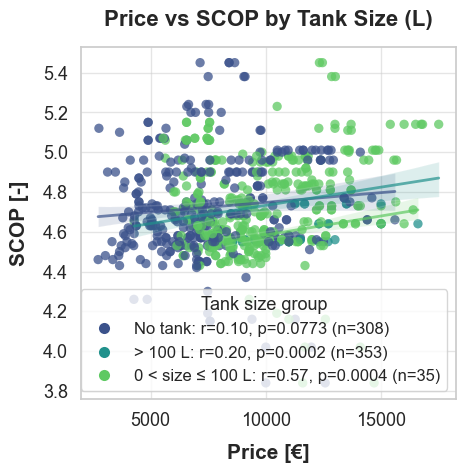

In [55]:


# -----------------------------
# Plot and analyze grouped by Power_bin (or Power_Group), *NOT* split by config

from scipy.stats import pearsonr

# Try to detect power column (Power_bin or Power_Group or Rated Power low T [kW])
power_group_col = None
if 'Power_bin' in df.columns:
    power_group_col = 'Power_bin'
elif 'Power_Group' in df.columns:
    power_group_col = 'Power_Group'
elif 'Rated Power low T [kW]' in df.columns:
    power_group_col = 'Rated Power low T [kW]'
else:
    raise ValueError("No power group column found! Please adjust the code to provide a power group.")

# Prepare DataFrame with grouping and relevant columns
columns_needed = ['Price', 'SCOP', power_group_col, 'Refrigerant', "Config", "Storage", "Storage Size (L)"]
columns_to_merge = [col for col in columns_needed if col not in test_df.columns and col in df.columns]
if columns_to_merge:
    colored_df = test_df.merge(
        df[columns_to_merge],
        left_index=True,
        right_index=True,
        how='left'
    )
else:
    colored_df = test_df.copy()

def analyze_by_power_or_tank_global(colored_df, group_col, by_tank=False):
    """
    by_tank: if True, plot SCOP vs Price grouped by Storage Size (L) bins; else by power group.
    """
    if by_tank:
        tank_col = "Storage Size (L)"
        df_with_tank = colored_df.copy()
        # Define explicit bins: 0 (no tank), (0,100], >100
        bins = [-0.1, 0, 100, float('inf')]
        labels = ["No tank", "0 < size ≤ 100 L", "> 100 L"]
        df_with_tank["Tank_bin"] = pd.cut(df_with_tank[tank_col].fillna(-0.01), bins=bins, labels=labels)
        group_labels = df_with_tank["Tank_bin"].dropna().unique()
        color_col = "Tank_bin"
    else:
        df_with_tank = colored_df.copy()
        group_labels = df_with_tank[group_col].dropna().unique()
        color_col = group_col

    n_colors = len(group_labels)
    palette = sns.color_palette("viridis", n_colors=n_colors)

    fig, ax = plt.subplots(figsize=(5, 5), facecolor='white')

    sns.scatterplot(
        data=df_with_tank,
        x="Price",
        y="SCOP",
        hue=color_col,
        palette=palette,
        s=45,
        alpha=0.75,
        ax=ax,
        edgecolor="none"
    )

    # For printing correlations per group
    pearson_results = []

    for i, group in enumerate(group_labels):
        group_data = df_with_tank[df_with_tank[color_col] == group]
        if len(group_data) > 1:
            pearson_corr, pearson_p = pearsonr(group_data["Price"], group_data["SCOP"])
            pearson_results.append((group, pearson_corr, pearson_p, len(group_data)))
            sns.regplot(
                data=group_data,
                x="Price",
                y="SCOP",
                scatter=False,
                line_kws={'color': palette[i], 'lw': 2, 'alpha': 0.7},
                ax=ax
            )

    title_label = "Tank size group" if by_tank else group_col
    print(f"\nPearson correlation between Price and SCOP per group ({'by storage tank' if by_tank else 'power'}):")
    stats_lines = []
    for idx, (group, r, p, n) in enumerate(pearson_results):
        print(f" - {title_label} '{group}': r={r:.2f}, p={p:.4f}  (n={n})")
        stats_lines.append(f"{group}: r={r:.2f}, p={p:.4f} (n={n})")
    # Combine all stats into a single annotation string
    stats_text = "\n".join(stats_lines)
    # Place the annotation at a fixed location within the plot area
    # (e.g., upper left inside axes)
    # Place annotation text (correlations) *inside* the legend, replacing the default legend labels
    # by custom ones that combine group label with correlation.
    # Regenerate handles such that each legend entry has a colored marker (with its group color)
    from matplotlib.lines import Line2D

    legend_labels = []
    legend_handles = []

    for idx, (group, r, p, n) in enumerate(pearson_results):
        label = f"{group}: r={r:.2f}, p={p:.4f} (n={n})"
        legend_labels.append(label)
        # Use the color for each group in palette for the marker
        marker_handle = Line2D(
            [0], [0], marker='o', color='none',
            markerfacecolor=palette[idx], markeredgecolor='none',
            markersize=8, linestyle='None'
        )
        legend_handles.append(marker_handle)

    ax.legend(
        handles=legend_handles,
        labels=legend_labels,
        title=title_label,
        loc='lower right',
        fontsize=12,
        title_fontsize=13
    )

    ax.set_xlabel("Price [€]", fontsize=15, fontweight='bold', labelpad=10)
    ax.set_ylabel("SCOP [-]", fontsize=15, fontweight='bold', labelpad=10)
    main_title = f"Price vs SCOP by {'Tank Size (L)' if by_tank else group_col}"
    ax.set_title(main_title, fontsize=16, fontweight='bold', pad=15)
    ax.tick_params(axis='both', labelsize=13)
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    # ax.legend(title=title_label, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=13)
    plt.tight_layout()
    plt.show()

# OPTION: Set `split_on_tank` to True to analyze by tank size (0, 0-100, >100); False for power group plot
split_on_tank = True   # Set to True to split and color by tank size (L) as above

# Just plot globally by power group or by tank, do NOT split by config
print("\n[Analysis across ALL configs – not split by config]")
analyze_by_power_or_tank_global(colored_df, power_group_col, by_tank=split_on_tank)

# ---- Deeper analysis for <7kW group for negative correlation ----

# If not splitting on tank, continue <7kW deep dive as before
if not split_on_tank:
    group_labels = colored_df[power_group_col].dropna().unique()
    # Try to identify the label in Power_bin for the <7kW group
    possible_labels = ['≤ 7 kW', '<7kW', '<6kW', '≤7kW', '≤ 7kW', '6-9kW', '6-9 kW']
    found_label = None
    for label in possible_labels:
        if label in group_labels:
            found_label = label
            break
    if found_label is None:
        # Fall back to group with min median power, if Power_bin looks like 'x–y kW'
        try:
            import re
            def min_power(l):
                numbers = re.findall(r'[\d.]+', str(l))
                return float(numbers[0]) if numbers else float('inf')
            found_label = min(group_labels, key=min_power)
        except Exception:
            pass

    if found_label is not None:
        group_df = colored_df[colored_df[power_group_col] == found_label]
        print(f"\n--- Investigating why the correlation in the '{found_label}' group (<7kW) is negative ---")
        print(f"Number of records in <7kW group: {len(group_df)}")
        # Focus on: Config, Storage, Storage Size (L), Refrigerant

        # 1. Refrigerant distribution
        if "Refrigerant" in group_df.columns:
            print("\nRefrigerant breakdown in <7kW group:")
            print(group_df["Refrigerant"].value_counts(dropna=False))
        else:
            print("\n'Refrigerant' column not available.")

        # 2. Config distribution
        if "Config" in group_df.columns:
            print("\nConfig breakdown in <7kW group:")
            print(group_df["Config"].value_counts(dropna=False))
        else:
            print("\n'Config' column not available.")

        # 3. Storage & Storage Size distribution
        if "Storage" in group_df.columns:
            print("\nStorage breakdown in <7kW group:")
            print(group_df["Storage"].value_counts(dropna=False))
        else:
            print("\n'Storage' column not available.")

        if "Storage Size (L)" in group_df.columns:
            print("\nStorage Size (L) statistics in <7kW group:")
            print(group_df["Storage Size (L)"].describe())
        else:
            print("\n'Storage Size (L)' column not available.")

        # 4. Correlation of Storage Size (L) with Price and SCOP
        if "Storage Size (L)" in group_df.columns:
            valid_pairs = group_df[["Storage Size (L)", "SCOP", "Price"]].dropna()
            if len(valid_pairs) > 1:
                corr_scop = valid_pairs["Storage Size (L)"].corr(valid_pairs["SCOP"])
                corr_price = valid_pairs["Storage Size (L)"].corr(valid_pairs["Price"])
                print(f"\nCorrelation of Storage Size (L) with SCOP: {corr_scop:.2f}")
                print(f"Correlation of Storage Size (L) with Price: {corr_price:.2f}")
        # 5. Mean SCOP and Price by Config
        if "Config" in group_df.columns:
            print("\nMean SCOP and Price by Config in <7kW group:")
            print(group_df.groupby("Config")[["SCOP", "Price"]].mean().sort_values("Price", ascending=False))

        # 6. Mean SCOP and Price by Refrigerant
        if "Refrigerant" in group_df.columns:
            print("\nMean SCOP and Price by Refrigerant in <7kW group:")
            print(group_df.groupby("Refrigerant")[["SCOP", "Price"]].mean().sort_values("Price", ascending=False))

        # 7. Combined analysis: High price/low SCOP association
        print("\nSome potential reasons for the unexpected negative correlation in <7kW group:")
        print("""
    - If more expensive <7kW models are disproportionately using a certain refrigerant, configuration (Config), or have larger 'Storage' or 'Storage Size (L)' tanks, and these specific combinations tend to have a lower SCOP, this can cause the negative correlation.
    - For example, expensive <7kW systems might be packaged with large hot water storage tanks or hydraulic modules, which may add cost but may not improve (or may even reduce) the quoted SCOP due to system losses or the customs of reporting in those product segments.
    - Or, a refrigerant choice that is present only in higher-priced models might be less efficient for this power group.
    - Additionally, if for some reason the more expensive configs in <7kW are assigned to applications or subtypes with lower SCOP (e.g., high hot water demand, special use-cases), this might also explain the trend.

    Please review the breakdowns above and consider the distribution and mean statistics for these variables. If high-priced models are associated with configurations or features that reduce SCOP, this could entirely explain the phenomenon.
            """)
    else:
        print("\nCould not locate a <7kW power group label for detailed analysis.")


Pearson correlation between Price and SCOP: r=0.123, p-value=0.0012
Spearman correlation between Price and SCOP: r=0.146, p-value=0.0001
There is a statistically significant association between model price and SCOP.


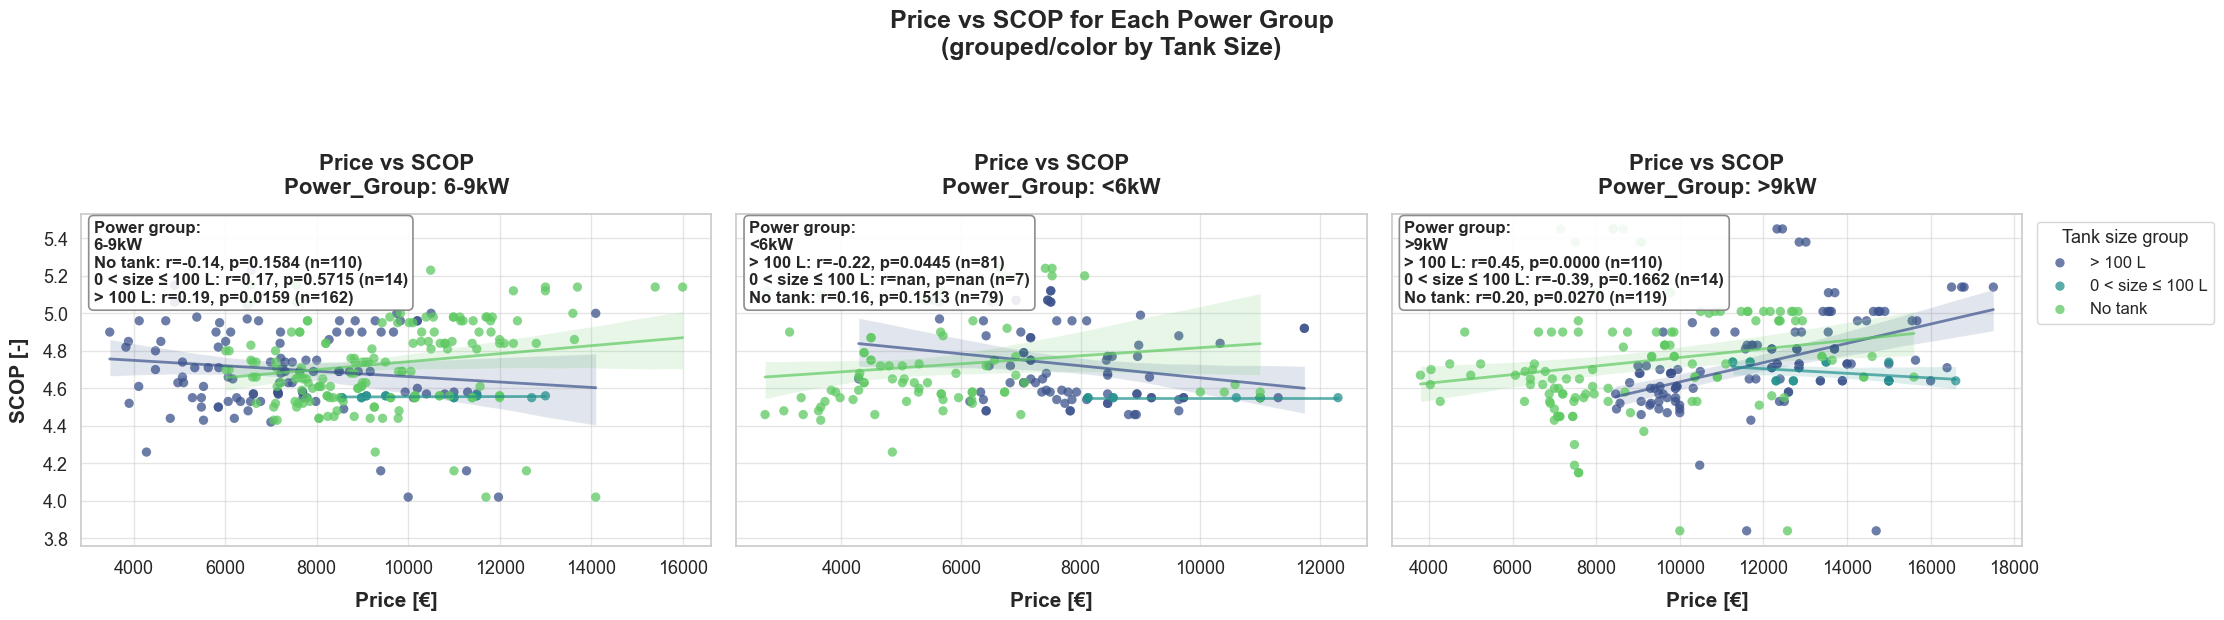

In [56]:
# Statistical test: Are more expensive models associated with higher SCOP?
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Drop rows with missing values for the relevant columns
test_df = df[['Price', 'SCOP']].dropna()

# Option 1: Pearson correlation (linear association)
pearson_corr, pearson_p = stats.pearsonr(test_df['Price'], test_df['SCOP'])
print(f"Pearson correlation between Price and SCOP: r={pearson_corr:.3f}, p-value={pearson_p:.4f}")

# Option 2: Spearman correlation (monotonic association, robust to outliers)
spearman_corr, spearman_p = stats.spearmanr(test_df['Price'], test_df['SCOP'])
print(f"Spearman correlation between Price and SCOP: r={spearman_corr:.3f}, p-value={spearman_p:.4f}")

# Short text interpretation
if pearson_p < 0.05 or spearman_p < 0.05:
    print("There is a statistically significant association between model price and SCOP.")
else:
    print("No statistically significant association detected between model price and SCOP.")

# Try to detect power column (Power_bin or Power_Group or Rated Power low T [kW])
power_group_col = None
if 'Power_bin' in df.columns:
    power_group_col = 'Power_bin'
elif 'Power_Group' in df.columns:
    power_group_col = 'Power_Group'
elif 'Rated Power low T [kW]' in df.columns:
    power_group_col = 'Rated Power low T [kW]'
else:
    raise ValueError("No power group column found! Please adjust the code to provide a power group.")

columns_needed = ['Price', 'SCOP', power_group_col, 'Refrigerant', "Config", "Storage", "Storage Size (L)"]
columns_to_merge = [col for col in columns_needed if col not in test_df.columns and col in df.columns]
if columns_to_merge:
    colored_df = test_df.merge(
        df[columns_to_merge],
        left_index=True,
        right_index=True,
        how='left'
    )
else:
    colored_df = test_df.copy()

# -- Multi-panel analysis: by Power group, always grouped/color by tank size --
import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # For seaborn color warnings

# Identify up to three main power groups (sorted by unique values/coverage)
all_power_values = colored_df[power_group_col].dropna().unique()
# Try to order the groups meaningfully
def parse_kW(label):
    import re
    # Try to get a representative value for sorting
    nums = re.findall(r'[\d.]+', str(label))
    if not nums:
        if "no" in str(label).lower():
            return 0
        return 1e9
    else:
        return float(nums[0])
try:
    sorted_power_labels = sorted(all_power_values, key=parse_kW)
except Exception:
    sorted_power_labels = list(all_power_values)
# Take up to 3 groups for subplots
n_groups = 3
chosen_power_groups = sorted_power_labels[:n_groups]

# Define tank size bins
tank_col = "Storage Size (L)"
bins = [-0.1, 0, 100, float('inf')]
labels = ["No tank", "0 < size ≤ 100 L", "> 100 L"]

fig, axes = plt.subplots(1, n_groups, figsize=(7.5 * n_groups, 6), facecolor='white', sharey=True)
if n_groups == 1:
    axes = [axes]

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.3)

# For collecting correlation/stat for textbox
for i, group in enumerate(chosen_power_groups):
    ax = axes[i]
    group_df = colored_df[colored_df[power_group_col] == group].copy()
    group_df["Tank_bin"] = pd.cut(group_df[tank_col].fillna(-0.01), bins=bins, labels=labels)
    tank_bins_present = group_df["Tank_bin"].dropna().unique()
    n_colors = len(tank_bins_present)
    palette = sns.color_palette("viridis", n_colors=n_colors)

    # Scatter plot
    for j, tank in enumerate(tank_bins_present):
        tank_df = group_df[group_df["Tank_bin"] == tank]
        ax.scatter(
            tank_df["Price"], tank_df["SCOP"],
            label=str(tank),
            s=45, alpha=0.75, color=palette[j], edgecolor='none'
        )
        if len(tank_df) > 1:
            # Regression line for this tank bin
            sns.regplot(
                data=tank_df, x="Price", y="SCOP",
                scatter=False, line_kws={'color': palette[j], 'lw': 2, 'alpha': 0.7}, ax=ax
            )

    # Pearson per tank bin, collect all data for textbox
    msg_lines = []
    msg_lines.append(f"Power group:\n{group}")
    for j, tank in enumerate(tank_bins_present):
        tank_df = group_df[group_df["Tank_bin"] == tank]
        n = len(tank_df)
        if n > 1:
            pearson_corr, pearson_p = stats.pearsonr(tank_df["Price"], tank_df["SCOP"])
            msg_lines.append(
                f"{tank}: r={pearson_corr:.2f}, p={pearson_p:.4f} (n={n})"
            )
        else:
            msg_lines.append(f"{tank}: n={n}")
    textbox_str = "\n".join(msg_lines)
    # Place textbox in upper left corner of the subplot
    ax.text(
        0.02, 0.98, textbox_str,
        ha="left", va="top",
        transform=ax.transAxes,
        fontsize=12, fontweight='bold',
        bbox=dict(facecolor="white", edgecolor="gray", linewidth=1.2, alpha=0.9, boxstyle="round,pad=0.3")
    )
    ax.set_xlabel("Price [€]", fontsize=15, fontweight='bold', labelpad=10)
    if i == 0:
        ax.set_ylabel("SCOP [-]", fontsize=15, fontweight='bold', labelpad=10)
    else:
        ax.set_ylabel("")
    ax.set_title(f"Price vs SCOP\n{power_group_col}: {group}", fontsize=16, fontweight='bold', pad=15)
    ax.tick_params(axis='both', labelsize=13)
    ax.set_facecolor('white')
    handles, labels_ = ax.get_legend_handles_labels()
    # Only show legend for the rightmost subplot,
    # or if only one, show always
    if i == n_groups-1 or n_groups == 1:
        ax.legend(title="Tank size group", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12, title_fontsize=13)
    else:
        ax.get_legend().remove() if ax.get_legend() else None

fig.suptitle("Price vs SCOP for Each Power Group\n(grouped/color by Tank Size)", fontsize=18, fontweight='bold', y=1.04)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


In [57]:
df.Storage.value_counts()


Storage
warm-water tank     347
hydraulic module    272
none                 77
Name: count, dtype: int64

In [58]:
df.Config.value_counts()

Config
monoblock    373
split        323
Name: count, dtype: int64

In [59]:
df.Region.value_counts()

Region
0    413
1    283
Name: count, dtype: int64

<Axes: >

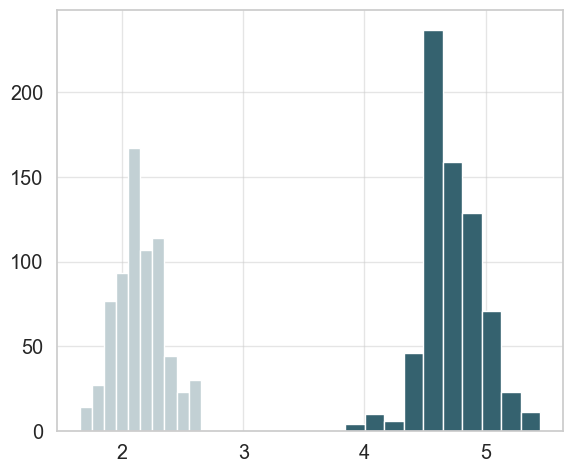

In [60]:
df.COP_ref.hist()
df.SCOP.hist()

In [61]:
df.Storage.value_counts()

Storage
warm-water tank     347
hydraulic module    272
none                 77
Name: count, dtype: int64

List of used features for modeling:
['Subtype', 'Group', 'Config', 'Storage', 'Storage Size (L)', 'Rated Power low T [kW]', 'Refrigerant', 'SPL indoor low Power [dBA]', 'SPL indoor high Power [dBA]', 'SPL outdoor high Power [dBA]', 'Bivalence temperature [°C]', 'Tolerance temperature [°C]', 'Max. water heating temperature [°C]', 'Poff [W]', 'PCKS [W]', 'eta low T [%]', 'SCOP', 'SEER low T', 'P_th_c_ref [W]', 'P_el_h_ref [W]', 'P_el_c_ref [W]', 'COP_ref', 'EER_c_ref', 'Configuration_Group', 'Region', 'Storage2', 'Region_str']
Train set: (522, 27), Test set: (174, 27)


Feature counts:   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Holdout MAE pivot:
model       GB_100  RandomForest_100t  RandomForest_300t
n                                                       
3      1189.668061        1240.884419        1319.165966
5      1143.226573        1193.660154        1271.411756
7      1142.158870        1200.518512        1295.358763

Holdout R2 pivot:
model    GB_100  RandomForest_100t  RandomForest_300t
n                                                    
3      0.692600           0.677780           0.650780
5      0.731431           0.710746           0.677083
7      0.734322           0.694555           0.654883

Holdout MAPE pivot:
model     GB_100  RandomForest_100t  RandomForest_300t
n                                                     
3      13.963682          14.471064          15.501063
5      13.359188          14.027252          14.989858
7      13.229069          14.189055          15.437660

CV MAE pivot:
model       GB_100  RandomForest_100t  RandomForest_300t
n                                      

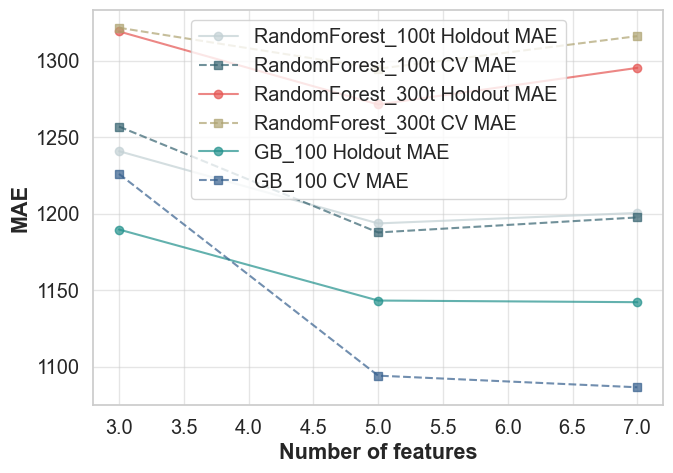


Detailed scores for best model (GB_100) with top-7 features:
Train set:
  MAE:  951.3
  R2:   0.809
  MAPE: 12.27%
Test set:
  MAE:  1,142.2
  R2:   0.734
  MAPE: 13.23%


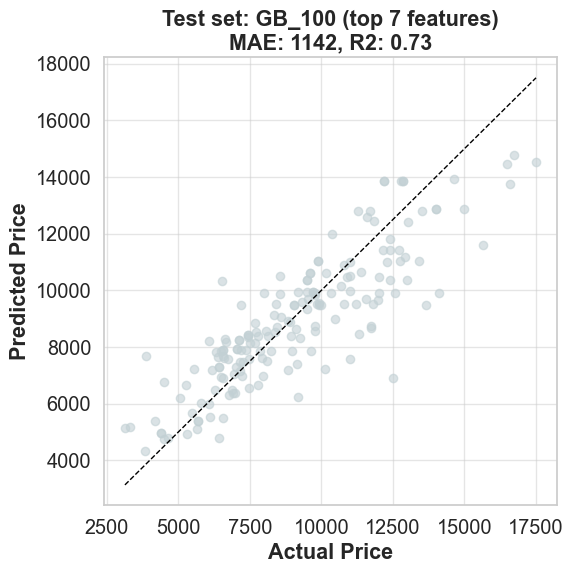

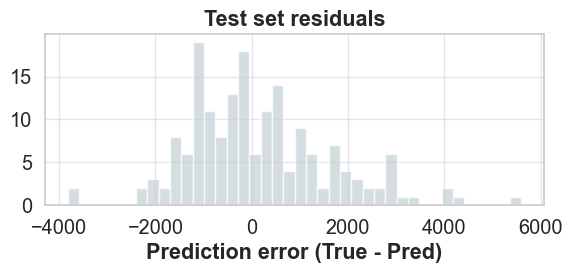


Performing SHAP analysis on best model...


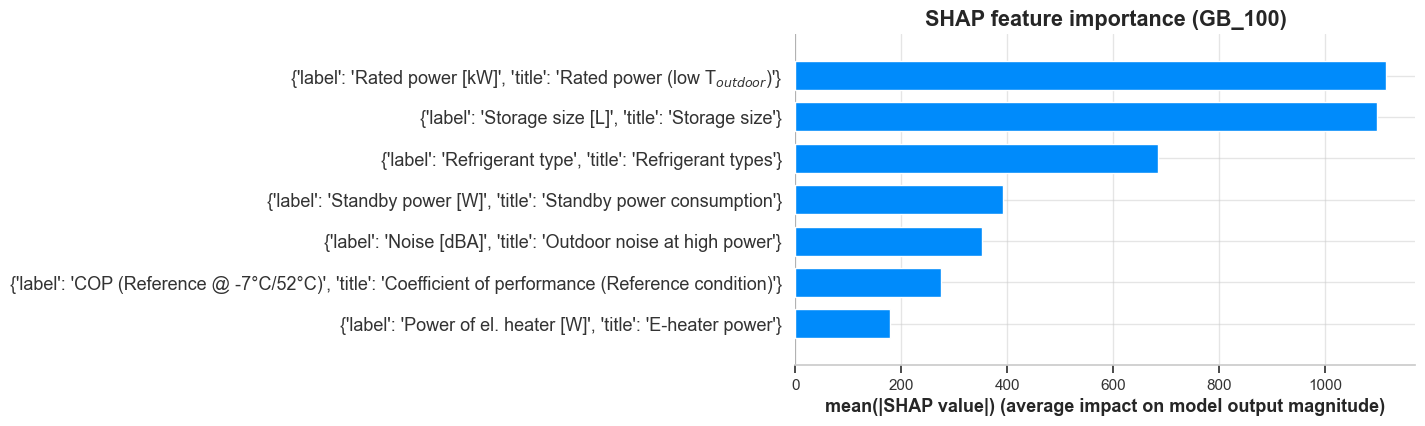

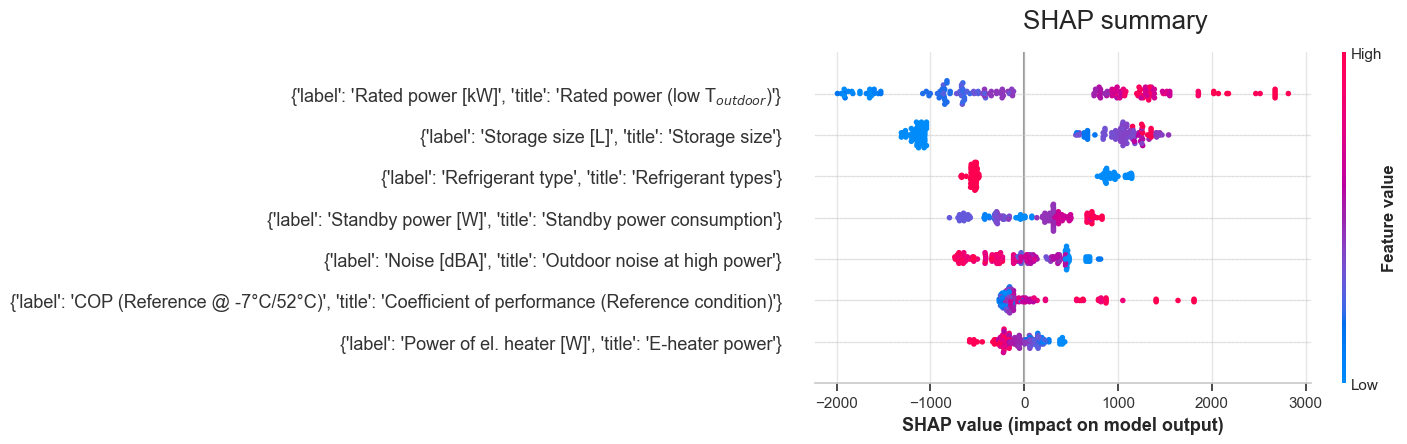

In [62]:
from tqdm.notebook import tqdm

# --- Quick/short data prep with robust pivot output ---
dfp = df.drop(columns=[
    "Manufacturer", "Date_scraped", "P_th_h_ref [W]", "PTOS [W]", 'eta medium T [%]',
    "Power heating rod medium T [kW]", "Power heating rod low T [kW]",
    "Currency", "PSB [W]",  "SPL outdoor low Power [dBA]" , "Power_mean_group", "Rated Power medium T [kW]"
], errors="ignore").copy()

# Drop columns with >70% NA and columns with only one unique value
dfp = dfp.loc[:, dfp.isnull().mean() < 0.7]
dfp = dfp.loc[:, dfp.nunique() > 1]

target = 'Price'
# Identify categorical columns with <30 unique values (excluding the target)
cat_cols = [c for c in dfp.select_dtypes('O').columns if c != target and dfp[c].nunique() < 30]
for c in cat_cols:
    dfp[c] = LabelEncoder().fit_transform(dfp[c].astype(str))

# Only use numeric (incl. encoded categoricals) for modeling, exclude the target
features = [c for c in dfp.columns if c != target and pd.api.types.is_numeric_dtype(dfp[c])]

# Print list of used features
print("List of used features for modeling:")
print(features)

# Drop rows with missing target
dfp = dfp.dropna(subset=[target])

# Impute remaining missing feature values with median
X = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(dfp[features]), columns=features)
y = dfp[target].values

# --- Train/test split, add cross-validation for model selection ---
from sklearn.model_selection import train_test_split, KFold, cross_val_score

Xtr, Xts, ytr, yts = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Train set: {Xtr.shape}, Test set: {Xts.shape}")

# Parameter grids: increase regularization or reduce complexity
n_list = [3, 5, 7]  # Reduce feature count to avoid overfitting
models = {
    "RandomForest_100t": RandomForestRegressor(
        random_state=0, n_estimators=100, max_depth=5, min_samples_leaf=10, max_features='sqrt', oob_score=False, n_jobs=-1
    ),
    "RandomForest_300t": RandomForestRegressor(
        random_state=0, n_estimators=300, max_depth=7, min_samples_leaf=20, max_features='sqrt', oob_score=False, n_jobs=-1
    ),
    "GB_100": GradientBoostingRegressor(
        random_state=0, n_estimators=100, max_depth=2, min_samples_leaf=10, subsample=0.7,
        learning_rate=0.07
    ),
    # "GB_200": GradientBoostingRegressor(
    #     random_state=0, n_estimators=200, max_depth=3, min_samples_leaf=15, subsample=0.7,
    #     learning_rate=0.05
    # )
}

# Get base feature importances from a random forest (fit only on train split)
rf_base = RandomForestRegressor(
    n_estimators=100, random_state=0, max_depth=5, min_samples_leaf=10, max_features='sqrt'
).fit(Xtr, ytr)
importances = pd.Series(rf_base.feature_importances_, index=X.columns).sort_values(ascending=False)

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

results = []
cv_outer = KFold(n_splits=3, shuffle=True, random_state=42)
for n in tqdm(n_list, desc="Feature counts"):
    topf = importances.head(n).index.to_list()
    for mdlname, mdl in tqdm(models.items(), leave=False):
        # Cross-validation (on train set only, simulating "dev set")
        cv_mae = -cross_val_score(mdl, Xtr[topf], ytr, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1).mean()
        cv_r2 = cross_val_score(mdl, Xtr[topf], ytr, cv=5, scoring='r2', n_jobs=-1).mean()
        cv_mape = -cross_val_score(mdl, Xtr[topf], ytr, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1).mean() * 100

        # Fit on train, test on holdout
        mdl.fit(Xtr[topf], ytr)
        pred = mdl.predict(Xts[topf])
        mae = mean_absolute_error(yts, pred)
        r2 = r2_score(yts, pred)
        mapev = mape(yts, pred)
        results.append({
            'n': n,
            'model': mdlname,
            'mae': mae,
            'r2': r2,
            'mape': mapev,
            'cv_mae': cv_mae,
            'cv_r2': cv_r2,
            'cv_mape': cv_mape,
            'features': topf
        })

resdf = pd.DataFrame(results)

# Pivot for MAE, R2, MAPE
print("Holdout MAE pivot:")
print(resdf.pivot_table(index='n', columns='model', values='mae'))
print("\nHoldout R2 pivot:")
print(resdf.pivot_table(index='n', columns='model', values='r2'))
print("\nHoldout MAPE pivot:")
print(resdf.pivot_table(index='n', columns='model', values='mape'))
print("\nCV MAE pivot:")
print(resdf.pivot_table(index='n', columns='model', values='cv_mae'))
print("\nCV R2 pivot:")
print(resdf.pivot_table(index='n', columns='model', values='cv_r2'))
print("\nCV MAPE pivot:")
print(resdf.pivot_table(index='n', columns='model', values='cv_mape'))

best = resdf.loc[resdf['cv_mae'].idxmin()]  # Select by lowest CV MAE, not holdout
print(f"\nBest (by CV): {best.model} ({best.n} features):\n"
      f"Holdout MAE={best.mae:.1f}, R2={best.r2:.3f}, MAPE={best.mape:.2f}%\n"
      f"CV MAE={best.cv_mae:.1f}, CV R2={best.cv_r2:.3f}, CV MAPE={best.cv_mape:.2f}%\n"
      f"Features: {best.features}")

plt.figure(figsize=(7, 5))
for m in resdf['model'].unique():
    plt.plot(resdf[resdf.model == m]['n'], resdf[resdf.model == m]['mae'], marker='o', label=f"{m} Holdout MAE", alpha=0.7, ls='-')
    plt.plot(resdf[resdf.model == m]['n'], resdf[resdf.model == m]['cv_mae'], marker='s', label=f"{m} CV MAE", alpha=0.7, ls='--')
plt.xlabel("Number of features")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

# -------------- Add on the bottom: Evaluate best model in more detail -------------- #

# Train the best model on its best feature subset
best_model_name = best.model
best_n = best.n
best_features = best.features

# Re-create the model and fit it on the entire train set with the selected features
best_model = models[best_model_name]
best_model.fit(Xtr[best_features], ytr)

# Predictions
ytr_pred = best_model.predict(Xtr[best_features])
yts_pred = best_model.predict(Xts[best_features])

print(f"\nDetailed scores for best model ({best_model_name}) with top-{best_n} features:")
print(f"Train set:")
print(f"  MAE:  {mean_absolute_error(ytr, ytr_pred):,.1f}")
print(f"  R2:   {r2_score(ytr, ytr_pred):.3f}")
print(f"  MAPE: {mape(ytr, ytr_pred):.2f}%")
print(f"Test set:")
print(f"  MAE:  {mean_absolute_error(yts, yts_pred):,.1f}")
print(f"  R2:   {r2_score(yts, yts_pred):.3f}")
print(f"  MAPE: {mape(yts, yts_pred):.2f}%")

plt.figure(figsize=(6,6))
plt.scatter(yts, yts_pred, alpha=0.6)
plt.plot([min(yts), max(yts)], [min(yts), max(yts)], 'k--', lw=1)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Test set: {best_model_name} (top {best_n} features)\nMAE: {mean_absolute_error(yts, yts_pred):.0f}, R2: {r2_score(yts, yts_pred):.2f}")
plt.tight_layout()
plt.show()

# Optional: residuals histogram
plt.figure(figsize=(6,3))
plt.hist(yts - yts_pred, bins=40, alpha=0.7)
plt.xlabel("Prediction error (True - Pred)")
plt.title("Test set residuals")
plt.tight_layout()
plt.show()

# ---------------- SHAP Analysis for Best Model ----------------
import shap

print("\nPerforming SHAP analysis on best model...")

# SHAP can sometimes fail its additivity check even if feature order/dataframe is correct.
# This is usually minor (due to floating point or slight model-API inconsistencies). 
# We can pass check_additivity=False to bypass this check if we hit the error.

try:
    # Use SHAP's TreeExplainer for tree-based models
    explainer = shap.Explainer(best_model, Xtr[best_features])
    shap_values = explainer(Xts[best_features])
except Exception as e:
    import warnings
    warnings.warn("SHAP additivity/explainer error encountered, retrying with check_additivity=False.\n"
                  f"{type(e).__name__}: {e}")
    explainer = shap.Explainer(best_model, Xtr[best_features])
    shap_values = explainer(Xts[best_features], check_additivity=False)

# Use mapped feature labels for plotting
mapped_labels = [feature_label_map.get(feat, feat) for feat in best_features]

# SHAP summary plot (bar and beeswarm) with mapped feature labels
plt.figure()
shap.summary_plot(shap_values, features=Xts[best_features], feature_names=mapped_labels, plot_type="bar", show=False)
plt.title(f"SHAP feature importance ({best_model_name})")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, features=Xts[best_features], feature_names=mapped_labels, show=False)
plt.suptitle(f"SHAP summary")
plt.tight_layout()
plt.show()


In [63]:
df["Storage"].value_counts()
df["Storage2"] = df["Storage"].replace("none", "hydraulic module")

In [64]:
df_new = df.copy()
# Prepare feature matrix X and target vector y
feature_cols = [
    'Rated Power medium T [kW]', 
    "Config", 'Max. water heating temperature [°C]',
    'Storage Size (L)', 
    'SPL outdoor high Power [dBA]', 
    'Refrigerant',
    'Poff [W]',
    'Rated Power low T [kW]',
    'COP_ref',
    'Storage2',
    'SPL outdoor low Power [dBA]',
    "Region_str",
    "SCOP"
    # Add more features as desired
]



In [69]:
# --- Step 1: Analyze True Feature Importances using Permutation Importance for Ridge Regression (no interactions) ---

from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

df_new = df.copy()
# Prepare feature matrix X and target vector y

feature_cols = [col for col in feature_cols if col in df.columns]

X_orig = df[feature_cols].copy()
y = df["Price"].copy()

# Encode categorical features where necessary
cat_features = X_orig.select_dtypes(include='object').columns
if len(cat_features) > 0:
    X_encoded = pd.get_dummies(X_orig, columns=cat_features, drop_first=True)
else:
    X_encoded = X_orig.copy()

# Drop rows where X or y is missing (ensure alignment)
data = pd.concat([X_encoded, y], axis=1)
data = data.dropna()
X_final = data.drop(columns=['Price'])
y_final = data['Price']

# Train/test split for importance calculation
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(X_final, y_final, test_size=0.25, random_state=42)

# Fit Ridge regression for feature importance
ridge = Ridge(random_state=42)
ridge.fit(X_train_imp, y_train_imp)

# Permutation Importance
perm = permutation_importance(ridge, X_test_imp, y_test_imp, n_repeats=20, scoring='neg_mean_squared_error', random_state=42)
perm_importance = pd.Series(perm.importances_mean, index=X_final.columns)
perm_importance = perm_importance.abs().sort_values(ascending=False)

print("Feature importances from permutation importance (Ridge):")
print(perm_importance.head(15))

# Restrict to top 10 most important features by permutation importance
top_10_features = perm_importance.head(10).index.tolist()
print("\nTop 10 features used for training (permutation importance):", top_10_features)

# --- Step 2: Redo Regression with only Top 10 Features and Interactions ---

X_top = X_final[top_10_features]

# --- Add Pairwise Interaction Terms (no polynomial terms, only with top 10) ---
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_inter_full = poly.fit_transform(X_top)
interaction_feature_names = poly.get_feature_names_out(X_top.columns)
X_inter_df = pd.DataFrame(X_inter_full, columns=interaction_feature_names, index=X_top.index)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_inter_df, y_final, test_size=0.25, random_state=42)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

# --- OLS (Linear Regression) --- with interactions (top 10)
ols = LinearRegression()
ols_cv_r2 = cross_val_score(ols, X_train, y_train, cv=cv, scoring='r2')
ols_cv_mae = -cross_val_score(ols, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
ols_cv_rmse = np.sqrt(-cross_val_score(ols, X_train, y_train, cv=cv, scoring='neg_mean_squared_error'))

results['OLS'] = {
    "CV R2": ols_cv_r2.mean(),
    "CV MAE": ols_cv_mae.mean(),
    "CV RMSE": ols_cv_rmse.mean(),
}

print("\n[Top 10] OLS Cross-Validation (Train) with interactions:")
print({k: f"{v:.3f}" for k,v in results['OLS'].items()})

# --- Ridge Regression: Hyperparameter Tuning (top 10) ---
ridge_params = {'alpha': np.logspace(-2, 2, 10)}
ridge = Ridge(random_state=42)
ridge_cv = GridSearchCV(ridge, ridge_params, cv=cv, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)

best_ridge = ridge_cv.best_estimator_
ridge_cv_r2 = cross_val_score(best_ridge, X_train, y_train, cv=cv, scoring='r2')
ridge_cv_mae = -cross_val_score(best_ridge, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
ridge_cv_rmse = np.sqrt(-cross_val_score(best_ridge, X_train, y_train, cv=cv, scoring='neg_mean_squared_error'))

results['Ridge'] = {
    "Best alpha": best_ridge.alpha,
    "CV R2": ridge_cv_r2.mean(),
    "CV MAE": ridge_cv_mae.mean(),
    "CV RMSE": ridge_cv_rmse.mean()
}

print("\n[Top 10] Ridge Cross-Validation (Train) with interactions:")
print({k: f"{v:.3f}" if isinstance(v, float) else v for k,v in results['Ridge'].items()})

# --- Lasso Regression: Hyperparameter Tuning (top 10) ---
lasso_params = {'alpha': np.logspace(-2, 1, 10)}
lasso = Lasso(max_iter=10000, random_state=42)
lasso_cv = GridSearchCV(lasso, lasso_params, cv=cv, scoring='neg_mean_squared_error')
lasso_cv.fit(X_train, y_train)

best_lasso = lasso_cv.best_estimator_
lasso_cv_r2 = cross_val_score(best_lasso, X_train, y_train, cv=cv, scoring='r2')
lasso_cv_mae = -cross_val_score(best_lasso, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
lasso_cv_rmse = np.sqrt(-cross_val_score(best_lasso, X_train, y_train, cv=cv, scoring='neg_mean_squared_error'))

results['Lasso'] = {
    "Best alpha": best_lasso.alpha,
    "CV R2": lasso_cv_r2.mean(),
    "CV MAE": lasso_cv_mae.mean(),
    "CV RMSE": lasso_cv_rmse.mean()
}

print("\n[Top 10] Lasso Cross-Validation (Train) with interactions:")
print({k: f"{v:.3f}" if isinstance(v, float) else v for k,v in results['Lasso'].items()})

# --- Evaluate on Test Set (top 10, with interactions) ---
models_to_test = {
    "OLS": ols,
    "Ridge": best_ridge,
    "Lasso": best_lasso
}

print("\n[Top 10] Test set performance (with interactions):")
for name, mdl in models_to_test.items():
    mdl.fit(X_train, y_train)
    y_pred = mdl.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{name}: R2={r2:.3f}, MAE={mae:.2f}, RMSE={rmse:.2f}")



Feature importances from permutation importance (Ridge):
SPL outdoor high Power [dBA]           9.144802e+07
SPL outdoor low Power [dBA]            8.531822e+07
Rated Power low T [kW]                 5.254432e+06
Refrigerant_R32                        2.745103e+06
Storage Size (L)                       8.828051e+05
                                           ...     
Rated Power medium T [kW]              3.044993e+05
Poff [W]                               7.030790e+04
SCOP                                   2.731566e+04
Max. water heating temperature [°C]    1.621353e+04
Config_split                           4.126178e+03
Length: 13, dtype: float64

Top 10 features used for training (permutation importance): ['SPL outdoor high Power [dBA]', 'SPL outdoor low Power [dBA]', 'Rated Power low T [kW]', 'Refrigerant_R32', 'Storage Size (L)', 'Region_str_non-EU', 'Storage2_warm-water tank', 'COP_ref', 'Rated Power medium T [kW]', 'Poff [W]']
Train set: (520, 55), Test set: (174, 55)

[Top 10] O

In [ ]:
 ['SPL outdoor high Power [dBA]', 'SPL outdoor low Power [dBA]', 
 'Rated Power low T [kW]', 'Refrigerant_R32', 'Storage Size (L)', 'Region_str_non-EU', 
 'Storage2_warm-water tank', 'COP_ref', 'Rated Power medium T [kW]', 'Poff [W]']


In [66]:
from tqdm.notebook import tqdm
from sklearn.base import clone

# --- Quick/short data prep with robust pivot output ---
dfp = df.drop(columns=[
    "Manufacturer", "Date_scraped", "P_th_h_ref [W]", "PTOS [W]", 
    "Power heating rod medium T [kW]", "Power heating rod low T [kW]",
    "Currency", "PSB [W]", "Configuration_Group", "Rated Power low T [kW]", "SPL outdoor low Power [dBA]", "Storage"
], errors="ignore").copy()

# Drop columns with >70% NA and columns with only one unique value
dfp = dfp.loc[:, dfp.isnull().mean() < 0.7]
dfp = dfp.loc[:, dfp.nunique() > 1]

target = 'Price'
# Identify categorical columns with <30 unique values (excluding the target)
cat_cols = [c for c in dfp.select_dtypes('O').columns if c != target and dfp[c].nunique() < 30]
for c in cat_cols:
    dfp[c] = LabelEncoder().fit_transform(dfp[c].astype(str))

# Only use numeric (incl. encoded categoricals) for modeling, exclude the target
features = [c for c in dfp.columns if c != target and pd.api.types.is_numeric_dtype(dfp[c])]

# Print list of used features
print("List of used features for modeling:")
print(features)

# Drop rows with missing target
dfp = dfp.dropna(subset=[target])

# Impute remaining missing feature values with median
X = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(dfp[features]), columns=features)
y = dfp[target].values

# --- Train/test split ---
from sklearn.model_selection import train_test_split
Xtr, Xts, ytr, yts = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Train set: {Xtr.shape}, Test set: {Xts.shape}")

# --- Model/feature selection, include simpler models + CROSS VALIDATION ---
n_list = [3, 5, 7]
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# Limit model complexity to avoid excessive overfitting; restrict GB_200 parameters
models = {
    "RandomForest_100t": RandomForestRegressor(random_state=0, n_estimators=100, max_depth=7),
    "RandomForest_200t": RandomForestRegressor(random_state=0, n_estimators=200, max_depth=10),
    "RandomForest_300t": RandomForestRegressor(random_state=0, n_estimators=300, max_depth=10),
    "GB_100": GradientBoostingRegressor(random_state=0, n_estimators=100, max_depth=3),
    "GB_200_0": GradientBoostingRegressor(random_state=0, n_estimators=100, max_depth=3),
    "GB_200_1": GradientBoostingRegressor(random_state=0, n_estimators=200, max_depth=3),
    "GB_200_2": GradientBoostingRegressor(random_state=0, n_estimators=200, max_depth=5),
    "Ridge_alpha1": Ridge(alpha=1.0, random_state=0),
    "Ridge_alpha10": Ridge(alpha=10.0, random_state=0),
    "LinearRegression": LinearRegression()
}

# Get base feature importances from a random forest (fit only on train split)
rf_base = RandomForestRegressor(n_estimators=300, random_state=0).fit(Xtr, ytr)
importances = pd.Series(rf_base.feature_importances_, index=X.columns).sort_values(ascending=False)

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Cross validation settings
CV = 5  # You can alter this
cv = KFold(n_splits=CV, shuffle=True, random_state=42)

def crossval_metrics(model, X, y):
    # Return dict of aggregated test scores (MAE, R2, MAPE)
    # Use cross_val_score for MAE and R2, custom for MAPE
    scores = {}
    mae_scores = -cross_val_score(model, X, y, scoring='neg_mean_absolute_error', cv=cv)
    r2_scores = cross_val_score(model, X, y, scoring='r2', cv=cv)
    # MAPE: custom because no built-in scorer for all models
    mape_scores = []
    for tr_idx, te_idx in cv.split(X):
        model_cv = clone(model)
        model_cv.fit(X.iloc[tr_idx, :], y[tr_idx])
        y_pred = model_cv.predict(X.iloc[te_idx, :])
        mape_scores.append(mape(y[te_idx], y_pred))
    scores['mae_cv_mean'] = np.mean(mae_scores)
    scores['mae_cv_std'] = np.std(mae_scores)
    scores['r2_cv_mean'] = np.mean(r2_scores)
    scores['r2_cv_std'] = np.std(r2_scores)
    scores['mape_cv_mean'] = np.mean(mape_scores)
    scores['mape_cv_std'] = np.std(mape_scores)
    return scores

results = []
for n in tqdm(n_list, desc="Feature counts"):
    topf = importances.head(n).index.to_list()
    for mdlname, mdl in tqdm(models.items(), leave=False):
        mdl.fit(Xtr[topf], ytr)
        pred_tr = mdl.predict(Xtr[topf])
        pred = mdl.predict(Xts[topf])
        mae = mean_absolute_error(yts, pred)
        r2 = r2_score(yts, pred)
        mapev = mape(yts, pred)
        # Also check for overfitting using train metrics
        mae_tr = mean_absolute_error(ytr, pred_tr)
        r2_tr = r2_score(ytr, pred_tr)
        mape_tr = mape(ytr, pred_tr)

        # -- Cross validation (on full X, y using only current topf) --
        Xcv = X[topf]
        cvmetrics = crossval_metrics(mdl, Xcv, y)

        results.append({
            'n': n,
            'model': mdlname,
            'mae': mae,
            'r2': r2,
            'mape': mapev,
            'mae_tr': mae_tr,
            'r2_tr': r2_tr,
            'mape_tr': mape_tr,
            'features': topf,
            'mae_cv_mean': cvmetrics['mae_cv_mean'],
            'mae_cv_std': cvmetrics['mae_cv_std'],
            'r2_cv_mean': cvmetrics['r2_cv_mean'],
            'r2_cv_std': cvmetrics['r2_cv_std'],
            'mape_cv_mean': cvmetrics['mape_cv_mean'],
            'mape_cv_std': cvmetrics['mape_cv_std'],
        })

resdf = pd.DataFrame(results)

# Pivot for MAE, R2, MAPE, and train-overfit
print("MAE pivot (Test set):")
print(resdf.pivot_table(index='n', columns='model', values='mae'))
print("\nR2 pivot (Test set):")
print(resdf.pivot_table(index='n', columns='model', values='r2'))
print("\nMAPE pivot (Test set):")
print(resdf.pivot_table(index='n', columns='model', values='mape'))
print("\n--- Overfitting check (difference in train vs test MAE) ---")
mae_overfit = resdf.pivot_table(index='n', columns='model', values='mae_tr') - resdf.pivot_table(index='n', columns='model', values='mae')
print(mae_overfit)

# ---- Print Cross Validation metrics, new pivots for CV ----
print("\nMAE (CV mean):")
print(resdf.pivot_table(index='n', columns='model', values='mae_cv_mean'))
print("MAE (CV std):")
print(resdf.pivot_table(index='n', columns='model', values='mae_cv_std'))

print("\nR2 (CV mean):")
print(resdf.pivot_table(index='n', columns='model', values='r2_cv_mean'))
print("R2 (CV std):")
print(resdf.pivot_table(index='n', columns='model', values='r2_cv_std'))

print("\nMAPE (CV mean):")
print(resdf.pivot_table(index='n', columns='model', values='mape_cv_mean'))
print("MAPE (CV std):")
print(resdf.pivot_table(index='n', columns='model', values='mape_cv_std'))

# Select best "robust" model: lowest test MAPE among all using exactly 5 features (not 7)
resdf_5feat = resdf[resdf['n'] == 7].copy()
resdf_5feat['overfit_gap'] = np.abs(resdf_5feat['mape_tr'] - resdf_5feat['mape'])
resdf_sorted = resdf_5feat.sort_values(['mape', 'overfit_gap'], ascending=[True, True])

best = resdf_sorted.iloc[0]
print(f"\n[ROBUST] Best non-overfitting model: {best.model} ({best.n} features):\n"
      f"Test MAE={best.mae:.1f}, Test R2={best.r2:.3f}, Test MAPE={best.mape:.2f}%\n"
      f"CV MAE={best.mae_cv_mean:.1f}±{best.mae_cv_std:.2f}\n"
      f"CV R2={best.r2_cv_mean:.3f}±{best.r2_cv_std:.3f}\n"
      f"CV MAPE={best.mape_cv_mean:.2f}±{best.mape_cv_std:.2f}\n"
      f"(Train MAE: {best.mae_tr:.1f}, Overfit gap: {best.overfit_gap:.1f})\nFeatures: {best.features}")

plt.figure(figsize=(7,5))
for m in resdf['model'].unique():
    plt.plot(resdf[resdf.model == m]['n'], resdf[resdf.model == m]['mae'], marker='o', label=f"{m} Test MAE")
    plt.errorbar(resdf[resdf.model == m]['n'], resdf[resdf.model == m]['mae_cv_mean'],
                 yerr=resdf[resdf.model == m]['mae_cv_std'], fmt='--^', label=f"{m} MAE (CV)", alpha=0.7)
plt.xlabel("Number of features")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.title("Test set MAE and CV MAE for each model and # features")
plt.show()

plt.figure(figsize=(7,5))
for m in resdf['model'].unique():
    plt.plot(resdf[resdf.model == m]['n'], resdf[resdf.model == m]['r2'], marker='o', label=f"{m} Test R2")
    plt.errorbar(resdf[resdf.model == m]['n'], resdf[resdf.model == m]['r2_cv_mean'],
                 yerr=resdf[resdf.model == m]['r2_cv_std'], fmt='--^', label=f"{m} R2 (CV)", alpha=0.7)
plt.xlabel("Number of features")
plt.ylabel("R2 score")
plt.legend()
plt.tight_layout()
plt.title("Test set R2 and CV R2 for each model and # features")
plt.show()

plt.figure(figsize=(7,4))
for m in resdf['model'].unique():
    gap = np.abs(resdf[resdf.model == m]['r2_tr'].values - resdf[resdf.model == m]['r2'].values)
    plt.plot(resdf[resdf.model == m]['n'], gap, marker='^', label=f"{m} overfit gap")
plt.xlabel("Number of features")
plt.ylabel("MAE train-test gap")
plt.legend()
plt.tight_layout()
plt.title("Overfit gap (train-test MAE difference)")
plt.show()

# -------------- Add on the bottom: Evaluate selected robust model in more detail -------------- #

# Use the selected robust (best) model using exactly 5 features (not 7)
best_model_name = best.model
best_n = 5  # force to 5 features for robust selection
if hasattr(best.features, '__len__') and len(best.features) == 5:
    best_features = best.features
else:
    # If 'best' contains more/less than 5 features, find the set associated with n=5 for that model
    features_5 = resdf[(resdf['model'] == best_model_name) & (resdf['n'] == 5)].iloc[0].features
    best_features = features_5

# Re-create the model and fit it on the entire train set with the selected 5 features

best_model = clone(models[best_model_name])
best_model.fit(Xtr[best_features], ytr)

# Predictions using exactly 5 features
ytr_pred = best_model.predict(Xtr[best_features])
yts_pred = best_model.predict(Xts[best_features])

print(f"\nDetailed scores for best ROBUST model ({best_model_name}) with top-{best_n} features:")
print(f"Train set:")
print(f"  MAE:  {mean_absolute_error(ytr, ytr_pred):,.1f}")
print(f"  R2:   {r2_score(ytr, ytr_pred):.3f}")
print(f"  MAPE: {mape(ytr, ytr_pred):.2f}%")
print(f"Test set:")
print(f"  MAE:  {mean_absolute_error(yts, yts_pred):,.1f}")
print(f"  R2:   {r2_score(yts, yts_pred):.3f}")
print(f"  MAPE: {mape(yts, yts_pred):.2f}%")
print(f"Overfit gap (test MAE - train MAE): {mean_absolute_error(yts, yts_pred) - mean_absolute_error(ytr, ytr_pred):.2f}")

# Also: Cross-validation for the "best" found model/features
print(f"\n[Cross Validation] On full data (X, y) with best model and {best_n} features:")
cvmetrics_best = crossval_metrics(best_model, X[best_features], y)
print(f"  MAE (CV): {cvmetrics_best['mae_cv_mean']:.1f} ± {cvmetrics_best['mae_cv_std']:.2f}")
print(f"  R2  (CV): {cvmetrics_best['r2_cv_mean']:.3f} ± {cvmetrics_best['r2_cv_std']:.3f}")
print(f"  MAPE(CV): {cvmetrics_best['mape_cv_mean']:.2f} ± {cvmetrics_best['mape_cv_std']:.2f}")

plt.figure(figsize=(6,6))
plt.scatter(yts, yts_pred, alpha=0.6)
plt.plot([min(yts), max(yts)], [min(yts), max(yts)], 'k--', lw=1)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Test set: {best_model_name} (top {best_n} features)\nMAE: {mean_absolute_error(yts, yts_pred):.0f}, R2: {r2_score(yts, yts_pred):.2f}")
plt.tight_layout()
plt.show()

# Optional: residuals histogram
plt.figure(figsize=(6,3))
plt.hist(yts - yts_pred, bins=40, alpha=0.7)
plt.xlabel("Prediction error (True - Pred)")
plt.title("Test set residuals")
plt.tight_layout()
plt.show()

# ---------------- SHAP Analysis for Best Model ----------------
import shap

print("\nPerforming SHAP analysis on robust/best model...")

# Use SHAP's TreeExplainer for tree-based models, KernelExplainer for linear
tree_model_types = (RandomForestRegressor, GradientBoostingRegressor)
if isinstance(best_model, tree_model_types):
    explainer = shap.Explainer(best_model, Xtr[best_features])
    shap_values = explainer(Xts[best_features])
else:
    # For linear or ridge, use KernelExplainer if classic fails
    try:
        explainer = shap.Explainer(best_model, Xtr[best_features])
        shap_values = explainer(Xts[best_features])
    except Exception:
        explainer = shap.KernelExplainer(best_model.predict, Xtr[best_features])
        shap_values = explainer.shap_values(Xts[best_features], nsamples=100)

# SHAP summary plot (bar and beeswarm)
plt.figure()
shap.summary_plot(shap_values, features=Xts[best_features], feature_names=best_features, plot_type="bar", show=False)
plt.title(f"SHAP feature importance ({best_model_name})")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, features=Xts[best_features], feature_names=best_features, show=False)
plt.suptitle(f"SHAP summary ({best_model_name})", y=1.02)
plt.tight_layout()
plt.show()


List of used features for modeling:
['Subtype', 'Group', 'Config', 'Storage Size (L)', 'Rated Power medium T [kW]', 'Refrigerant', 'SPL indoor low Power [dBA]', 'SPL indoor high Power [dBA]', 'SPL outdoor high Power [dBA]', 'Bivalence temperature [°C]', 'Tolerance temperature [°C]', 'Max. water heating temperature [°C]', 'Poff [W]', 'PCKS [W]', 'eta low T [%]', 'eta medium T [%]', 'SCOP', 'SEER low T', 'P_th_c_ref [W]', 'P_el_h_ref [W]', 'P_el_c_ref [W]', 'COP_ref', 'EER_c_ref', 'Region', 'Power_mean_group', 'Storage2', 'Region_str']
Train set: (522, 27), Test set: (174, 27)


Feature counts:   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 


Manual model selection: using model 'RandomForest_200t'
Auto-selected features from 'best':
['Rated Power medium T [kW]', 'Storage Size (L)', 'SPL outdoor high Power [dBA]', 'Refrigerant', 'Poff [W]', 'COP_ref', 'Storage2']

Model fit metrics:
Train set:
  MAE:  550.92
  RMSE: 794.23
  R²:   0.921
  MAPE: 6.70%
Test set:
  MAE:  887.24
  RMSE: 1,197.10
  R²:   0.828
  MAPE: 10.68%

Computing SHAP values for chosen model/features...

Model feature importances:


{'label': 'Rated power [kW]', 'title': 'Rated power'}                                                    0.291215
{'label': 'Storage size [L]', 'title': 'Storage size'}                                                   0.188597
{'label': 'Noise [dBA]', 'title': 'Outdoor noise at high power'}                                         0.163031
{'label': 'Refrigerant type', 'title': 'Refrigerant types'}                                              0.128231
{'label': 'Standby power [W]', 'title': 'Standby power consumption'}                                     0.102643
{'label': 'COP (Reference @ -7°C/52°C)', 'title': 'Coefficient of performance (Reference condition)'}    0.093381
{'label': 'Storage configuration', 'title': 'Storage configuration'}                                     0.032902
dtype: float64


SHAP feature importances (mean |SHAP value|):


{'label': 'Rated power [kW]', 'title': 'Rated power'}                                                    1174.612472
{'label': 'Storage size [L]', 'title': 'Storage size'}                                                    959.800696
{'label': 'Refrigerant type', 'title': 'Refrigerant types'}                                               686.093662
{'label': 'Noise [dBA]', 'title': 'Outdoor noise at high power'}                                          403.765157
{'label': 'Standby power [W]', 'title': 'Standby power consumption'}                                      398.189056
{'label': 'COP (Reference @ -7°C/52°C)', 'title': 'Coefficient of performance (Reference condition)'}     246.287777
{'label': 'Storage configuration', 'title': 'Storage configuration'}                                      206.895574
dtype: float64

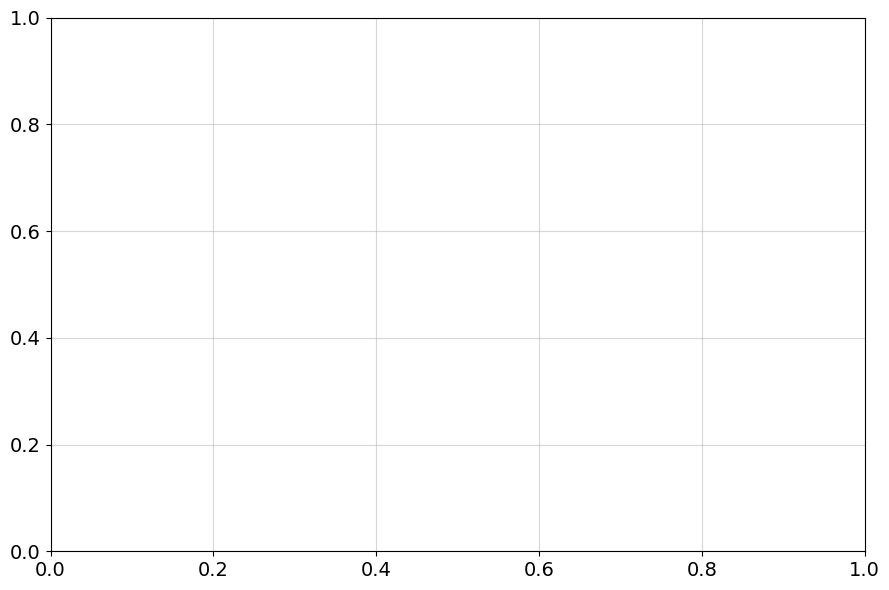

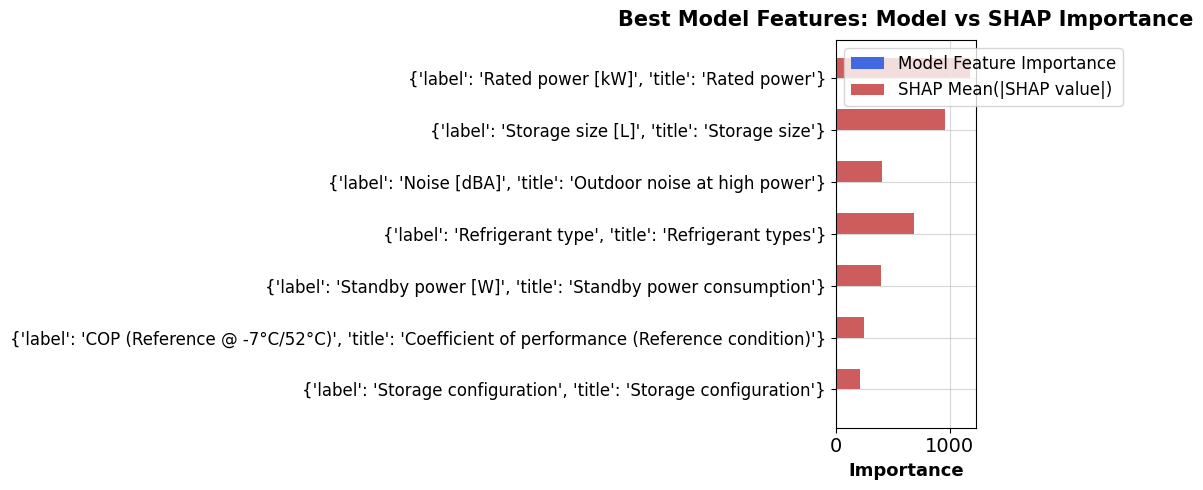

Model and SHAP feature importances plotted.



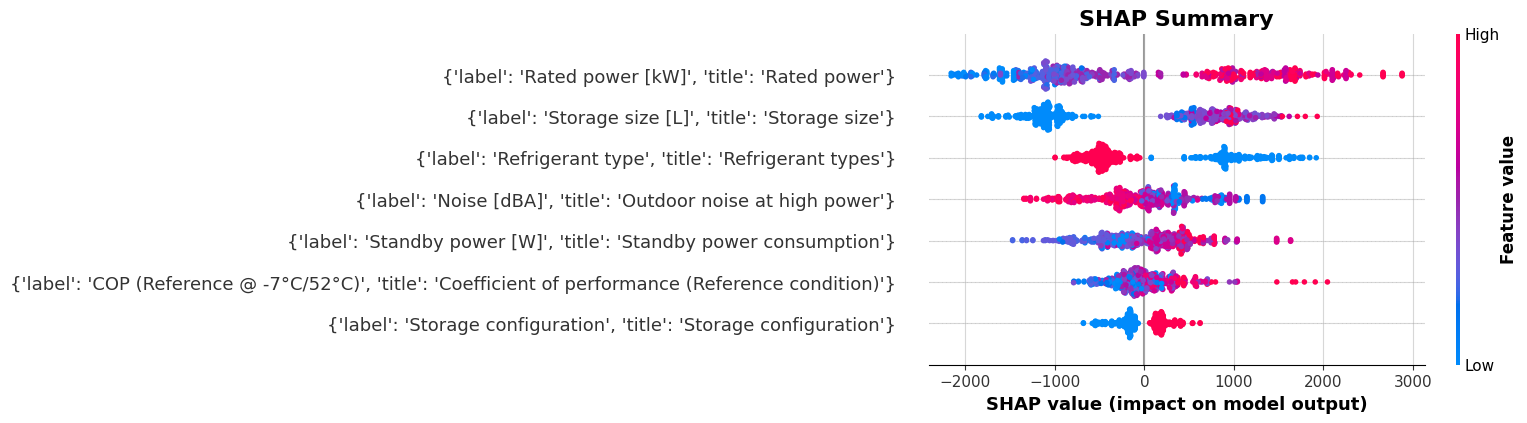


Permutation importance:
{'label': 'Rated power [kW]', 'title': 'Rated power'}                                                    0.607941
{'label': 'Storage size [L]', 'title': 'Storage size'}                                                   0.328349
{'label': 'Refrigerant type', 'title': 'Refrigerant types'}                                              0.232649
{'label': 'Standby power [W]', 'title': 'Standby power consumption'}                                     0.171058
{'label': 'Noise [dBA]', 'title': 'Outdoor noise at high power'}                                         0.162738
{'label': 'COP (Reference @ -7°C/52°C)', 'title': 'Coefficient of performance (Reference condition)'}    0.118170
{'label': 'Storage configuration', 'title': 'Storage configuration'}                                     0.034395
dtype: float64


TypeError: unhashable type: 'dict'

In [ ]:
# --------- Manual Model Selection ---------
# Use this section to define your model and features manually if desired.
# Example:
#   model_name = "RandomForest_200t"
#   features = ["feat1","feat2","feat3"]

# MANUAL SETTINGS (edit here if desired):
model_name = "RandomForest_200t"    # <-- Set the model to use by name ("RandomForest_200t", "RandomForest_100t", "RandomForest_300t", "GB_100", "GB_200", ...)
# Specify features explicitly or set to None to use best.features automatically
features = None  # Example: ["Rated Power medium T [kW]","Storage Size (L)","SPL outdoor high Power [dBA]"]

# -----------------------------------------
print(f"\nManual model selection: using model '{model_name}'")

target_col = 'Price'

# If features are not set manually, try to use best.features
if features is None:
    try:
        features = best.features
        print(f"Auto-selected features from 'best':\n{features}")
    except Exception as e:
        raise ValueError("No features specified and could not access best.features. Please set 'features' manually.") from e
else:
    print(f"MANUALLY CHOSEN FEATURES:\n{features}")

# Prepare data as earlier, drop rows with NA in these features
df_price = df.drop(columns=[
    "Manufacturer", "Date_scraped", "P_th_h_ref [W]", "PTOS [W]",
    "Power heating rod medium T [kW]", "Power heating rod low T [kW]",
    "Currency", "PSB [W]", "Configuration_Group", "Storage"
], errors="ignore").copy()
df_price = df_price.dropna(subset=[target_col])

# Label encode same as original for features if necessary
cat_cols = [c for c in df_price.select_dtypes('O').columns if c != target_col and c in features and df_price[c].nunique() < 30]
for c in cat_cols:
    df_price[c] = LabelEncoder().fit_transform(df_price[c].astype(str))

# Drop rows with NA in any selected features
model_input = df_price[features].copy()
non_null_rows = model_input.dropna().index
model_input = model_input.loc[non_null_rows]
y_all = df_price.loc[non_null_rows, target_col].values

# ----- Build selected model -----
# To reproduce: must sync with how you define model_name string!
mdl = None
if model_name == "RandomForest_100t":
    mdl = RandomForestRegressor(random_state=0, n_estimators=100, max_depth=7)
elif model_name == "RandomForest_200t":
    mdl = RandomForestRegressor(random_state=0, n_estimators=200, max_depth=10)
elif model_name == "RandomForest_300t":
    mdl = RandomForestRegressor(random_state=0, n_estimators=300, max_depth=10)
elif model_name == "GB_100":
    mdl = GradientBoostingRegressor(random_state=0, n_estimators=100, max_depth=3)
elif model_name == "GB_200":
    mdl = GradientBoostingRegressor(random_state=0, n_estimators=200, max_depth=5)
else:
    # Fallback: try 'models' dict or type of 'best'
    try:
        mdl = type(models[model_name])()
    except Exception:
        raise ValueError(f"Unknown model_name '{model_name}' and unable to infer model type.")

mdl.fit(model_input, y_all)

# Split the data into train/test for evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    model_input, y_all, test_size=0.2, random_state=42
)

# Refit model on training data for valid test evaluation
mdl.fit(X_train, y_train)

# Predict and score on train set
y_pred_train = mdl.predict(X_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)
mape_train = np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100

# Predict and score on test set
y_pred_test = mdl.predict(X_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
mape_test = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

print("\nModel fit metrics:")
print("Train set:")
print(f"  MAE:  {mae_train:,.2f}")
print(f"  RMSE: {rmse_train:,.2f}")
print(f"  R²:   {r2_train:.3f}")
print(f"  MAPE: {mape_train:.2f}%")
print("Test set:")
print(f"  MAE:  {mae_test:,.2f}")
print(f"  RMSE: {rmse_test:,.2f}")
print(f"  R²:   {r2_test:.3f}")
print(f"  MAPE: {mape_test:.2f}%")

# Optionally, re-fit on all data for feature importance analysis
mdl.fit(model_input, y_all)

# --- SHAP analysis ---
try:
    import shap
except ImportError:
    print("SHAP is not installed. Please run `pip install shap` to enable SHAP analysis.")
else:
    print("\nComputing SHAP values for chosen model/features...")
    # Derived feature importances
    importances = None
    if hasattr(mdl, "feature_importances_"):
        importances = pd.Series(mdl.feature_importances_, index=features).sort_values(ascending=False)
        print("\nModel feature importances:")

        # >>> ADAPT to new feature_label_map structure {feature: {'label':..., 'title':...}} if present
        if 'feature_label_map' in globals():
            importances_display = importances.copy()
            importances_display.index = [
                feature_label_map[feat]['label'] if (feat in feature_label_map and isinstance(feature_label_map[feat], dict) and 'label' in feature_label_map[feat])
                else feat for feat in importances.index
            ]
            display(importances_display)
        else:
            display(importances)

    # Use TreeExplainer for tree models, fallback to generic otherwise
    try:
        if hasattr(mdl, "feature_importances_"):
            explainer = shap.TreeExplainer(mdl)
        else:
            explainer = shap.Explainer(mdl, model_input)
    except Exception:
        explainer = shap.Explainer(mdl, model_input)

    n_explain = min(1000, model_input.shape[0])
    shap_values = explainer.shap_values(model_input.iloc[:n_explain])

    # Aggregate SHAP importances
    shap_means = np.abs(shap_values).mean(axis=0)
    shap_importance = pd.Series(shap_means, index=features).sort_values(ascending=False)
    print("\nSHAP feature importances (mean |SHAP value|):")
    if 'feature_label_map' in globals():
        shap_display = shap_importance.copy()
        shap_display.index = [
            feature_label_map[feat]['label'] if (feat in feature_label_map and isinstance(feature_label_map[feat], dict) and 'label' in feature_label_map[feat])
            else feat for feat in shap_importance.index
        ]
        display(shap_display)
    else:
        display(shap_importance)

    # Plot comparison if model importances available
    if importances is not None:
        imp_df = pd.DataFrame({
            "Model Importance": importances,
            "SHAP Importance": shap_importance[importances.index]
        })
        imp_df = imp_df[::-1]
        # Use feature labels if available
        if 'feature_label_map' in globals():
            imp_df_plot = imp_df.copy()
            imp_df_plot.index = [
                feature_label_map[feat]['label'] if (feat in feature_label_map and isinstance(feature_label_map[feat], dict) and 'label' in feature_label_map[feat])
                else feat for feat in imp_df.index
            ]
        else:
            imp_df_plot = imp_df
        fig, ax = plt.subplots(figsize=(10,5))
        width = 0.40
        y_pos = np.arange(len(imp_df_plot))
        ax.barh(y_pos - width/2, imp_df_plot["Model Importance"], height=width, label="Model Feature Importance", color='royalblue')
        ax.barh(y_pos + width/2, imp_df_plot["SHAP Importance"], height=width, label="SHAP Mean(|SHAP value|)", color='indianred')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(imp_df_plot.index, fontsize=12)
        ax.set_xlabel("Importance", fontsize=13)
        ax.set_title("Best Model Features: Model vs SHAP Importance", fontsize=15, fontweight='bold', pad=10)
        ax.legend(fontsize=12)
        plt.tight_layout()
        plt.show()
        print("Model and SHAP feature importances plotted.\n")

    # SHAP beeswarm plot
    plt.figure()
    if 'feature_label_map' in globals():
        feature_labels_used = [
            feature_label_map[col]['label'] if (col in feature_label_map and isinstance(feature_label_map[col], dict) and 'label' in feature_label_map[col])
            else col for col in model_input.columns
        ]
    else:
        feature_labels_used = model_input.columns
    shap.summary_plot(shap_values, model_input.iloc[:n_explain], feature_names=feature_labels_used, show=False)
    plt.title("SHAP Summary")
    plt.tight_layout()
    plt.show()

# ----- Permutation Importance plotted -----
from sklearn.inspection import permutation_importance

perm = permutation_importance(mdl, model_input, y_all, n_repeats=10, random_state=42, scoring='r2')
perm_imp = pd.Series(perm.importances_mean, index=model_input.columns).sort_values(ascending=False)
print("\nPermutation importance:")
if 'feature_label_map' in globals():
    perm_imp_display = perm_imp.copy()
    perm_imp_display.index = [
        feature_label_map[f]['label'] if (f in feature_label_map and isinstance(feature_label_map[f], dict) and 'label' in feature_label_map[f])
        else f for f in perm_imp.index
    ]
    print(perm_imp_display)
else:
    print(perm_imp)

# Plot permutation importance (barplot)
perm_imp_plot = perm_imp_display if 'perm_imp_display' in locals() else perm_imp
plt.figure(figsize=(9, 6))
plt.barh(perm_imp_plot.index[::-1], perm_imp_plot[::-1])
plt.xlabel("Permutation Importance (ΔR²)", fontsize=13)
plt.title("Permutation Importance of Features", fontsize=15, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(mdl, model_input, y_all, n_repeats=10, random_state=42, scoring='r2')
perm_imp = pd.Series(perm.importances_mean, index=model_input.columns).sort_values(ascending=False)
print("\nPermutation importance:")
print(perm_imp)


Permutation importance:
Rated Power medium T [kW]       0.607941
Storage Size (L)                0.328349
Refrigerant                     0.232649
Poff [W]                        0.171058
SPL outdoor high Power [dBA]    0.162738
COP_ref                         0.118170
Storage2                        0.034395
dtype: float64



Random Forest model performance on test data (ALL features):
  MAE:  828.31
  RMSE: 1,204.70
  R²:   0.827

Top 10 features influencing Price:


Rated Power medium T [kW]       0.224827
Storage Size (L)                0.145407
SPL outdoor high Power [dBA]    0.116973
Refrigerant                     0.084916
Poff [W]                        0.060507
Rated Power low T [kW]          0.057851
COP_ref                         0.032910
Storage                         0.029801
Configuration_Group             0.023353
SPL outdoor low Power [dBA]     0.022253
dtype: float64


Random Forest model performance on test data (TOP 10 features):
  MAE:  817.22
  RMSE: 1,178.82
  R²:   0.834

SHAP feature attribution analysis (Top 10 features)...


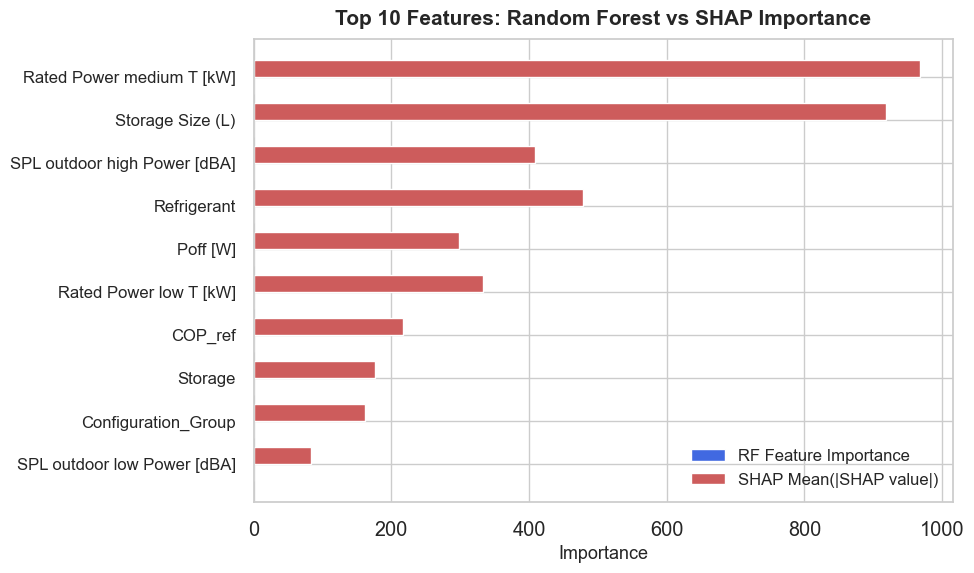

Combined feature importance plot (RF and SHAP) generated for top 10 features.



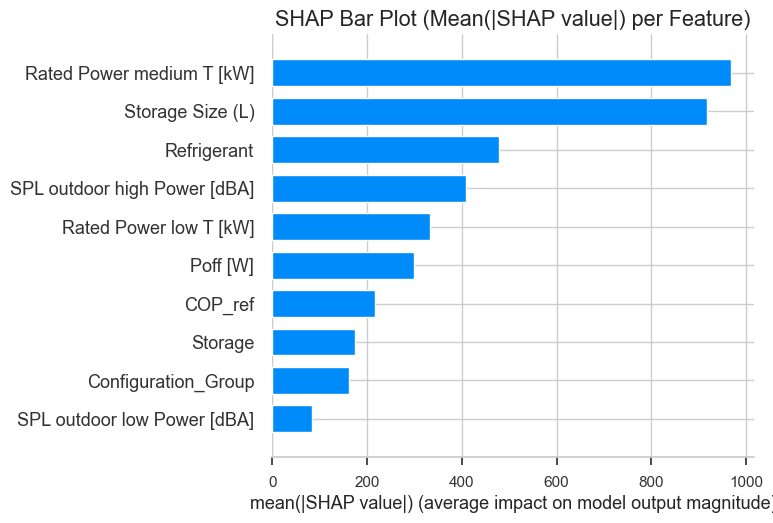

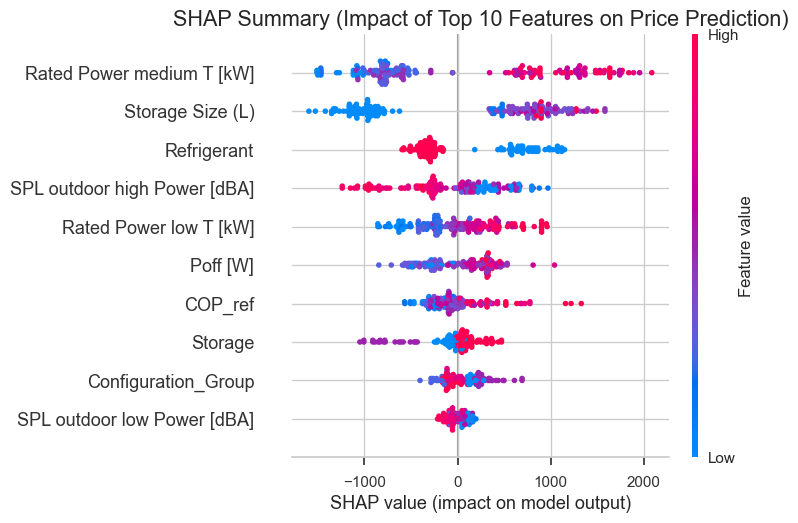

In [ ]:
# Identify which columns have the most influence on the Price column

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

# --- Prepare and clean data ---
df_price = df.drop(columns=["Manufacturer","Date_scraped", "P_th_h_ref [W]","PTOS [W]", "Power heating rod medium T [kW]",
"Power heating rod low T [kW]", "Currency", "PSB [W]"], errors="ignore").copy()
na_thresh = 0.7  # Drop columns with > 70% NA
df_price = df_price.loc[:, df_price.isnull().mean() < na_thresh]
df_price = df_price.loc[:, df_price.nunique() > 1]

target_col = 'Price'

# Identify numeric and categorical columns
numeric_cols = []
categorical_cols = []
for c in df_price.columns:
    if c == target_col:
        continue
    if pd.api.types.is_numeric_dtype(df_price[c]):
        numeric_cols.append(c)
    elif df_price[c].dtype == 'O':
        if df_price[c].nunique() < 30:
            categorical_cols.append(c)
        else:
            df_price = df_price.drop(columns=[c])

# Label encode categoricals
for c in categorical_cols:
    df_price[c] = df_price[c].astype(str)
    try:
        enc = LabelEncoder()
        df_price[c] = enc.fit_transform(df_price[c])
    except Exception:
        df_price = df_price.drop(columns=[c])

# Keep only usable features
features = [col for col in df_price.columns if col != target_col and pd.api.types.is_numeric_dtype(df_price[col])]

# Drop rows with missing Price
df_price = df_price.dropna(subset=[target_col])

df_model_input = df_price[features]

# Impute missing data
imp = SimpleImputer(strategy="median")
df_model = pd.DataFrame(
    imp.fit_transform(df_model_input),
    columns=df_model_input.columns,
    index=df_price.index
)
y = df_price[target_col].values

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(df_model, y, test_size=0.25, random_state=42)

# --- Fit model for importance ---
rf = RandomForestRegressor(n_estimators=200, random_state=0)
rf.fit(X_train, y_train)

# Evaluate on all features
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nRandom Forest model performance on test data (ALL features):")
print(f"  MAE:  {mae:,.2f}")
print(f"  RMSE: {rmse:,.2f}")
print(f"  R²:   {r2:.3f}")

# Get feature importances and top 10 features
importances = pd.Series(rf.feature_importances_, index=df_model.columns).sort_values(ascending=False)
top_influencers = importances.head(10)
print("\nTop 10 features influencing Price:")
display(top_influencers)

# --- Retrain model using only top 10 features ---
top10_feats = list(top_influencers.index)
X_train_10 = X_train[top10_feats]
X_test_10 = X_test[top10_feats]

rf_10 = RandomForestRegressor(n_estimators=200, random_state=0)
rf_10.fit(X_train_10, y_train)
y_pred_10 = rf_10.predict(X_test_10)
mae_10 = mean_absolute_error(y_test, y_pred_10)
rmse_10 = np.sqrt(mean_squared_error(y_test, y_pred_10))
r2_10 = r2_score(y_test, y_pred_10)

print("\nRandom Forest model performance on test data (TOP 10 features):")
print(f"  MAE:  {mae_10:,.2f}")
print(f"  RMSE: {rmse_10:,.2f}")
print(f"  R²:   {r2_10:.3f}")

# --- SHAP analysis (10 features only) and combined plot with RF importances ---
print("\nSHAP feature attribution analysis (Top 10 features)...")
try:
    import shap
except ImportError:
    print("SHAP is not installed. Please run `pip install shap` to enable SHAP analysis.")
else:
    # TreeExplainer for random forest based on top 10 features
    n_explain = min(300, X_test_10.shape[0])
    explainer = shap.TreeExplainer(rf_10)
    shap_values = explainer.shap_values(X_test_10[:n_explain])

    # Compute mean absolute SHAP importance for each feature (top 10, same order)
    shap_means = np.abs(shap_values).mean(axis=0)
    shap_importance = pd.Series(shap_means, index=top10_feats)

    # Combine importance DataFrames and plot side-by-side bars
    imp_df = pd.DataFrame({
        "RF Importance": top_influencers,
        "SHAP Importance": shap_importance[top_influencers.index]
    })

    imp_df = imp_df[::-1]  # reverse for plotting (top at top)

    fig, ax = plt.subplots(figsize=(10,6))
    width = 0.40

    y_pos = np.arange(len(imp_df))
    ax.barh(y_pos - width/2, imp_df["RF Importance"], height=width, label="RF Feature Importance", color='royalblue')
    ax.barh(y_pos + width/2, imp_df["SHAP Importance"], height=width, label="SHAP Mean(|SHAP value|)", color='indianred')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(imp_df.index, fontsize=12)
    ax.set_xlabel("Importance", fontsize=13)
    ax.set_title("Top 10 Features: Random Forest vs SHAP Importance", fontsize=15, fontweight='bold', pad=10)
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    print("Combined feature importance plot (RF and SHAP) generated for top 10 features.\n")

    # SHAP bar plot (mean absolute SHAP value per feature)
    plt.figure(figsize=(8, 6))
    shap.summary_plot(
        shap_values,
        X_test_10[:n_explain],
        feature_names=X_test_10.columns,
        plot_type="bar",
        show=False
    )
    plt.title("SHAP Bar Plot (Mean(|SHAP value|) per Feature)")
    plt.tight_layout()
    plt.show()

    # SHAP summary beeswarm for detail
    plt.figure()
    shap.summary_plot(shap_values, X_test_10[:n_explain], feature_names=X_test_10.columns, show=False)
    plt.title("SHAP Summary (Impact of Top 10 Features on Price Prediction)")
    plt.tight_layout()
    plt.show()


Top 10 features influencing Price:


Rated Power medium T [kW]       0.224827
Storage Size (L)                0.145407
SPL outdoor high Power [dBA]    0.116973
Refrigerant                     0.084916
Poff [W]                        0.060507
Rated Power low T [kW]          0.057851
COP_ref                         0.032910
Storage                         0.029801
Configuration_Group             0.023353
SPL outdoor low Power [dBA]     0.022253
dtype: float64

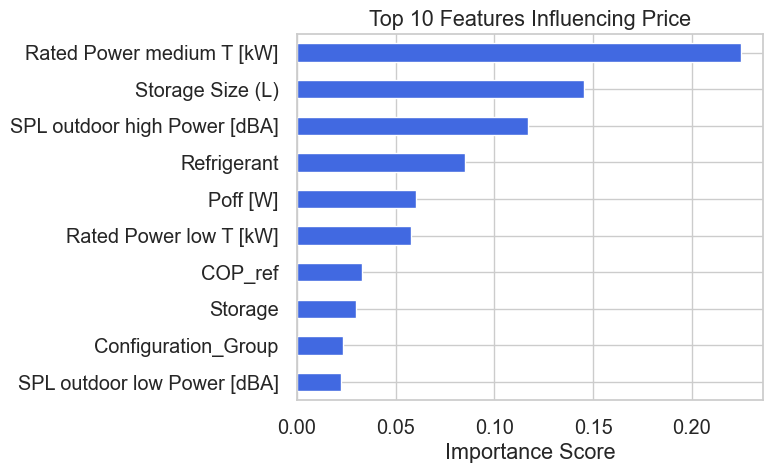


Random Forest model performance on test data (TOP 10 features):
  MAE:  817.22
  RMSE: 1,178.82
  R²:   0.834

Mean absolute error by Brand (TOP 10 features):


Brand
 ait-deutschland GmbH                                       2631.576398
 Bosch Thermotechnik GmbH                                   1436.613991
 Panasonic Marketing Europe GmbH                            1274.050685
 TOSHIBA AIR CONDITIONING                                   1072.612878
 Bosch Thermotechnik GmbH (Buderus)                          834.247311
                                                               ...     
 Viessmann Climate Solutions SE                              587.951770
 Mitsubishi Electric Air Conditioning Systems Europe LTD     497.078405
 Samsung Electronics Air Conditioner Europe B.V.             486.920118
 Johnson Controls-Hitachi AirConditioning Spain              220.280801
 Vaillant GmbH                                                84.890608
Name: abs_error, Length: 13, dtype: float64

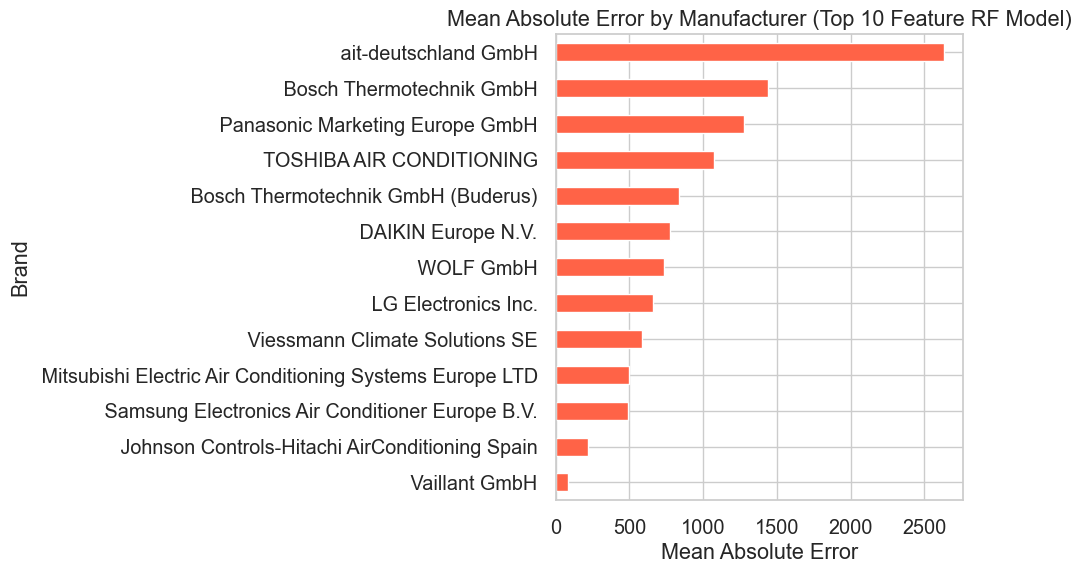

<Figure size 1200x650 with 0 Axes>

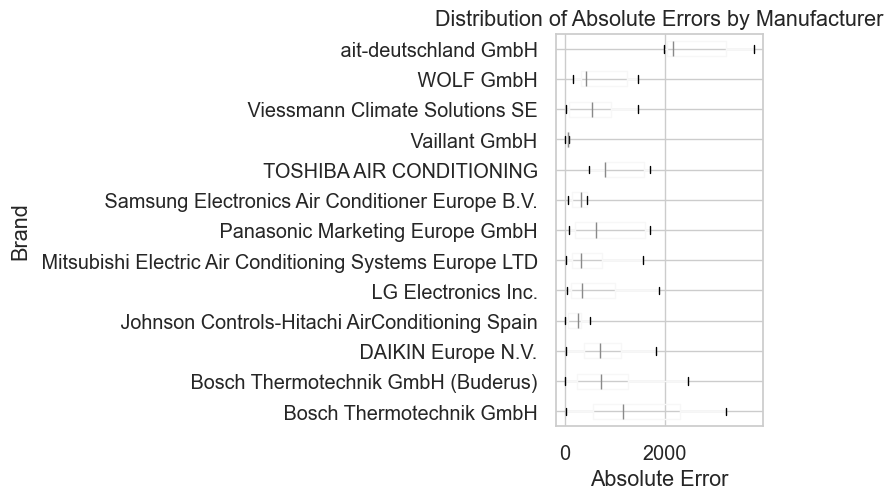

In [ ]:
# --- Determine most important features, predict with them, and analyze brand errors ---

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

# --- Prepare and clean data (preserve Manufacturer for later analysis) ---
df_price = df.drop(
    columns=[
        "Date_scraped", "P_th_h_ref [W]", "PTOS [W]", "Power heating rod medium T [kW]",
        "Power heating rod low T [kW]", "Currency", "PSB [W]"
    ], errors="ignore"
).copy()
na_thresh = 0.7  # Drop columns with > 70% NA
df_price = df_price.loc[:, df_price.isnull().mean() < na_thresh]
df_price = df_price.loc[:, df_price.nunique() > 1]

target_col = 'Price'
manufacturer_col = 'Manufacturer'
manufacturers_test = None  # Will hold test set brands

# Identify numeric and categorical columns
numeric_cols = []
categorical_cols = []
for c in df_price.columns:
    if c == target_col or c == manufacturer_col:
        continue
    if pd.api.types.is_numeric_dtype(df_price[c]):
        numeric_cols.append(c)
    elif df_price[c].dtype == 'O':
        if df_price[c].nunique() < 30:
            categorical_cols.append(c)
        else:
            df_price = df_price.drop(columns=[c])

# Label encode categoricals
for c in categorical_cols:
    df_price[c] = df_price[c].astype(str)
    try:
        enc = LabelEncoder()
        df_price[c] = enc.fit_transform(df_price[c])
    except Exception:
        df_price = df_price.drop(columns=[c])

# Keep only usable features
features = [col for col in df_price.columns if col != target_col and col != manufacturer_col and pd.api.types.is_numeric_dtype(df_price[col])]

# Drop rows with missing Price or Manufacturer
df_price = df_price.dropna(subset=[target_col, manufacturer_col])
df_price[manufacturer_col] = df_price[manufacturer_col].astype(str)

df_model_input = df_price[features]

# Impute missing data
imp = SimpleImputer(strategy="median")
df_model = pd.DataFrame(
    imp.fit_transform(df_model_input),
    columns=df_model_input.columns,
    index=df_price.index
)
y = df_price[target_col].values

# Split into train/test sets (keep manufacturer label for test data)
X_train, X_test, y_train, y_test, mfr_train, mfr_test = train_test_split(
    df_model, y, df_price[manufacturer_col],
    test_size=0.25, random_state=42)

manufacturers_test = mfr_test.reset_index(drop=True)

# --- Fit model for feature importance ---
rf = RandomForestRegressor(n_estimators=200, random_state=0)
rf.fit(X_train, y_train)

# Get feature importances and top 10 features
importances = pd.Series(rf.feature_importances_, index=df_model.columns).sort_values(ascending=False)
top_influencers = importances.head(10)
print("\nTop 10 features influencing Price:")
display(top_influencers)

plt.figure(figsize=(8,5))
top_influencers[::-1].plot(kind='barh', color='royalblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Features Influencing Price')
plt.tight_layout()
plt.show()

# --- Retrain model using only top 10 features and predict ---
top10_feats = list(top_influencers.index)
X_train_10 = X_train[top10_feats]
X_test_10 = X_test[top10_feats]

rf_10 = RandomForestRegressor(n_estimators=200, random_state=0)
rf_10.fit(X_train_10, y_train)
y_pred_10 = rf_10.predict(X_test_10)

# Compute general test metrics
mae_10 = mean_absolute_error(y_test, y_pred_10)
rmse_10 = np.sqrt(mean_squared_error(y_test, y_pred_10))
r2_10 = r2_score(y_test, y_pred_10)
print("\nRandom Forest model performance on test data (TOP 10 features):")
print(f"  MAE:  {mae_10:,.2f}")
print(f"  RMSE: {rmse_10:,.2f}")
print(f"  R²:   {r2_10:.3f}")

# --- Brand error analysis ---
# Make DataFrame for predictions vs truth and brand
results_df = pd.DataFrame({
    'Price_true': y_test,
    'Price_pred': y_pred_10,
    'Brand': manufacturers_test.values
}).reset_index(drop=True)
results_df['abs_error'] = np.abs(results_df['Price_pred'] - results_df['Price_true'])

# Analyze errors per brand (use mean absolute error)
brand_errors = results_df.groupby('Brand')['abs_error'].mean().sort_values(ascending=False)
print("\nMean absolute error by Brand (TOP 10 features):")
display(brand_errors)

plt.figure(figsize=(10, 6))
brand_errors[::-1].plot(kind='barh', color='tomato')
plt.xlabel('Mean Absolute Error')
plt.title('Mean Absolute Error by Manufacturer (Top 10 Feature RF Model)')
plt.tight_layout()
plt.show()

# Optionally, display error distribution as boxplot per brand
brands_to_plot = brand_errors.index
plt.figure(figsize=(12, max(6, 0.5*len(brands_to_plot))))
results_df_box = results_df[results_df['Brand'].isin(brands_to_plot)]
results_df_box.boxplot(column='abs_error', by='Brand', vert=False, showfliers=False)
plt.xlabel('Absolute Error')
plt.title('Distribution of Absolute Errors by Manufacturer')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
df_price

,Manufacturer,Price,Subtype,Group,Config,Storage,Storage Size (L),Rated Power low T [kW],Rated Power medium T [kW],Refrigerant,SPL indoor low Power [dBA],SPL outdoor low Power [dBA],SPL indoor high Power [dBA],SPL outdoor high Power [dBA],Bivalence temperature [°C],Tolerance temperature [°C],Max. water heating temperature [°C],Poff [W],PCKS [W],eta low T [%],eta medium T [%],SCOP,SEER low T,P_th_c_ref [W],P_el_h_ref [W],P_el_c_ref [W],COP_ref,EER_c_ref,Configuration_Group,Region,Power_Group,Power_mean_group,Storage2
0,Bosch Thermotechnik GmbH,9933.0,1,1.0,0,0,0.0,6.6,6.6,0,31.0,42.0,31.0,42.0,-7.0,-10.0,75.0,15.0,32.0,180.0,138.0,4.58,NaN,NaN,2842.0,NaN,2.09,NaN,0,1,6-9kW,1,0
1,Bosch Thermotechnik GmbH,10999.0,1,1.0,0,2,170.0,4.4,4.0,0,37.0,40.0,37.0,40.0,-7.0,-10.0,75.0,15.0,33.0,179.0,127.0,4.55,NaN,NaN,1671.0,NaN,2.10,NaN,2,1,<6kW,1,1
2,Bosch Thermotechnik GmbH,10999.0,1,1.0,0,0,70.0,6.2,6.2,0,37.0,42.0,37.0,42.0,-7.0,-10.0,75.0,16.0,31.0,179.0,136.0,4.55,NaN,NaN,2646.0,NaN,2.09,NaN,0,1,6-9kW,1,0
3,Bosch Thermotechnik GmbH,10999.0,1,1.0,0,0,70.0,4.4,4.0,0,37.0,40.0,37.0,40.0,-7.0,-10.0,75.0,15.0,33.0,179.0,128.0,4.55,NaN,NaN,1673.0,NaN,2.11,NaN,0,1,<6kW,1,0
4,Bosch Thermotechnik GmbH,11499.0,1,1.0,0,0,70.0,6.6,6.6,0,37.0,42.0,37.0,42.0,-7.0,-10.0,75.0,15.0,32.0,180.0,136.0,4.56,NaN,NaN,2917.0,NaN,2.05,NaN,0,1,6-9kW,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691,ait-deutschland GmbH,13645.0,1,1.0,0,0,0.0,9.5,8.9,0,NaN,54.0,NaN,54.0,-5.0,-10.0,60.0,0.0,30.0,187.0,147.0,4.75,NaN,NaN,3228.0,NaN,2.19,NaN,0,1,>9kW,0,0
692,ait-deutschland GmbH,7199.0,1,1.0,0,0,0.0,9.5,8.9,0,NaN,54.0,NaN,54.0,-5.0,-10.0,60.0,0.0,30.0,187.0,147.0,4.90,NaN,NaN,3228.0,NaN,2.19,NaN,0,1,>9kW,0,0
693,ait-deutschland GmbH,9599.0,1,1.0,0,2,279.0,9.5,8.9,0,NaN,54.0,NaN,54.0,-5.0,-10.0,60.0,0.0,30.0,187.0,147.0,4.90,NaN,NaN,3228.0,NaN,2.19,NaN,2,1,>9kW,0,1
694,ait-deutschland GmbH,15637.0,1,1.0,0,2,180.0,9.5,8.9,0,NaN,54.0,NaN,54.0,-5.0,-10.0,60.0,0.0,30.0,187.0,147.0,4.75,NaN,NaN,3228.0,NaN,2.19,NaN,2,1,>9kW,0,1


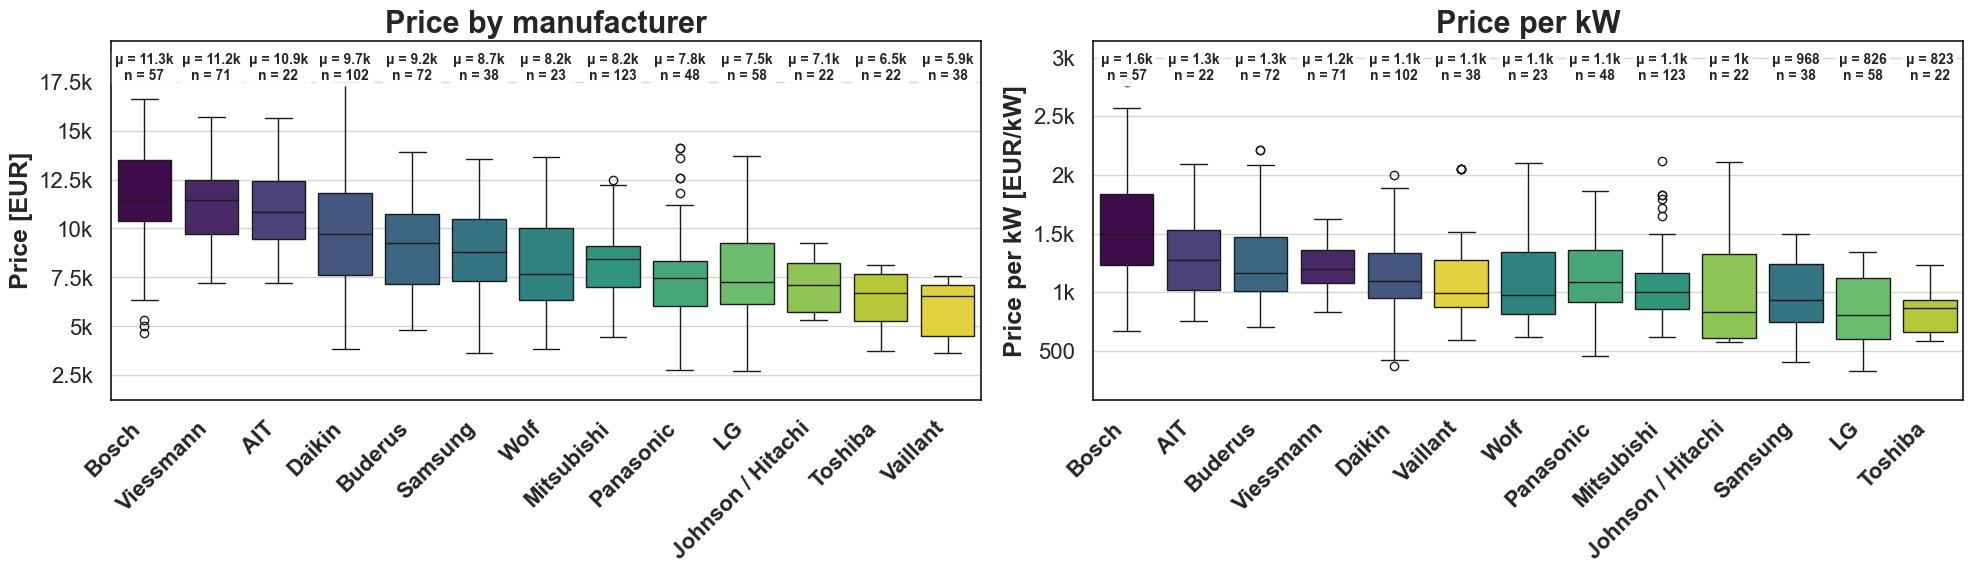

In [ ]:
# Plot two related boxplots as subplots: Price by brand and Price per kW by brand

# Create figure directory if it doesn't exist
figures_dir.mkdir(exist_ok=True)

# Mapping from long to short manufacturer names (handle variants/typos)
manufacturer_map = {
    'bosch thermotechnik gmbh': 'Bosch',
    'viessmann climate solutions se': 'Viessmann',
    'ait-deutschland gmbh': 'AIT',
    'daikin europe n.v.': 'Daikin',
    'bosch thermotechnik gmbh (buderus)': 'Buderus',
    'samsung electronics air conditioner europe b.v.': 'Samsung',
    'wolf gmbh': 'Wolf',
    'mitsubishi electric air conditioning systems europe ltd': 'Mitsubishi',
    'panasonic marketing europe gmbh': 'Panasonic',
    'lg electronics inc.': 'LG',
    'johnson controls-hitachi air-conditioning spain': 'Johnson / Hitachi',
    'johnson controls-hitachi airconditionning spain': 'Johnson / Hitachi',
    'johnson controls-hitachi air conditioning spain': 'Johnson / Hitachi',
    'toshiba air conditioning': 'Toshiba',
    'vaillant gmbh': 'Vaillant',
}
display_label_map = {
    'Bosch': 'Bosch',
    'Viessmann': 'Viessmann',
    'AIT': 'AIT',
    'Daikin': 'Daikin',
    'Buderus': 'Buderus',
    'Samsung': 'Samsung',
    'Wolf': 'Wolf',
    'Mitsubishi': 'Mitsubishi',
    'Panasonic': 'Panasonic',
    'LG': 'LG',
    'Johnson / Hitachi': 'Johnson / Hitachi',
    'Toshiba': 'Toshiba',
    'Vaillant': 'Vaillant',
}

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import numpy as np

def _format_thousands_k(v):
    """Format large ints in thousands as 1.3k, 12k, etc. Does not use commas."""
    if abs(v) >= 1000:
        value = round(float(v) / 1000, 1)
        if value.is_integer():
            value = int(value)
        return f"{value}k"
    elif v == 0:
        return "0"
    else:
        return str(int(round(v)))

df_viz = df.copy()
df_viz['Manufacturer_clean'] = df_viz['Manufacturer'].astype(str).str.strip().str.lower()
df_viz['Manufacturer_short'] = df_viz['Manufacturer_clean'].map(manufacturer_map).fillna(df_viz['Manufacturer_clean'])
df_viz['Manufacturer_short'] = df_viz['Manufacturer_short'].apply(
    lambda x: 'Johnson / Hitachi' if ('johnson' in x and 'hitachi' in x) else x
)

# Prepare ordering
mean_prices = df_viz.groupby('Manufacturer_short')['Price'].mean().sort_values(ascending=False)
all_manufacturers = mean_prices.index.tolist()

# Assign a unique color per manufacturer for consistent color mapping between subplots
viridis = cm.get_cmap('viridis', len(all_manufacturers))
manufacturer_to_color = {manu: viridis(i) for i, manu in enumerate(all_manufacturers)}

def get_palette(order):
    """Return palette list corresponding to the order using persistent mapping."""
    return [manufacturer_to_color[m] for m in order]

# For price per kW
df_viz['Price_per_kW'] = None
if (
    'Price' in df_viz.columns and
    'Rated Power low T [kW]' in df_viz.columns and
    df_viz['Rated Power low T [kW]'].notnull().any()
):
    df_viz['Price_per_kW'] = df_viz['Price'] / df_viz['Rated Power low T [kW]']
    mean_price_per_kw = df_viz.groupby('Manufacturer_short')['Price_per_kW'].mean().sort_values(ascending=False)
    all_manufacturers_per_kw = mean_price_per_kw.index.tolist()
else:
    mean_price_per_kw = None
    all_manufacturers_per_kw = all_manufacturers  # fallback if no per-kW data

# Helper to build label for each manufacturer
def _make_labels(avg, n, units="EUR"):
    return f"μ = {_format_thousands_k(avg)}\nn = {n}"

# Start of the two subplots figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Restore normal frame look for each subplot (remove facecolor/patch changes)
for ax in [ax1, ax2]:
    ax.set_facecolor('none')  # Let matplotlib show default axes frame
    if hasattr(ax, 'spines'):
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.1)
            spine.set_color('black')

fig.patch.set_facecolor('none')  # Figure background as default

# ---- Subplot 1: Price by Brand ----
counts = df_viz['Manufacturer_short'].value_counts()
sns.boxplot(
    data=df_viz, x='Manufacturer_short', y='Price',
    order=all_manufacturers, palette=get_palette(all_manufacturers), ax=ax1
)

annot_y_offset_factor = -0.005  # How much above top to place
y_max_all = df_viz['Price'].max()
y_min_all = df_viz['Price'].min()
y_range = y_max_all - y_min_all
annot_y_offset = annot_y_offset_factor * y_range

for i, manufacturer in enumerate(all_manufacturers):
    avg_price = mean_prices[manufacturer]
    n = counts[manufacturer]
    box_top = df_viz.groupby('Manufacturer_short')['Price'].max().max()
    y_label = box_top + annot_y_offset
    ax1.annotate(
        _make_labels(avg_price, n, "EUR"),
        xy=(i, y_label), xytext=(0, 0), textcoords='offset points',
        ha='center', va='bottom', fontweight='bold', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.18', facecolor='white', alpha=0.92, linewidth=1.2)
    )

ax1.set_xlabel("")
ax1.set_ylim([y_min_all - 0.10 * y_range, y_max_all + 0.14 * y_range])
ax1.set_title('Price by manufacturer', fontsize=22, fontweight='bold')
ax1.set_ylabel('Price [EUR]', fontsize=18, fontweight='bold')
ax1.set_xticklabels(
    [display_label_map.get(
        manufacturer_map.get(m, m.title()) if not (('johnson' in m and 'hitachi' in m)) else 'Johnson / Hitachi', m
    ) for m in all_manufacturers],
    rotation=45, ha='right', fontsize=16, fontweight='bold'
)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: _format_thousands_k(x)))
ax1.tick_params(axis='y', labelsize=16)
ax1.grid(True, axis='y', alpha=0.8, linewidth=1.0)  # Stronger, normal grid

# ---- Subplot 2: Price per kW by Brand ----
if mean_price_per_kw is not None and df_viz['Price_per_kW'].notnull().any():
    counts_kw = df_viz['Manufacturer_short'].value_counts()
    sns.boxplot(
        data=df_viz, x='Manufacturer_short', y='Price_per_kW',
        order=all_manufacturers_per_kw, palette=get_palette(all_manufacturers_per_kw), ax=ax2
    )
    y_max_all_kw = df_viz['Price_per_kW'].max()
    y_min_all_kw = df_viz['Price_per_kW'].min()
    y_range_kw = y_max_all_kw - y_min_all_kw
    annot_y_offset_kw = annot_y_offset_factor * y_range_kw

    for i, manufacturer in enumerate(all_manufacturers_per_kw):
        avg_price_per_kw = mean_price_per_kw[manufacturer]
        n = counts_kw[manufacturer]
        y_label = df_viz.groupby('Manufacturer_short')['Price_per_kW'].max().max() + annot_y_offset_kw
        ax2.annotate(
            _make_labels(avg_price_per_kw, n, "EUR/kW"),
            xy=(i, y_label), xytext=(0, 0), textcoords='offset points',
            ha='center', va='bottom', fontweight='bold', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white', alpha=0.92, linewidth=1.2)
        )
    ax2.set_xlabel("")
    ax2.set_ylim([y_min_all_kw - 0.10 * y_range_kw, y_max_all_kw + 0.14 * y_range_kw])
    ax2.set_title('Price per kW', fontsize=22, fontweight='bold')
    ax2.set_ylabel('Price per kW [EUR/kW]', fontsize=18, fontweight='bold')
    ax2.set_xticklabels(
        [display_label_map.get(
            manufacturer_map.get(m, m.title()) if not (('johnson' in m and 'hitachi' in m)) else 'Johnson / Hitachi', m
        ) for m in all_manufacturers_per_kw],
        rotation=45, ha='right', fontsize=16, fontweight='bold'
    )
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: _format_thousands_k(x)))
    ax2.tick_params(axis='y', labelsize=16)
    ax2.grid(True, axis='y', alpha=0.8, linewidth=1.0)
else:
    ax2.axis('off')
    ax2.set_title('Price per kW data not available', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

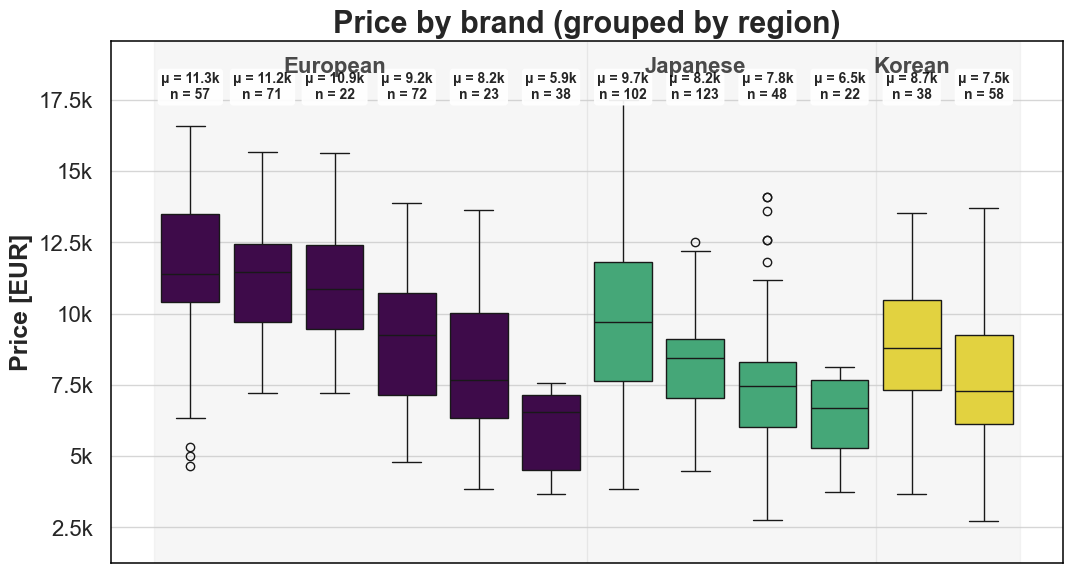

In [ ]:
# Plot all brands boxplots as before, but don't display manufacturer names on the x-axis,
# and use three distinct viridis colors by group

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import to_hex
from matplotlib import cm

# Create figure directory if it doesn't exist
figures_dir.mkdir(exist_ok=True)

def _format_thousands_k(v):
    """Format large ints in thousands as 1.3k, 12k, etc. Does not use commas."""
    if abs(v) >= 1000:
        value = round(float(v) / 1000, 1)
        if value.is_integer():
            value = int(value)
        return f"{value}k"
    elif v == 0:
        return "0"
    else:
        return str(int(round(v)))

# Map to regions
manufacturer_map = {
    'bosch thermotechnik gmbh': 'European',
    'viessmann climate solutions se': 'European',
    'ait-deutschland gmbh': 'European',
    'daikin europe n.v.': 'Japanese',
    'bosch thermotechnik gmbh (buderus)': 'European',
    'samsung electronics air conditioner europe b.v.': 'Korean',
    'wolf gmbh': 'European',
    'mitsubishi electric air conditioning systems europe ltd': 'Japanese',
    'panasonic marketing europe gmbh': 'Japanese',
    'lg electronics inc.': 'Korean',
    'johnson controls-hitachi air-conditioning spain': 'Japanese',
    'johnson controls-hitachi airconditionning spain': 'Japanese',
    'johnson controls-hitachi air conditioning spain': 'Japanese',
    'toshiba air conditioning': 'Japanese',
    'vaillant gmbh': 'European',
}
region_order = ['European', 'Japanese', 'Korean']

# Clean and map manufacturers to short brand and region
df_viz = df.copy()
df_viz['Manufacturer_clean'] = df_viz['Manufacturer'].astype(str).str.strip().str.lower()
df_viz['Region'] = df_viz['Manufacturer_clean'].map(manufacturer_map).fillna('Other')

# Determine which brands belong in which region and their boxplot order (as original)
unique_manus = df_viz['Manufacturer_clean'].unique()
brands_by_region = {region: [] for region in region_order}
for manu in unique_manus:
    region = manufacturer_map.get(manu, None)
    if region in region_order:
        brands_by_region[region].append(manu)
# Sort brands inside each region by mean price (descending)
brands_ordered = []
for region in region_order:
    manus = brands_by_region[region]
    if manus:
        mean_prices = df_viz[df_viz['Manufacturer_clean'].isin(manus)].groupby('Manufacturer_clean')['Price'].mean().sort_values(ascending=False)
        brands_ordered += mean_prices.index.tolist()
# Only keep those present in the data
brands_ordered = [m for m in brands_ordered if m in df_viz['Manufacturer_clean'].unique()]

# Map each brand to its region
brand_to_region = {m: manufacturer_map.get(m, 'Other') for m in brands_ordered}

# Assign three distinct viridis colors for three regions
viridis = cm.get_cmap('viridis', 4)
region_colors = {
    'European': to_hex(viridis(0)),
    'Japanese': to_hex(viridis(2)),
    'Korean': to_hex(viridis(3)),
    'Other': '#bbbbbb',
}
def get_palette(order):
    return [region_colors.get(brand_to_region[m], '#bbbbbb') for m in order]

def _make_labels(avg, n, units="EUR"):
    return f"μ = {_format_thousands_k(avg)}\nn = {n}"

fig, ax1 = plt.subplots(1, 1, figsize=(11, 6))
ax1.set_facecolor('none')
if hasattr(ax1, 'spines'):
    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.1)
        spine.set_color('black')
fig.patch.set_facecolor('none')

# Create boxplot by brand, color by region
counts = df_viz['Manufacturer_clean'].value_counts()
sns.boxplot(
    data=df_viz[df_viz['Manufacturer_clean'].isin(brands_ordered)],
    x='Manufacturer_clean', y='Price',
    order=brands_ordered, palette=get_palette(brands_ordered),
    ax=ax1, dodge=False
)

annot_y_offset_factor = -0.005
y_max_all = df_viz['Price'].max()
y_min_all = df_viz['Price'].min()
y_range = y_max_all - y_min_all
annot_y_offset = annot_y_offset_factor * y_range

# Shade regions and show their region name
last_idx = 0
for region in region_order:
    manus = [m for m in brands_ordered if brand_to_region[m] == region]
    n_m = len(manus)
    if n_m == 0:
        continue
    x0 = last_idx - 0.5
    x1 = last_idx + n_m - 0.5
    ax1.axvspan(x0, x1, color='grey', alpha=0.07, zorder=0)
    if n_m > 0:
        ax1.text(
            x0 + n_m / 2 - 0.5,
            y_max_all + 0.08 * y_range,
            region,
            ha='center', va='center',
            fontsize=16, fontweight='bold',
            alpha=0.7, color='black',
            zorder=4
        )
    last_idx += n_m

for i, m in enumerate(brands_ordered):
    avg_price = df_viz[df_viz['Manufacturer_clean'] == m]['Price'].mean()
    n = counts[m]
    box_top = df_viz.groupby('Manufacturer_clean')['Price'].max().max()
    y_label = box_top + annot_y_offset
    ax1.annotate(
        _make_labels(avg_price, n, "EUR"),
        xy=(i, y_label), xytext=(0, 0), textcoords='offset points',
        ha='center', va='bottom', fontweight='bold', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.18', facecolor='white', alpha=0.92, linewidth=1.2)
    )

ax1.set_xlabel("")
ax1.set_ylim([y_min_all - 0.10 * y_range, y_max_all + 0.14 * y_range])
ax1.set_title('Price by brand (grouped by region)', fontsize=22, fontweight='bold')
ax1.set_ylabel('Price [EUR]', fontsize=18, fontweight='bold')
# Remove manufacturer names from the x-axis
ax1.set_xticklabels(
    ['' for _ in brands_ordered],
    rotation=45, ha='right', fontsize=16, fontweight='bold'
)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: _format_thousands_k(x)))
ax1.tick_params(axis='y', labelsize=16)
ax1.grid(True, axis='y', alpha=0.8, linewidth=1.0)

plt.tight_layout()
plt.show()

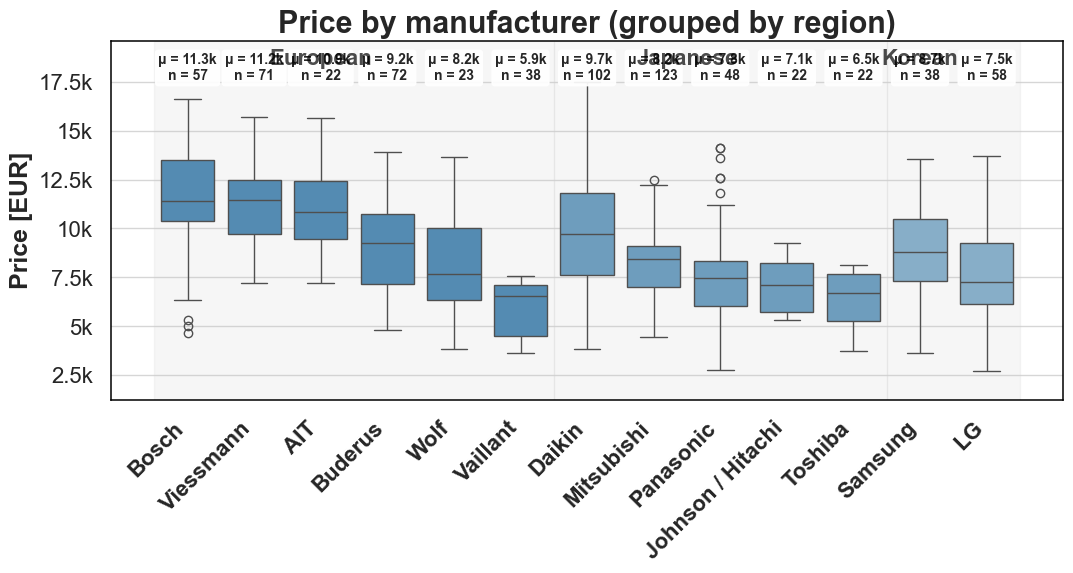

In [ ]:
manufacturer_region_map = {
    'Bosch': 'European',
    'Viessmann': 'European',
    'AIT': 'European',
    'Buderus': 'European',
    'Vaillant': 'European',
    'Wolf': 'European',
    'Daikin': 'Japanese',
    'Mitsubishi': 'Japanese',
    'Panasonic': 'Japanese',
    'Toshiba': 'Japanese',
    'Johnson / Hitachi': 'Japanese',
    'Samsung': 'Korean',
    'LG': 'Korean'
}

# Create figure directory if it doesn't exist
figures_dir.mkdir(exist_ok=True)

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def _format_thousands_k(v):
    """Format large ints in thousands as 1.3k, 12k, etc. Does not use commas."""
    if abs(v) >= 1000:
        value = round(float(v) / 1000, 1)
        if value.is_integer():
            value = int(value)
        return f"{value}k"
    elif v == 0:
        return "0"
    else:
        return str(int(round(v)))

manufacturer_map = {
    'bosch thermotechnik gmbh': 'Bosch',
    'viessmann climate solutions se': 'Viessmann',
    'ait-deutschland gmbh': 'AIT',
    'daikin europe n.v.': 'Daikin',
    'bosch thermotechnik gmbh (buderus)': 'Buderus',
    'samsung electronics air conditioner europe b.v.': 'Samsung',
    'wolf gmbh': 'Wolf',
    'mitsubishi electric air conditioning systems europe ltd': 'Mitsubishi',
    'panasonic marketing europe gmbh': 'Panasonic',
    'lg electronics inc.': 'LG',
    'johnson controls-hitachi air-conditioning spain': 'Johnson / Hitachi',
    'johnson controls-hitachi airconditionning spain': 'Johnson / Hitachi',
    'johnson controls-hitachi air conditioning spain': 'Johnson / Hitachi',
    'toshiba air conditioning': 'Toshiba',
    'vaillant gmbh': 'Vaillant',
}
display_label_map = {
    'Bosch': 'Bosch',
    'Viessmann': 'Viessmann',
    'AIT': 'AIT',
    'Daikin': 'Daikin',
    'Buderus': 'Buderus',
    'Samsung': 'Samsung',
    'Wolf': 'Wolf',
    'Mitsubishi': 'Mitsubishi',
    'Panasonic': 'Panasonic',
    'LG': 'LG',
    'Johnson / Hitachi': 'Johnson / Hitachi',
    'Toshiba': 'Toshiba',
    'Vaillant': 'Vaillant',
}

# Clean and map manufacturer names
df_viz = df.copy()
df_viz['Manufacturer_clean'] = df_viz['Manufacturer'].astype(str).str.strip().str.lower()
df_viz['Manufacturer_short'] = df_viz['Manufacturer_clean'].map(manufacturer_map).fillna(df_viz['Manufacturer_clean'])
df_viz['Manufacturer_short'] = df_viz['Manufacturer_short'].apply(
    lambda x: 'Johnson / Hitachi' if ('johnson' in x and 'hitachi' in x) else x
)

df_viz['Region'] = df_viz['Manufacturer_short'].map(manufacturer_region_map).fillna('Other')

region_order = ['European', 'Japanese', 'Korean']
manufacturer_region_pairs = [(m, manufacturer_region_map[m]) for m in manufacturer_region_map]
ordered_manus_by_region = {
    region: [m for m, r in manufacturer_region_pairs if r == region]
    for region in region_order
}

# Order manufacturers within each region by mean price (descending)
all_manufacturers_ordered = []
for region in region_order:
    manus_in_region = ordered_manus_by_region[region]
    mean_prices_region = df_viz[df_viz['Manufacturer_short'].isin(manus_in_region)].groupby('Manufacturer_short')['Price'].mean().sort_values(ascending=False)
    manus_ordered = mean_prices_region.index.tolist()
    all_manufacturers_ordered.extend(manus_ordered)

# Only keep those actually present in the data
all_manufacturers_ordered = [m for m in all_manufacturers_ordered if m in df_viz['Manufacturer_short'].unique()]

# Generate a palette: use clearly contrasting colors for each region, with shades for manufacturers
# We'll use three base colors, one per region, and assign lightness variants for manufacturers
from matplotlib.colors import to_rgb, to_hex

region_base_colors = {
    'European': (44/255, 127/255, 184/255),   # blue
    'Japanese': (252/255, 141/255, 89/255),   # orange
    'Korean': (102/255, 194/255, 165/255),    # green
}
def lighten(color, amount):
    # color: rgb tuple
    # amount: float in [0, 1], 0 = no change, 1 = white
    return tuple((1 - amount) * c + amount * 1.0 for c in color)

manufacturer_to_color = {}
for region in region_order:
    manus = [m for m in all_manufacturers_ordered if manufacturer_region_map.get(m) == region]
    base = region_base_colors[region]
    for idx, m in enumerate(manus):
        amt = 0.12 + 0.65 * (idx / max(1, len(manus) - 1))  # lightens from amt~0.12 to 0.77
        manufacturer_to_color[m] = to_hex(lighten(base, amt))

def get_palette(order):
    return [manufacturer_to_color[m] for m in order]

def _make_labels(avg, n, units="EUR"):
    return f"μ = {_format_thousands_k(avg)}\nn = {n}"

fig, ax1 = plt.subplots(1, 1, figsize=(11, 6))

ax1.set_facecolor('none')
if hasattr(ax1, 'spines'):
    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.1)
        spine.set_color('black')
fig.patch.set_facecolor('none')

# --- Only plot the single subplot: Price by Brand GROUPED BY REGION ---
counts = df_viz['Manufacturer_short'].value_counts()
sns.boxplot(
    data=df_viz[df_viz['Manufacturer_short'].isin(all_manufacturers_ordered)],
    x='Manufacturer_short', y='Price', hue='Region',
    order=all_manufacturers_ordered, palette=get_palette(all_manufacturers_ordered),
    ax=ax1, dodge=False
)

annot_y_offset_factor = -0.005
y_max_all = df_viz['Price'].max()
y_min_all = df_viz['Price'].min()
y_range = y_max_all - y_min_all
annot_y_offset = annot_y_offset_factor * y_range

# Shade regions and show their names
last_idx = 0
for region in region_order:
    manus = [m for m in all_manufacturers_ordered if manufacturer_region_map.get(m) == region]
    n_m = len(manus)
    if n_m == 0:
        continue
    x0 = last_idx - 0.5
    x1 = last_idx + n_m - 0.5
    ax1.axvspan(x0, x1, color='grey', alpha=0.07, zorder=0)
    if n_m > 0:
        ax1.text(
            x0 + n_m / 2 - 0.5,
            y_max_all + 0.08 * y_range,
            region,
            ha='center', va='center',
            fontsize=16, fontweight='bold',
            alpha=0.7, color='black',
            zorder=4
        )
    last_idx += n_m

for i, manufacturer in enumerate(all_manufacturers_ordered):
    avg_price = df_viz[df_viz['Manufacturer_short'] == manufacturer]['Price'].mean()
    n = counts[manufacturer]
    box_top = df_viz.groupby('Manufacturer_short')['Price'].max().max()
    y_label = box_top + annot_y_offset
    ax1.annotate(
        _make_labels(avg_price, n, "EUR"),
        xy=(i, y_label), xytext=(0, 0), textcoords='offset points',
        ha='center', va='bottom', fontweight='bold', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.18', facecolor='white', alpha=0.92, linewidth=1.2)
    )

ax1.set_xlabel("")
ax1.set_ylim([y_min_all - 0.10 * y_range, y_max_all + 0.14 * y_range])
ax1.set_title('Price by manufacturer (grouped by region)', fontsize=22, fontweight='bold')
ax1.set_ylabel('Price [EUR]', fontsize=18, fontweight='bold')
ax1.set_xticklabels(
    [display_label_map.get(m, m.title()) for m in all_manufacturers_ordered],
    rotation=45, ha='right', fontsize=16, fontweight='bold'
)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: _format_thousands_k(x)))
ax1.tick_params(axis='y', labelsize=16)
ax1.grid(True, axis='y', alpha=0.8, linewidth=1.0)

# Remove hue legend (region) if present (since region is labelled on band)
if ax1.get_legend() is not None:
    ax1.get_legend().remove()

plt.tight_layout()
plt.show()

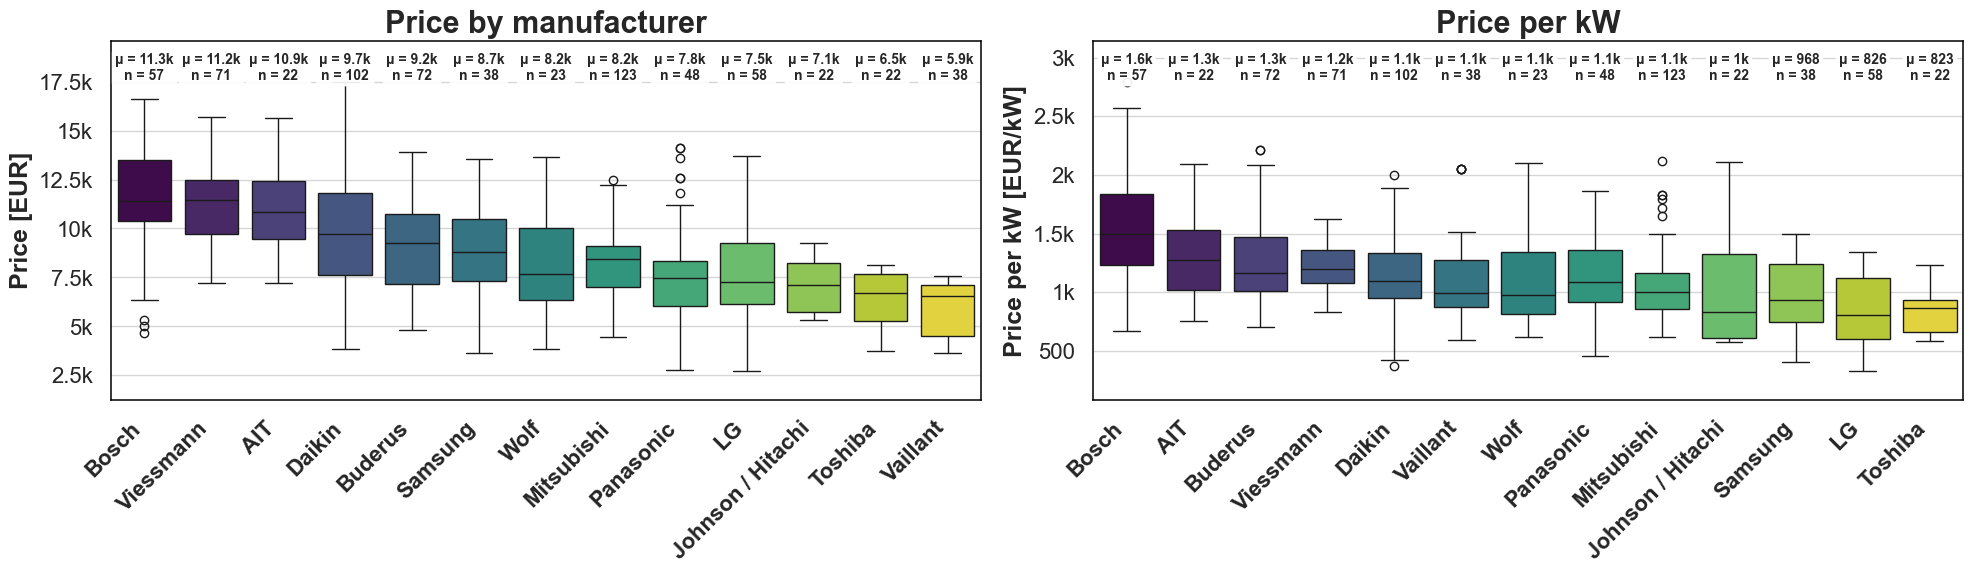

In [ ]:
# Plot two related boxplots as subplots: Price by brand and Price per kW by brand

# Create figure directory if it doesn't exist
figures_dir.mkdir(exist_ok=True)

# Mapping from long to short manufacturer names (handle variants/typos)
manufacturer_map = {
    'bosch thermotechnik gmbh': 'Bosch',
    'viessmann climate solutions se': 'Viessmann',
    'ait-deutschland gmbh': 'AIT',
    'daikin europe n.v.': 'Daikin',
    'bosch thermotechnik gmbh (buderus)': 'Buderus',
    'samsung electronics air conditioner europe b.v.': 'Samsung',
    'wolf gmbh': 'Wolf',
    'mitsubishi electric air conditioning systems europe ltd': 'Mitsubishi',
    'panasonic marketing europe gmbh': 'Panasonic',
    'lg electronics inc.': 'LG',
    'johnson controls-hitachi air-conditioning spain': 'Johnson / Hitachi',
    'johnson controls-hitachi airconditionning spain': 'Johnson / Hitachi',
    'johnson controls-hitachi air conditioning spain': 'Johnson / Hitachi',
    'toshiba air conditioning': 'Toshiba',
    'vaillant gmbh': 'Vaillant',
}
display_label_map = {
    'Bosch': 'Bosch',
    'Viessmann': 'Viessmann',
    'AIT': 'AIT',
    'Daikin': 'Daikin',
    'Buderus': 'Buderus',
    'Samsung': 'Samsung',
    'Wolf': 'Wolf',
    'Mitsubishi': 'Mitsubishi',
    'Panasonic': 'Panasonic',
    'LG': 'LG',
    'Johnson / Hitachi': 'Johnson / Hitachi',
    'Toshiba': 'Toshiba',
    'Vaillant': 'Vaillant',
}

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import seaborn as sns

def _format_thousands_k(v):
    """Format large ints in thousands as 1.3k, 12k, etc. Does not use commas."""
    if abs(v) >= 1000:
        value = round(float(v) / 1000, 1)
        if value.is_integer():
            value = int(value)
        return f"{value}k"
    elif v == 0:
        return "0"
    else:
        return str(int(round(v)))

df_viz = df.copy()
df_viz['Manufacturer_clean'] = df_viz['Manufacturer'].astype(str).str.strip().str.lower()
df_viz['Manufacturer_short'] = df_viz['Manufacturer_clean'].map(manufacturer_map).fillna(df_viz['Manufacturer_clean'])
df_viz['Manufacturer_short'] = df_viz['Manufacturer_short'].apply(
    lambda x: 'Johnson / Hitachi' if ('johnson' in x and 'hitachi' in x) else x
)

# Prepare ordering
mean_prices = df_viz.groupby('Manufacturer_short')['Price'].mean().sort_values(ascending=False)
all_manufacturers = mean_prices.index.tolist()

# Use the Viridis color palette
import matplotlib.cm as cm
import numpy as np
viridis = cm.get_cmap('viridis', len(all_manufacturers))
viridis_palette = [viridis(i) for i in range(len(all_manufacturers))]

# For price per kW
df_viz['Price_per_kW'] = None
if (
    'Price' in df_viz.columns and
    'Rated Power low T [kW]' in df_viz.columns and
    df_viz['Rated Power low T [kW]'].notnull().any()
):
    df_viz['Price_per_kW'] = df_viz['Price'] / df_viz['Rated Power low T [kW]']
    mean_price_per_kw = df_viz.groupby('Manufacturer_short')['Price_per_kW'].mean().sort_values(ascending=False)
    all_manufacturers_per_kw = mean_price_per_kw.index.tolist()
    viridis_palette_per_kw = [viridis(i) for i in range(len(all_manufacturers_per_kw))]
else:
    mean_price_per_kw = None
    all_manufacturers_per_kw = all_manufacturers
    viridis_palette_per_kw = viridis_palette

# Helper to build label for each manufacturer
def _make_labels(avg, n, units="EUR"):
    return f"μ = {_format_thousands_k(avg)}\nn = {n}"

# Start of the two subplots figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Restore normal frame look for each subplot (remove facecolor/patch changes)
for ax in [ax1, ax2]:
    ax.set_facecolor('none')  # Let matplotlib show default axes frame
    if hasattr(ax, 'spines'):
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.1)
            spine.set_color('black')

fig.patch.set_facecolor('none')  # Figure background as default

# ---- Subplot 1: Price by Brand ----
counts = df_viz['Manufacturer_short'].value_counts()
sns.boxplot(
    data=df_viz, x='Manufacturer_short', y='Price',
    order=all_manufacturers, palette=viridis_palette[:len(all_manufacturers)], ax=ax1
)

annot_y_offset_factor = -0.005  # How much above top to place
y_max_all = df_viz['Price'].max()
y_min_all = df_viz['Price'].min()
y_range = y_max_all - y_min_all
annot_y_offset = annot_y_offset_factor * y_range

for i, manufacturer in enumerate(all_manufacturers):
    avg_price = mean_prices[manufacturer]
    n = counts[manufacturer]
    box_top = df_viz.groupby('Manufacturer_short')['Price'].max().max()
    y_label = box_top + annot_y_offset
    ax1.annotate(
        _make_labels(avg_price, n, "EUR"),
        xy=(i, y_label), xytext=(0, 0), textcoords='offset points',
        ha='center', va='bottom', fontweight='bold', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.18', facecolor='white', alpha=0.92, linewidth=1.2)
    )

ax1.set_xlabel("")
ax1.set_ylim([y_min_all - 0.10 * y_range, y_max_all + 0.14 * y_range])
ax1.set_title('Price by manufacturer', fontsize=22, fontweight='bold')
ax1.set_ylabel('Price [EUR]', fontsize=18, fontweight='bold')
ax1.set_xticklabels(
    [display_label_map.get(
        manufacturer_map.get(m, m.title()) if not (('johnson' in m and 'hitachi' in m)) else 'Johnson / Hitachi', m
    ) for m in all_manufacturers],
    rotation=45, ha='right', fontsize=16, fontweight='bold'
)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: _format_thousands_k(x)))
ax1.tick_params(axis='y', labelsize=16)
ax1.grid(True, axis='y', alpha=0.8, linewidth=1.0)  # Stronger, normal grid

# ---- Subplot 2: Price per kW by Brand ----
if mean_price_per_kw is not None and df_viz['Price_per_kW'].notnull().any():
    counts_kw = df_viz['Manufacturer_short'].value_counts()
    sns.boxplot(
        data=df_viz, x='Manufacturer_short', y='Price_per_kW',
        order=all_manufacturers_per_kw, palette=viridis_palette_per_kw[:len(all_manufacturers_per_kw)], ax=ax2
    )
    y_max_all_kw = df_viz['Price_per_kW'].max()
    y_min_all_kw = df_viz['Price_per_kW'].min()
    y_range_kw = y_max_all_kw - y_min_all_kw
    annot_y_offset_kw = annot_y_offset_factor * y_range_kw

    for i, manufacturer in enumerate(all_manufacturers_per_kw):
        avg_price_per_kw = mean_price_per_kw[manufacturer]
        n = counts_kw[manufacturer]
        y_label = df_viz.groupby('Manufacturer_short')['Price_per_kW'].max().max() + annot_y_offset_kw
        ax2.annotate(
            _make_labels(avg_price_per_kw, n, "EUR/kW"),
            xy=(i, y_label), xytext=(0, 0), textcoords='offset points',
            ha='center', va='bottom', fontweight='bold', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white', alpha=0.92, linewidth=1.2)
        )
    ax2.set_xlabel("")
    ax2.set_ylim([y_min_all_kw - 0.10 * y_range_kw, y_max_all_kw + 0.14 * y_range_kw])
    ax2.set_title('Price per kW', fontsize=22, fontweight='bold')
    ax2.set_ylabel('Price per kW [EUR/kW]', fontsize=18, fontweight='bold')
    ax2.set_xticklabels(
        [display_label_map.get(
            manufacturer_map.get(m, m.title()) if not (('johnson' in m and 'hitachi' in m)) else 'Johnson / Hitachi', m
        ) for m in all_manufacturers_per_kw],
        rotation=45, ha='right', fontsize=16, fontweight='bold'
    )
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: _format_thousands_k(x)))
    ax2.tick_params(axis='y', labelsize=16)
    ax2.grid(True, axis='y', alpha=0.8, linewidth=1.0)
else:
    ax2.axis('off')
    ax2.set_title('Price per kW data not available', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

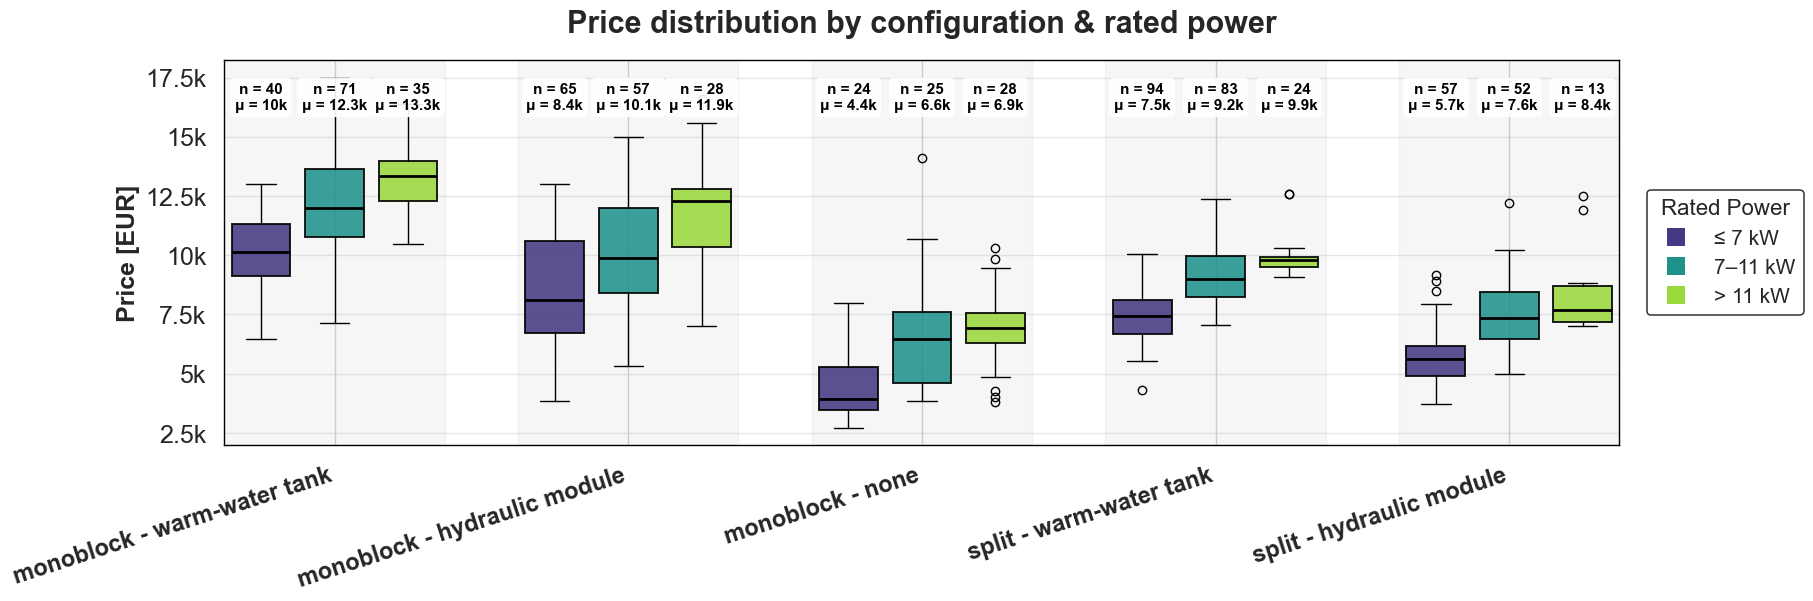

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import ticker as mticker
import matplotlib.colors as mcolors

# Define rated power bins and labels
rated_power_col = 'Rated Power low T [kW]'
rated_power_bins = [0, 7, 11, np.inf]
rated_power_labels = ['≤ 7 kW', '7–11 kW', '> 11 kW']

if rated_power_col in df.columns:
    df['Power_bin'] = pd.cut(df[rated_power_col], bins=rated_power_bins, labels=rated_power_labels, include_lowest=True, right=True)
else:
    raise RuntimeError("Rated Power Column not found in dataframe")

config_counts = df['Configuration_Group'].value_counts()
configs = config_counts.index.tolist()
monoblock_configs = [c for c in configs if c.lower().startswith('monoblock')]
split_configs = [c for c in configs if c.lower().startswith('split')]
sorted_configs = monoblock_configs + split_configs
mw_tank = 'monoblock - warm-water tank'
if mw_tank in sorted_configs:
    sorted_configs = [mw_tank] + [c for c in sorted_configs if c != mw_tank]

positions = []
plot_data = []
box_colors = []

# --- Use slightly lighter and higher-contrast Viridis colors ---
from matplotlib import cm
viridis = cm.get_cmap('viridis')
n_bins = len(rated_power_labels)
# Choose a subset from the perceptually uniform mid-range of Viridis, skipping very dark/pale ends
nice_viridis_idxs = np.linspace(0.17, 0.85, n_bins)

custom_viridis_colors = [mcolors.to_hex(viridis(val)) for val in nice_viridis_idxs]
# --------------------------------------------------------------

for i, config in enumerate(sorted_configs):
    for j, pbin in enumerate(rated_power_labels):
        mask = (df['Configuration_Group'] == config) & (df['Power_bin'] == pbin)
        vals = df.loc[mask, 'Price'].dropna()
        plot_data.append(vals)
        positions.append(i * 4 + j)
        # Use the custom "nicer" Viridis color scale, one per bin
        box_colors.append(custom_viridis_colors[j])

fig, ax1 = plt.subplots(1, 1, figsize=(18, 5), facecolor='white')
ax1.set_facecolor('white')

# --- ensure all four spines are visible and black ---
for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)
# -----------------------------------------------------

if 'Price' in df.columns and any([len(v) > 0 for v in plot_data]):
    bp = ax1.boxplot(
        plot_data, positions=positions, widths=0.8, patch_artist=True, showmeans=False,
        boxprops=dict(linewidth=1.4, color='black'),
        medianprops=dict(linewidth=2, color='black')  # <-- make median line black
    )

    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.88)

    # --- Add text boxes with mean and n to each boxplot ---
    # Precompute statistics for each boxplot
    all_max_y = []
    for vals in plot_data:
        if len(vals) > 0:
            all_max_y.append(vals.max())
    if all_max_y:
        global_max_y = max(all_max_y)
        global_min_y = min([vals.min() for vals in plot_data if len(vals) > 0])
        y_range = global_max_y - global_min_y if global_max_y > global_min_y else 1
    else:
        global_max_y = 1.0
        y_range = 1.0

    # Position each box's annotation a little above that box's maximum value, so they don't overlap (if empty, skip).
    for pos, vals in zip(positions, plot_data):
        if len(vals) > 0:
            n = len(vals)
            mean_val = vals.mean()
            # Try to use _format_thousands_k if available, else fallback to int
            try:
                mean_str = _format_thousands_k(mean_val)
            except Exception:
                mean_str = f"{mean_val:,.0f}"
            try:
                n_str = _format_thousands_k(n)
            except Exception:
                n_str = f"{n}"

            text = f"n = {n_str}\nμ = {mean_str}"
            # place annotation at 6% above that box's max, but at least 5% above the global max so boxes never overlap
            y_annot = vals.max() - 0.1 * y_range
            if y_annot < global_max_y - 0.1 * y_range:
                y_annot = global_max_y - 0.1 * y_range

            ax1.annotate(
                text,
                xy=(pos, y_annot), xytext=(0, 0), textcoords='offset points',
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.24', facecolor='white', alpha=0.91, linewidth=1.2)
            )
    # ------------------------------------------------------

    # Setup x-axis: one big xtick per group, not per box, readable
    # Each config has 3 boxes (for 3 bins) so tick at their average
    xticks = [np.mean([positions[i*3 + 0], positions[i*3 + 1], positions[i*3 + 2]]) for i in range(len(sorted_configs))]
    ax1.set_xticks(xticks)
    ax1.set_xticklabels(sorted_configs, rotation=18, ha='right', fontsize=17, fontweight='bold')

    # Light group background as previous style
    for i in range(len(sorted_configs)):
        ax1.axvspan(i*4-0.5, i*4+2.5, color='grey', alpha=0.07, zorder=-1)

    # Legend for the rated power bins/colors
    handles = [
        plt.Line2D([0], [0], color=custom_viridis_colors[j], marker='s', markersize=13, linestyle="None")
        for j in range(n_bins)
    ]
    legend = ax1.legend(
        handles, rated_power_labels, title="Rated Power", 
        fontsize=15, title_fontsize=16, loc='center left',
        frameon=True, bbox_to_anchor=(1.02, 0.5), ncol=1, borderaxespad=0
    )
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_linewidth(1.1)

    # Axis labels & title
    ax1.set_ylabel("Price [EUR]", fontsize=18, fontweight='bold')
    ax1.set_title("Price distribution by configuration & rated power", fontsize=22, fontweight='bold', pad=20)

    # Use _format_thousands_k for y-axis labels if available
    try:
        ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: _format_thousands_k(x)))
    except Exception:
        pass
    ax1.tick_params(axis='y', labelsize=18)
    ax1.tick_params(axis='x', labelsize=17)
    ax1.grid(True, axis='y', alpha=0.50, linewidth=1.0)
else:
    ax1.set_axis_off()
    ax1.set_title("Price data not available", fontsize=18, fontweight='bold')

# plt.tight_layout()

# --- add black border to the entire figure (outer frame) ---
for spine in fig.gca().spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.0)
# ------------------------------------------------------------

plt.show()


Configuration comparison plots saved to: reports\figures\descriptive_analysis


### Price By Configuration

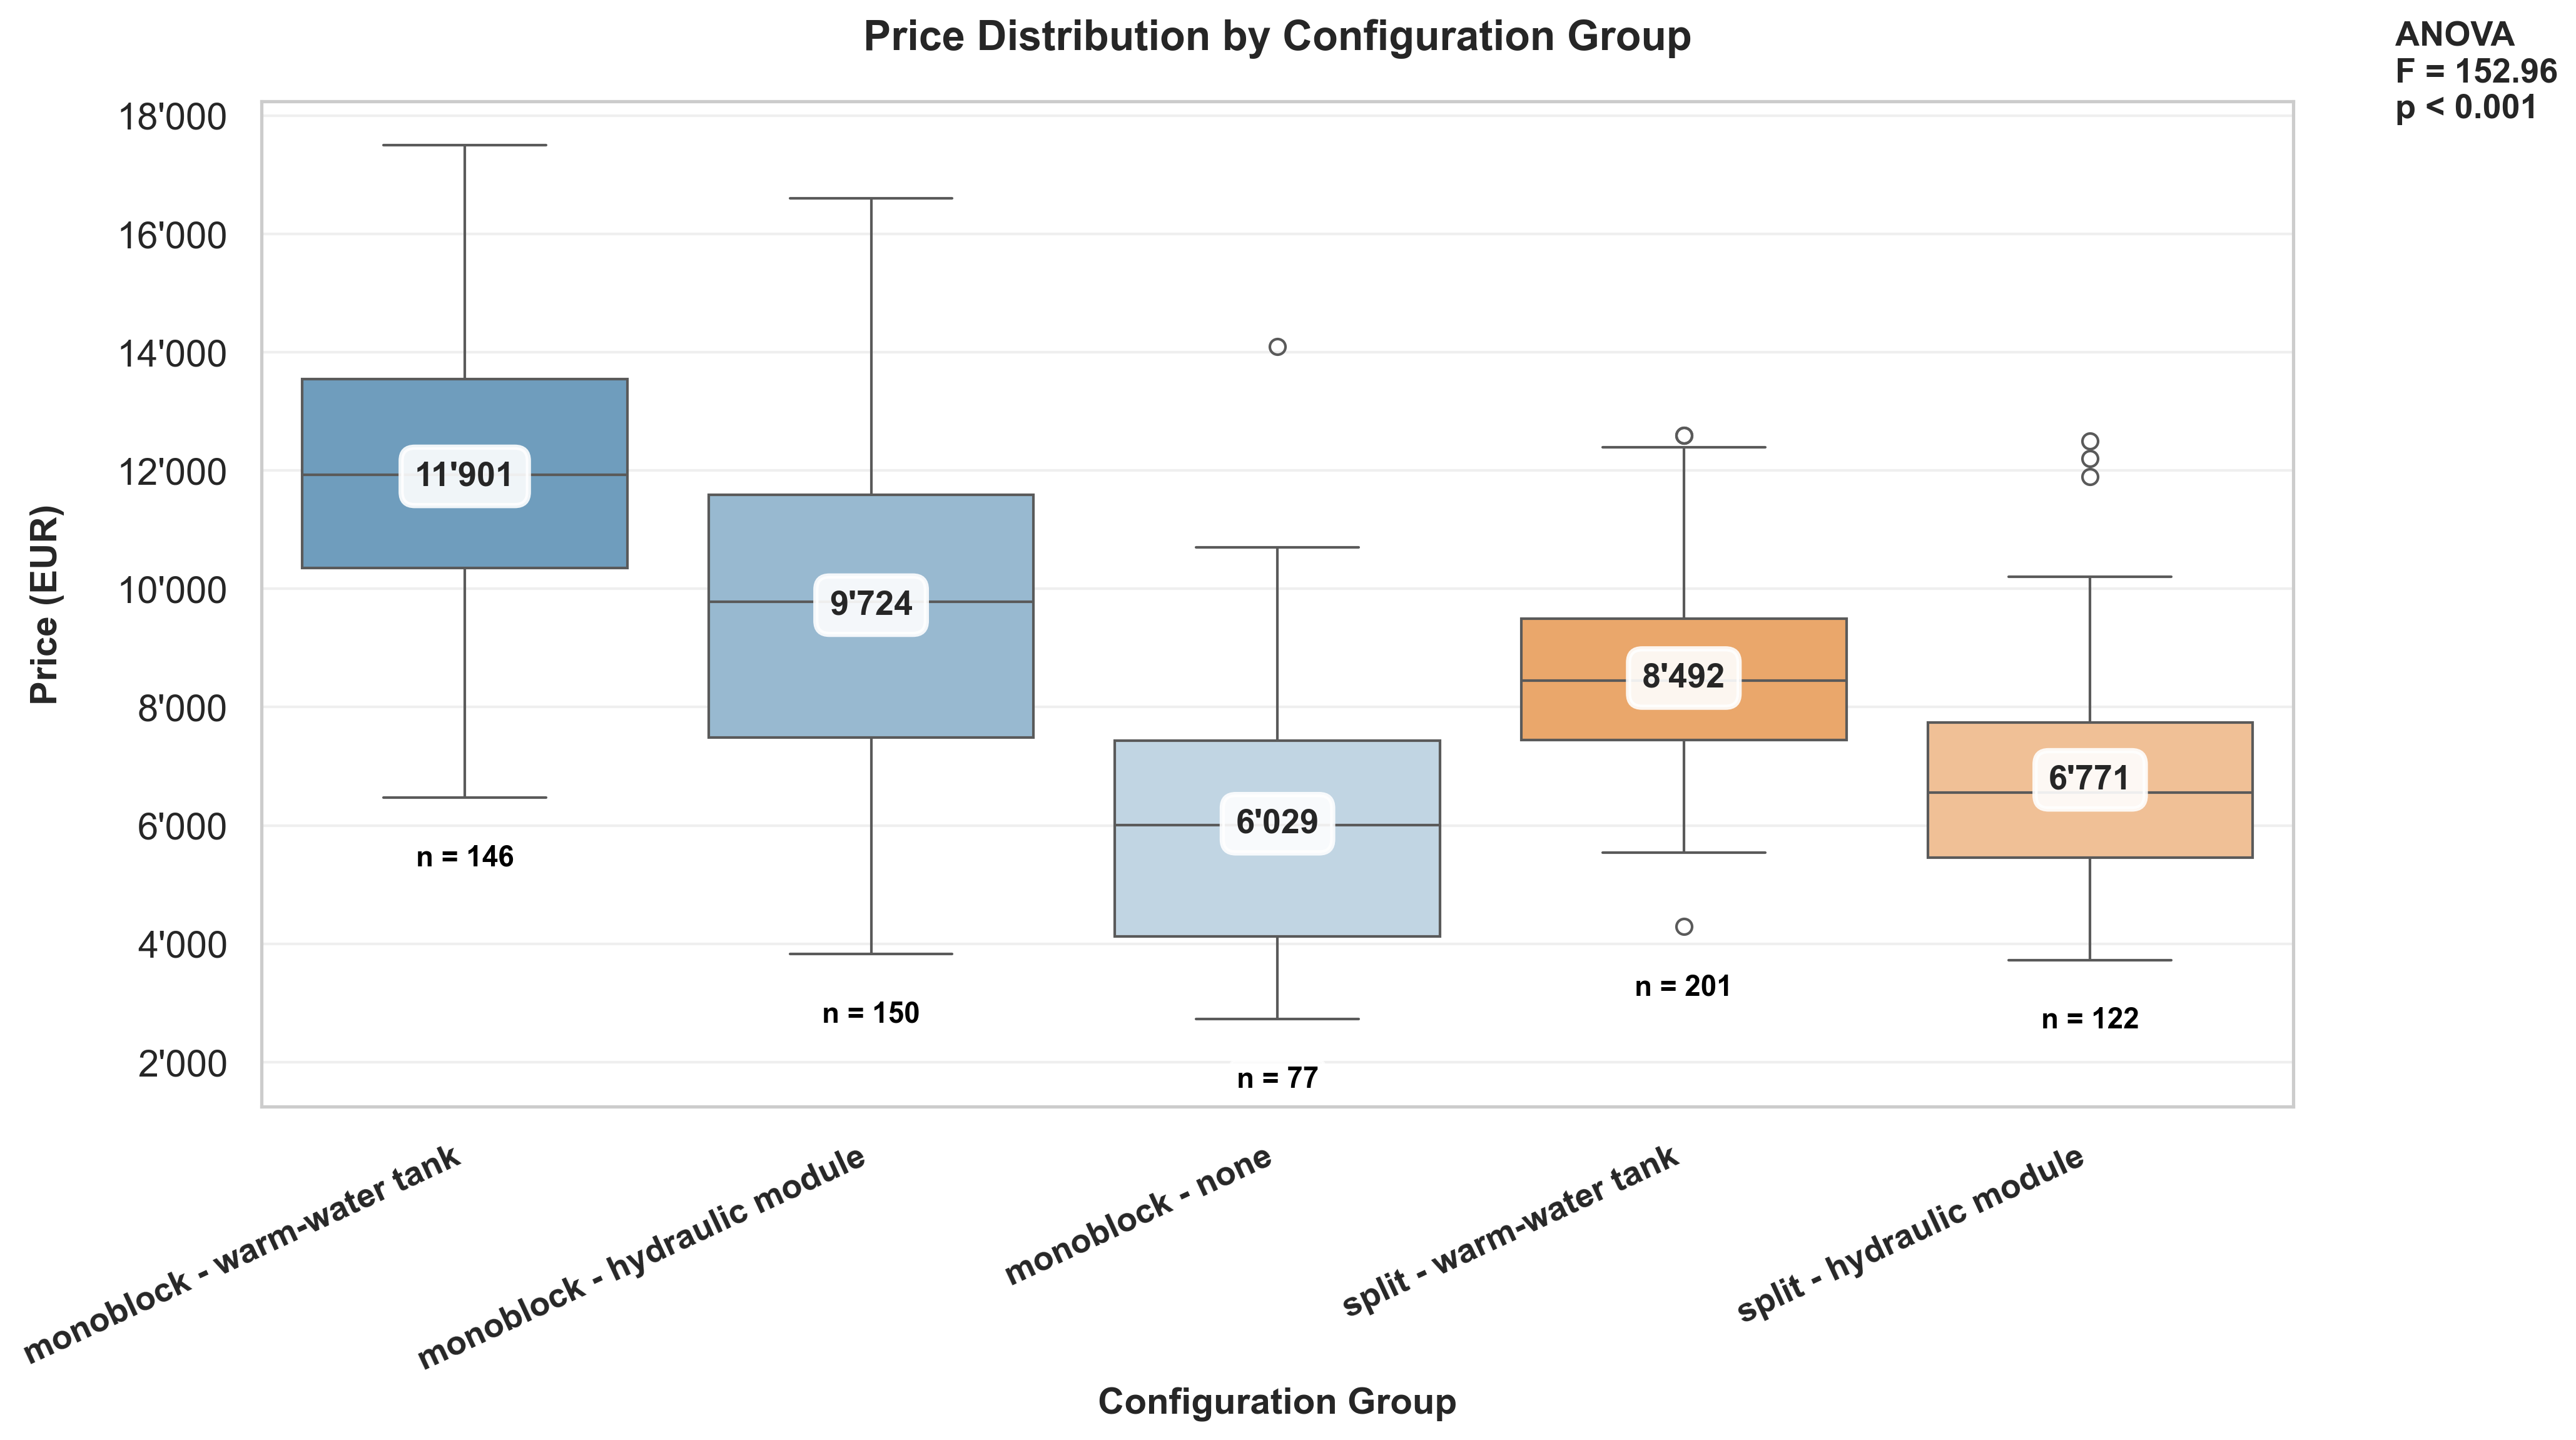

### Scop By Configuration

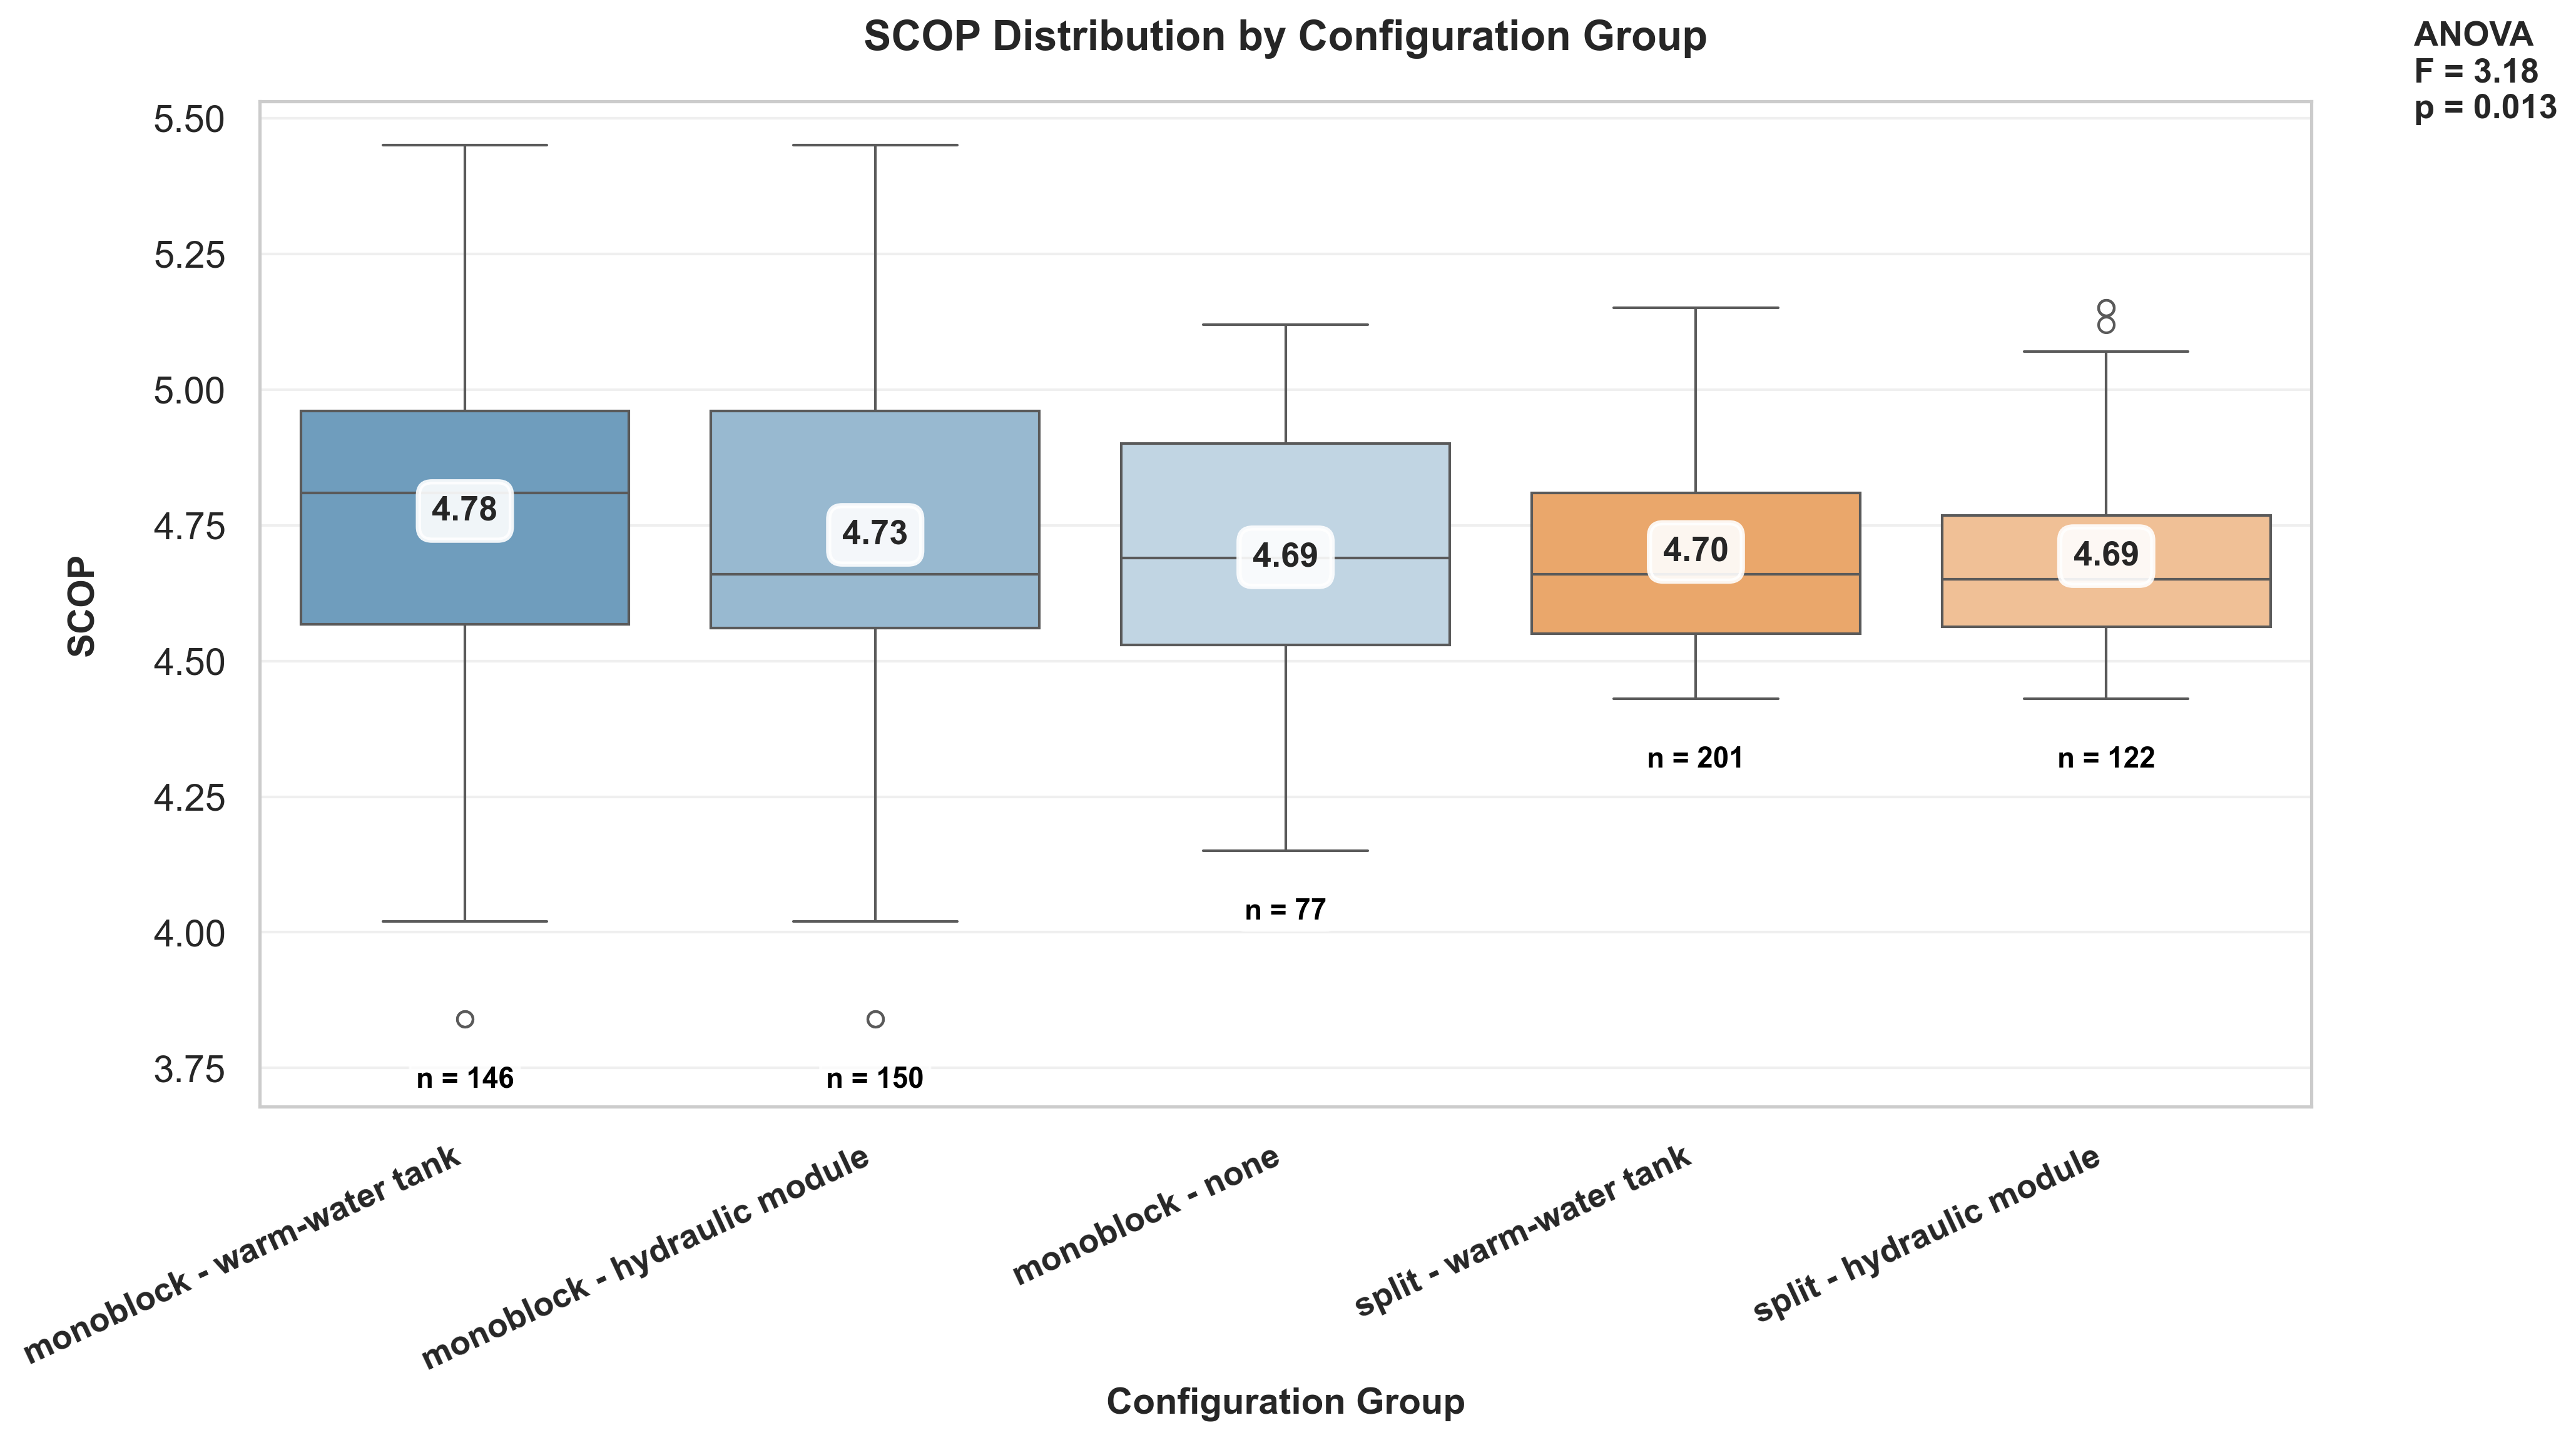

In [ ]:
# Create configuration comparison plots and display them inline
desc.create_configuration_comparisons(df, figures_dir)

# Display configuration comparison plots
config_image_files = [
    'price_by_configuration.png',
    'scop_by_configuration.png',
]

for img in config_image_files:
    path = figures_dir / img
    if path.exists():
        display(Markdown(f"### {img.replace('_', ' ').replace('.png','').title()}"))
        display(Image(filename=str(path)))
    else:
        print(f"Warning: {img} not found")


Refrigerant analysis plots saved to: reports\figures\descriptive_analysis


### Price By Refrigerant

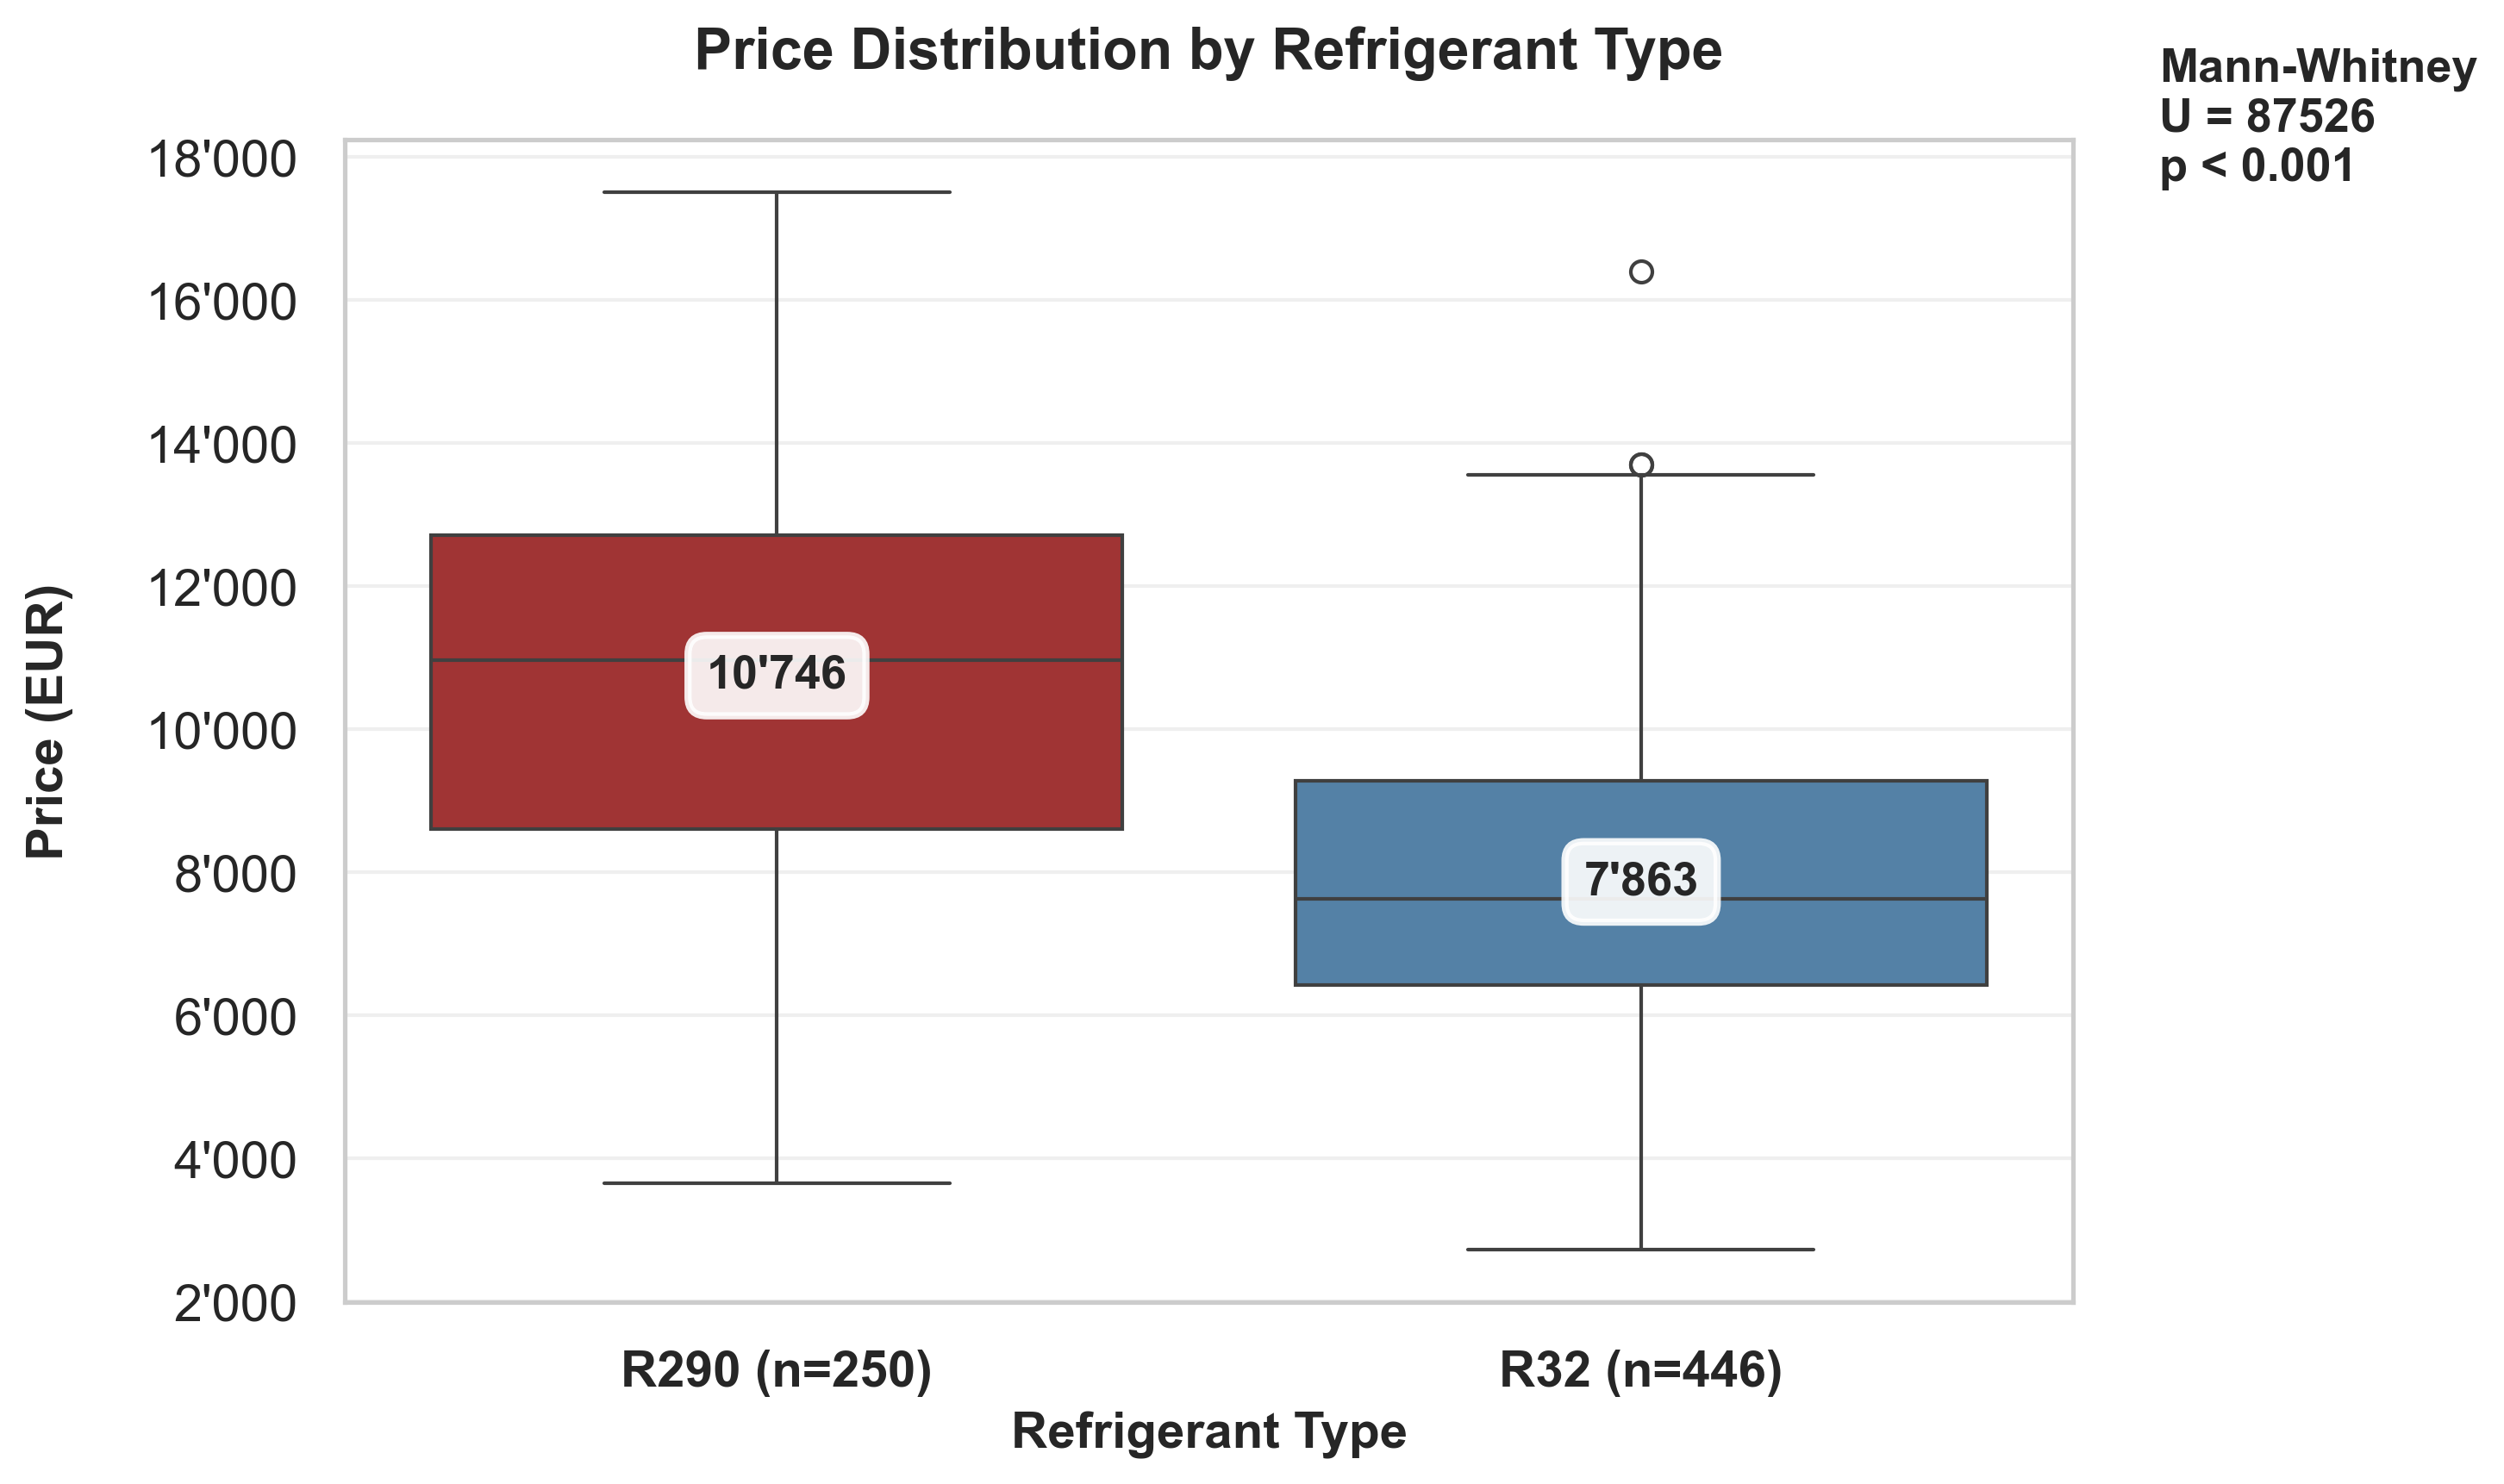

### Refrigerant Distribution

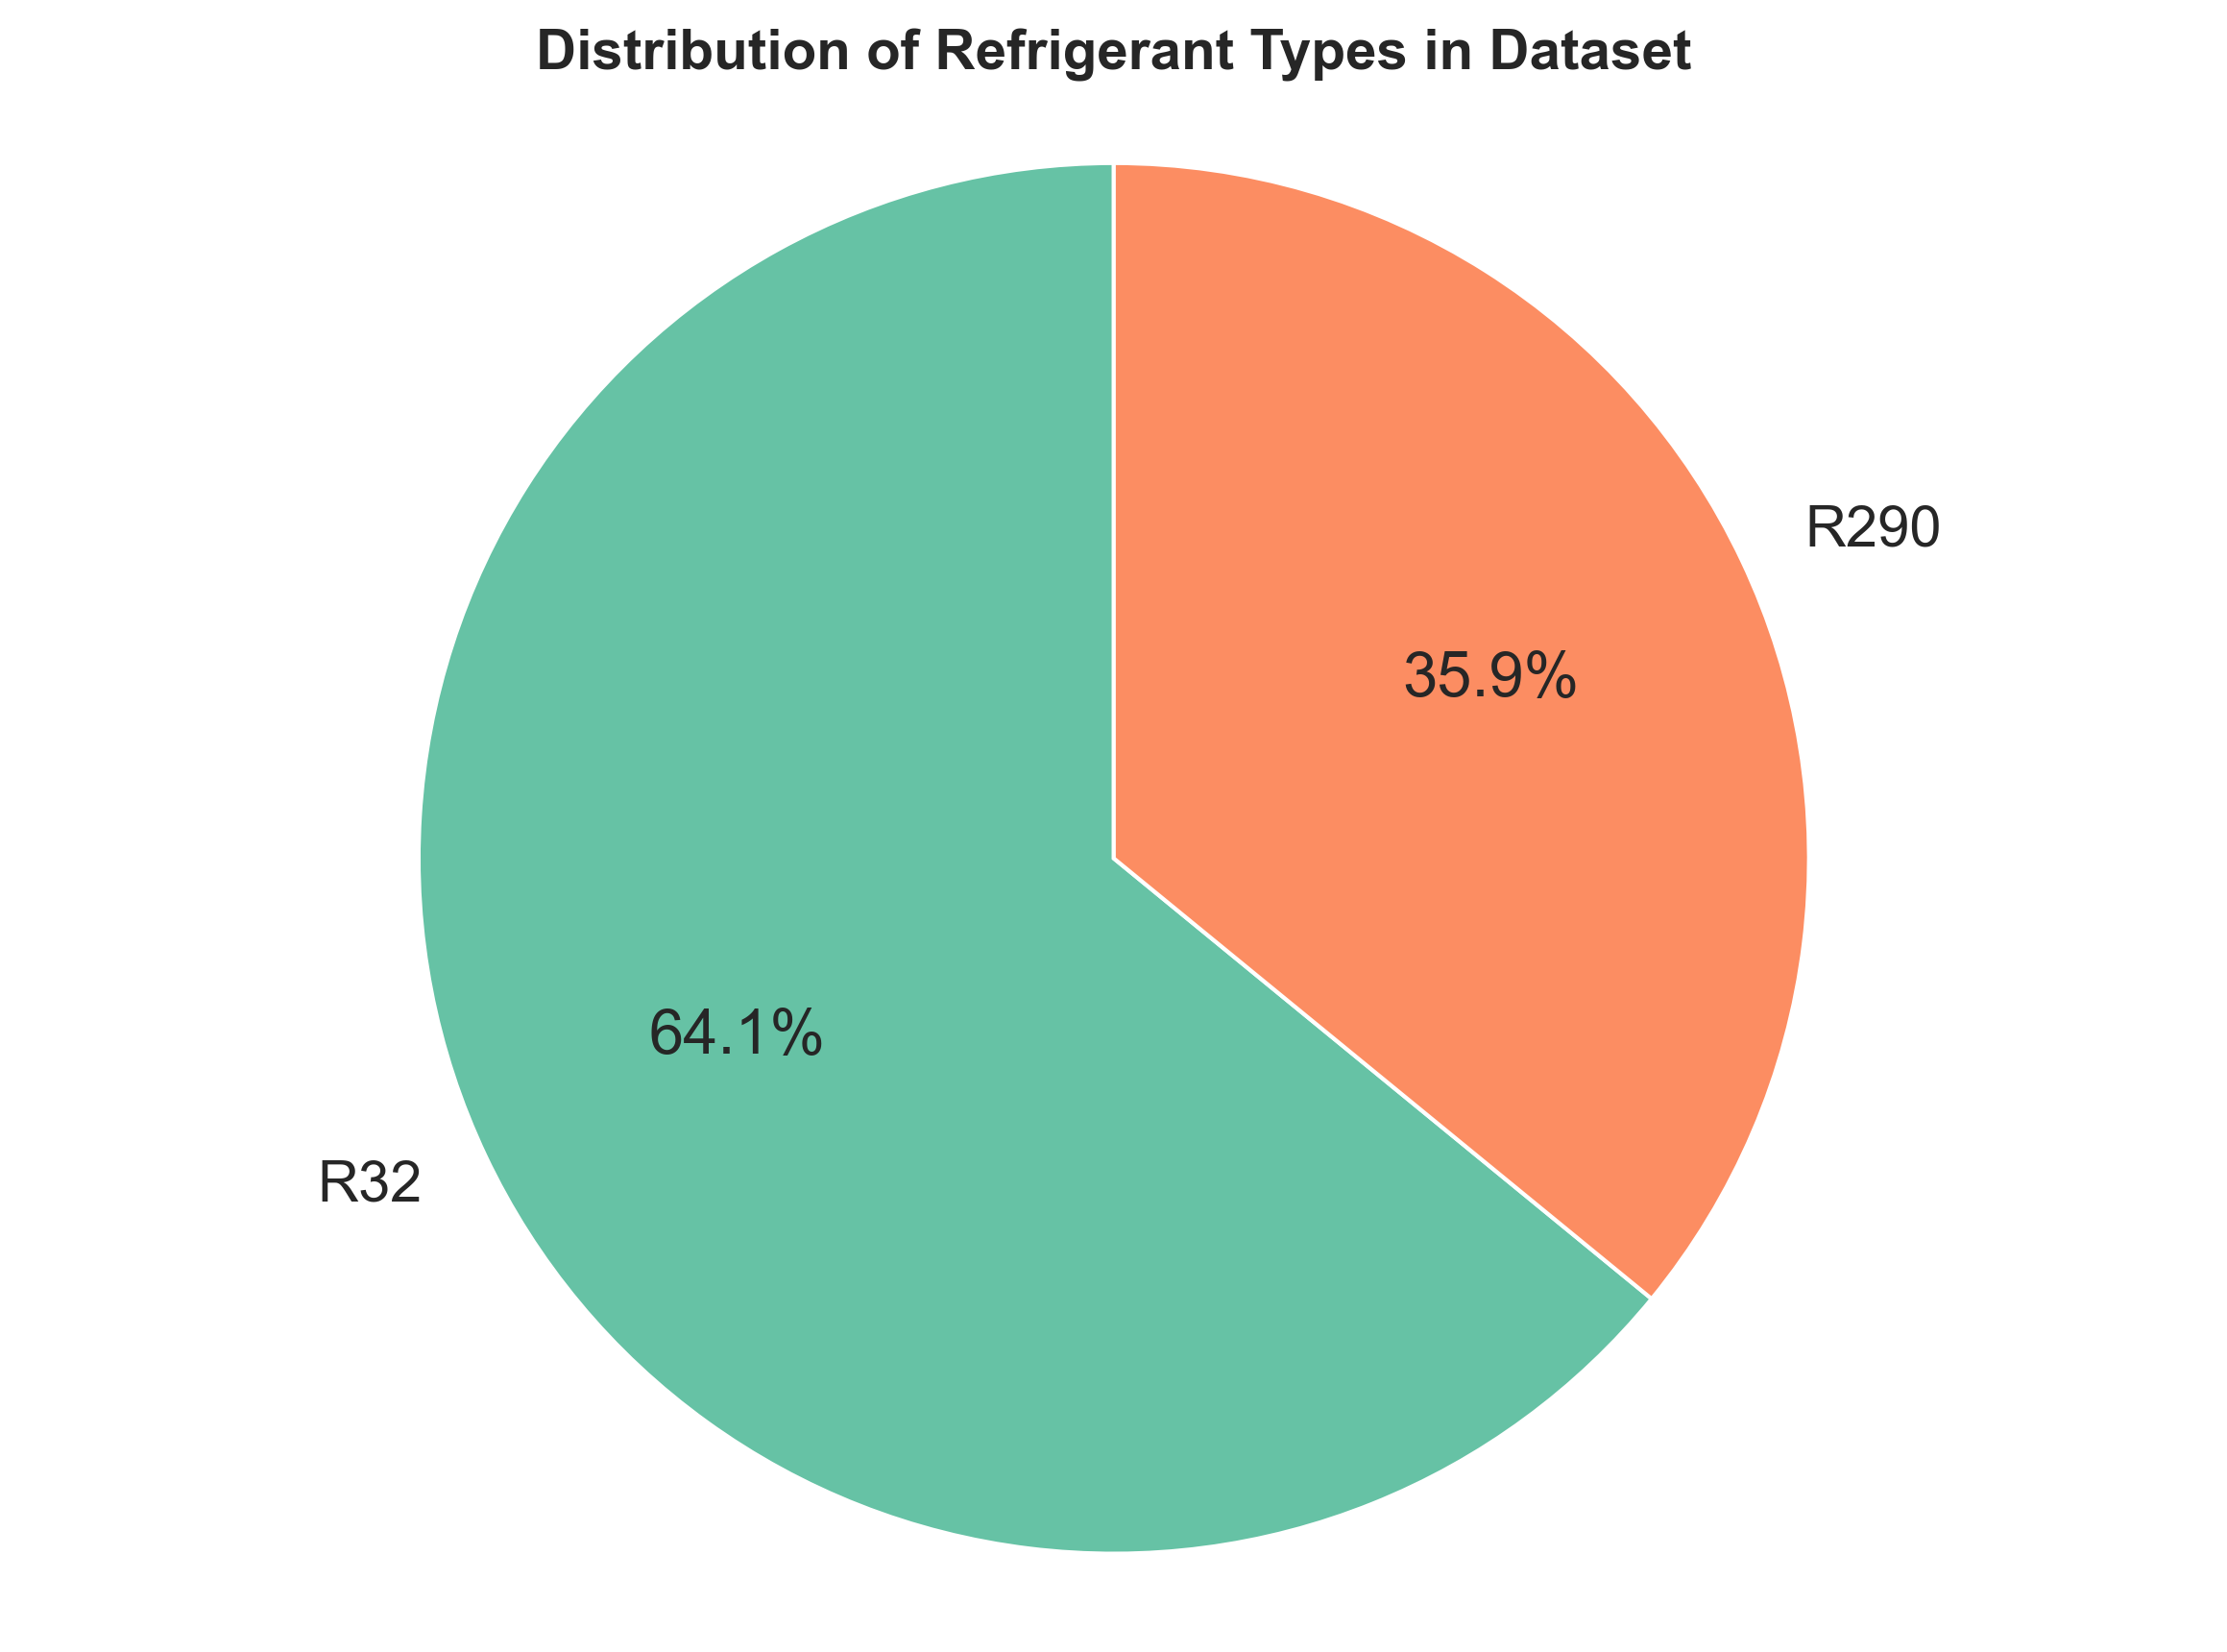

### Price By Refrigerant Per Configuration

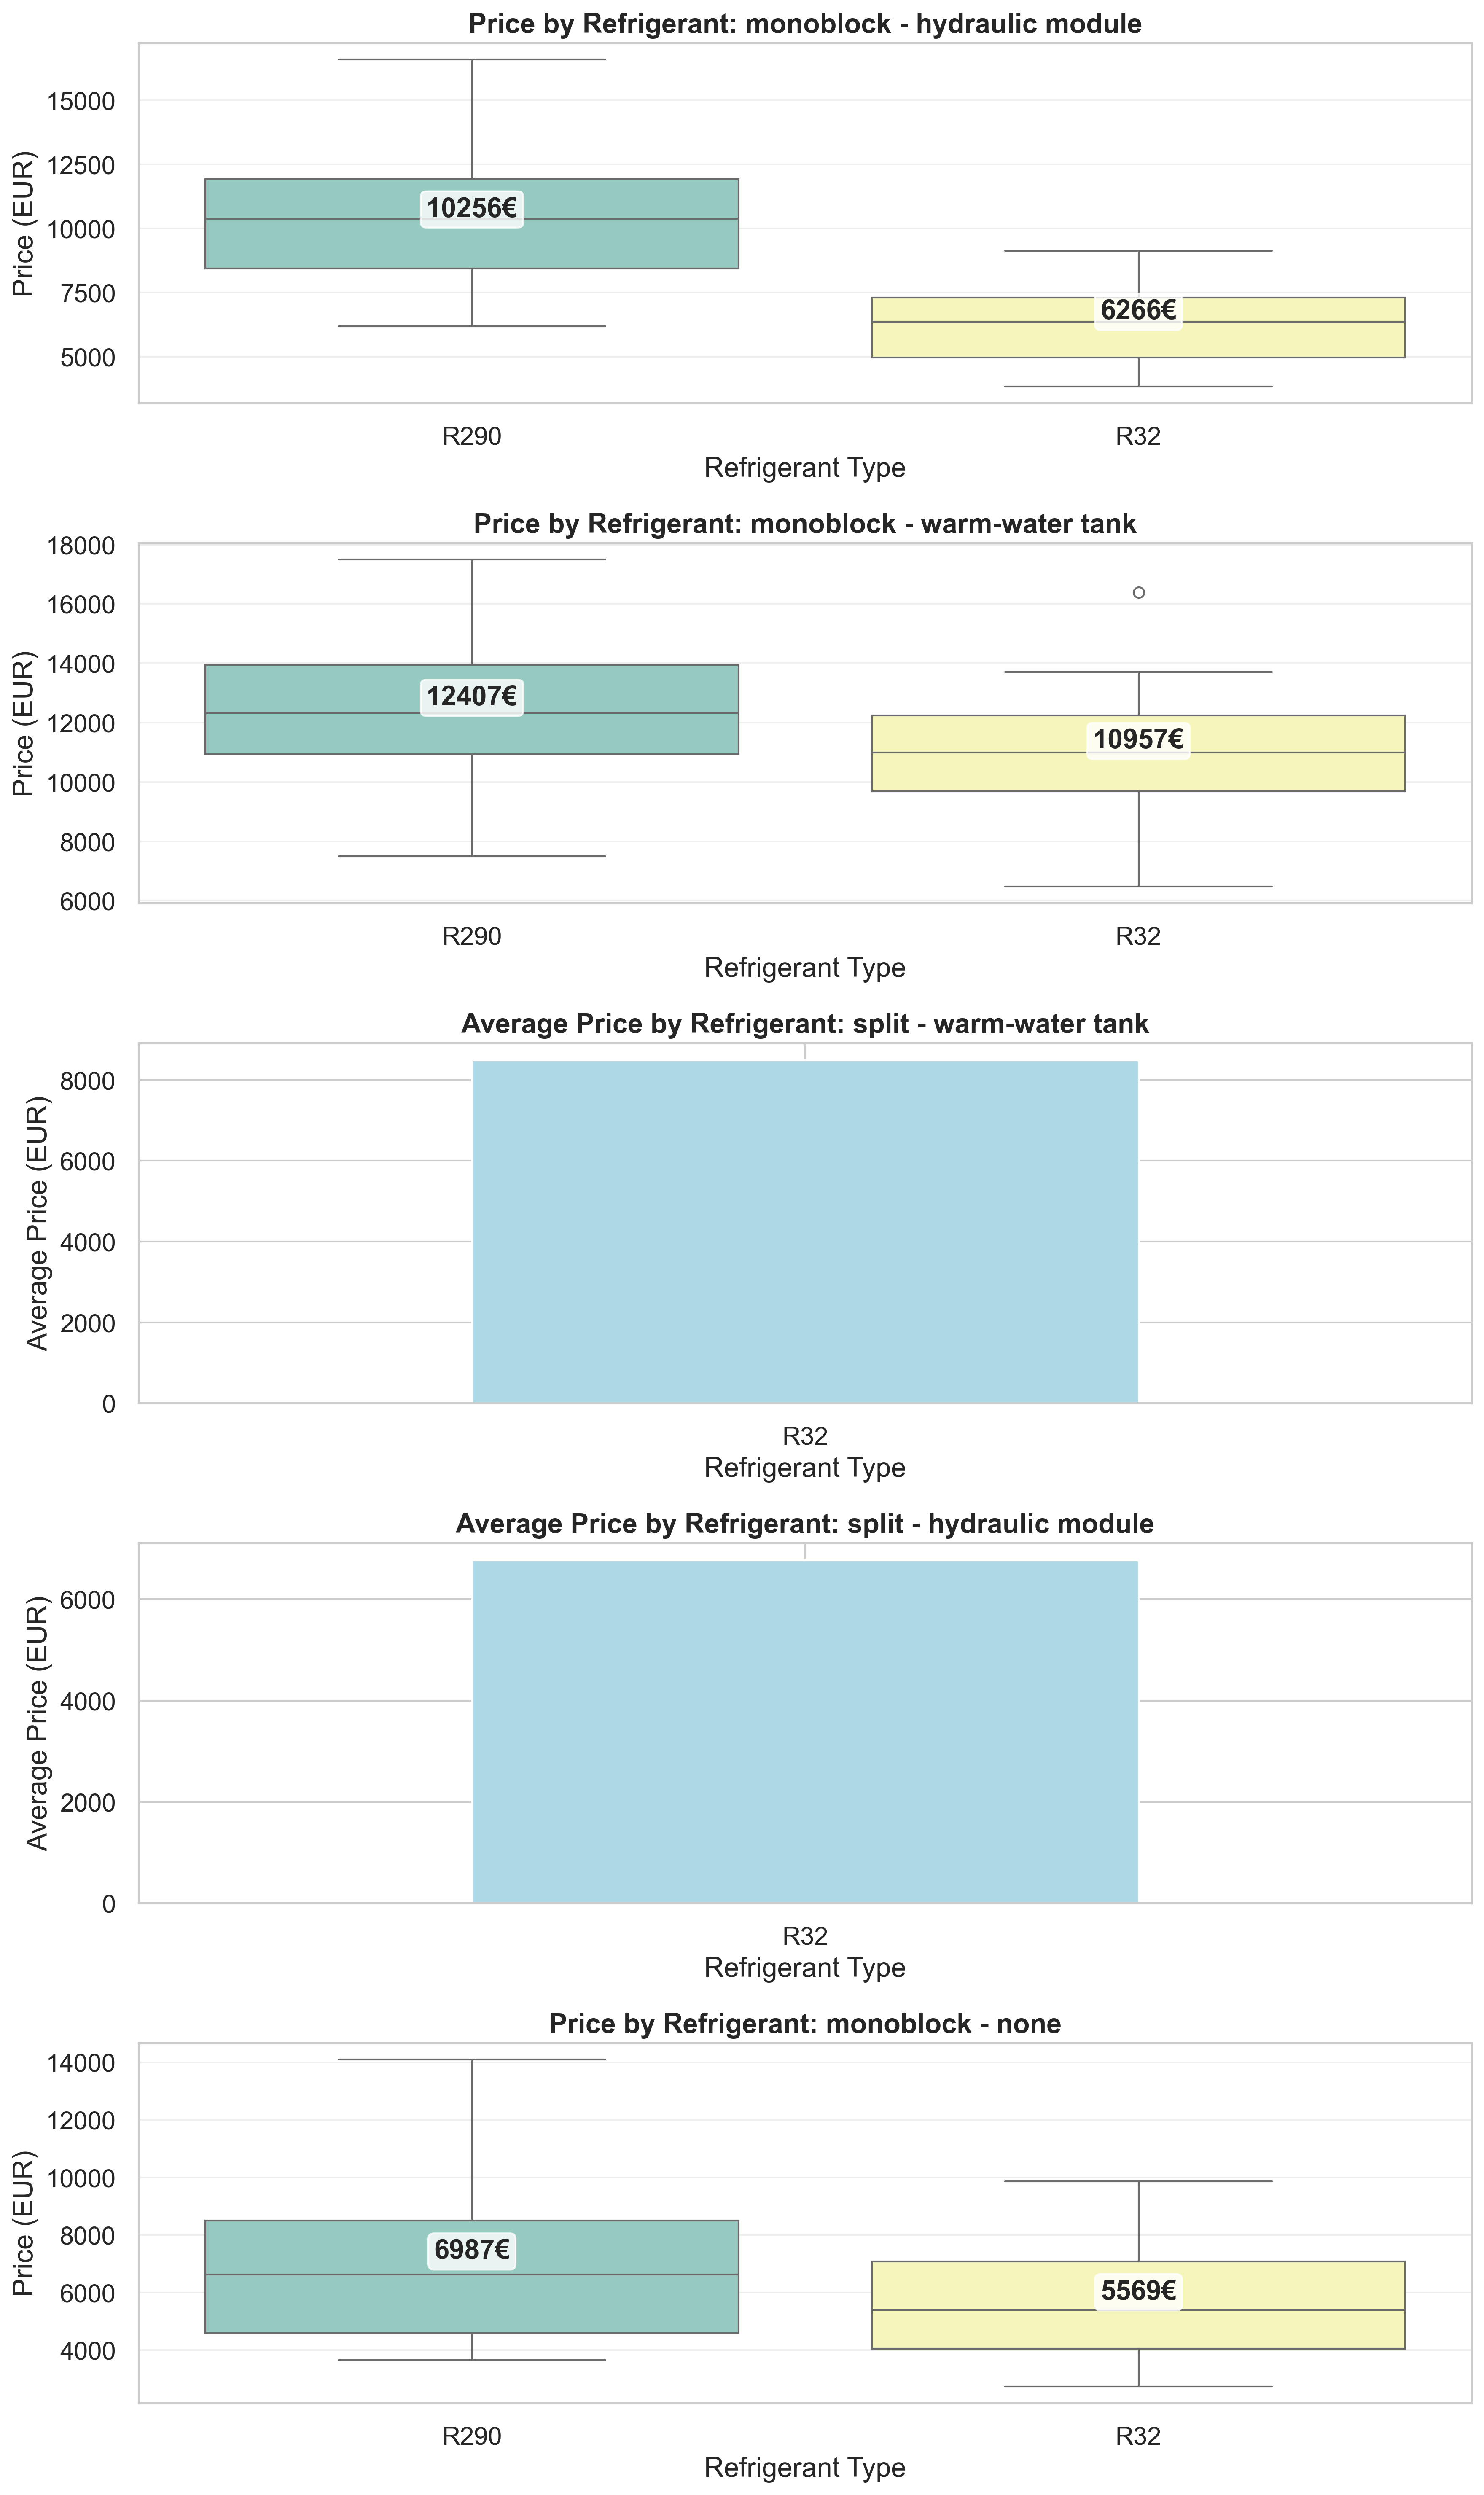

### Scop By Refrigerant

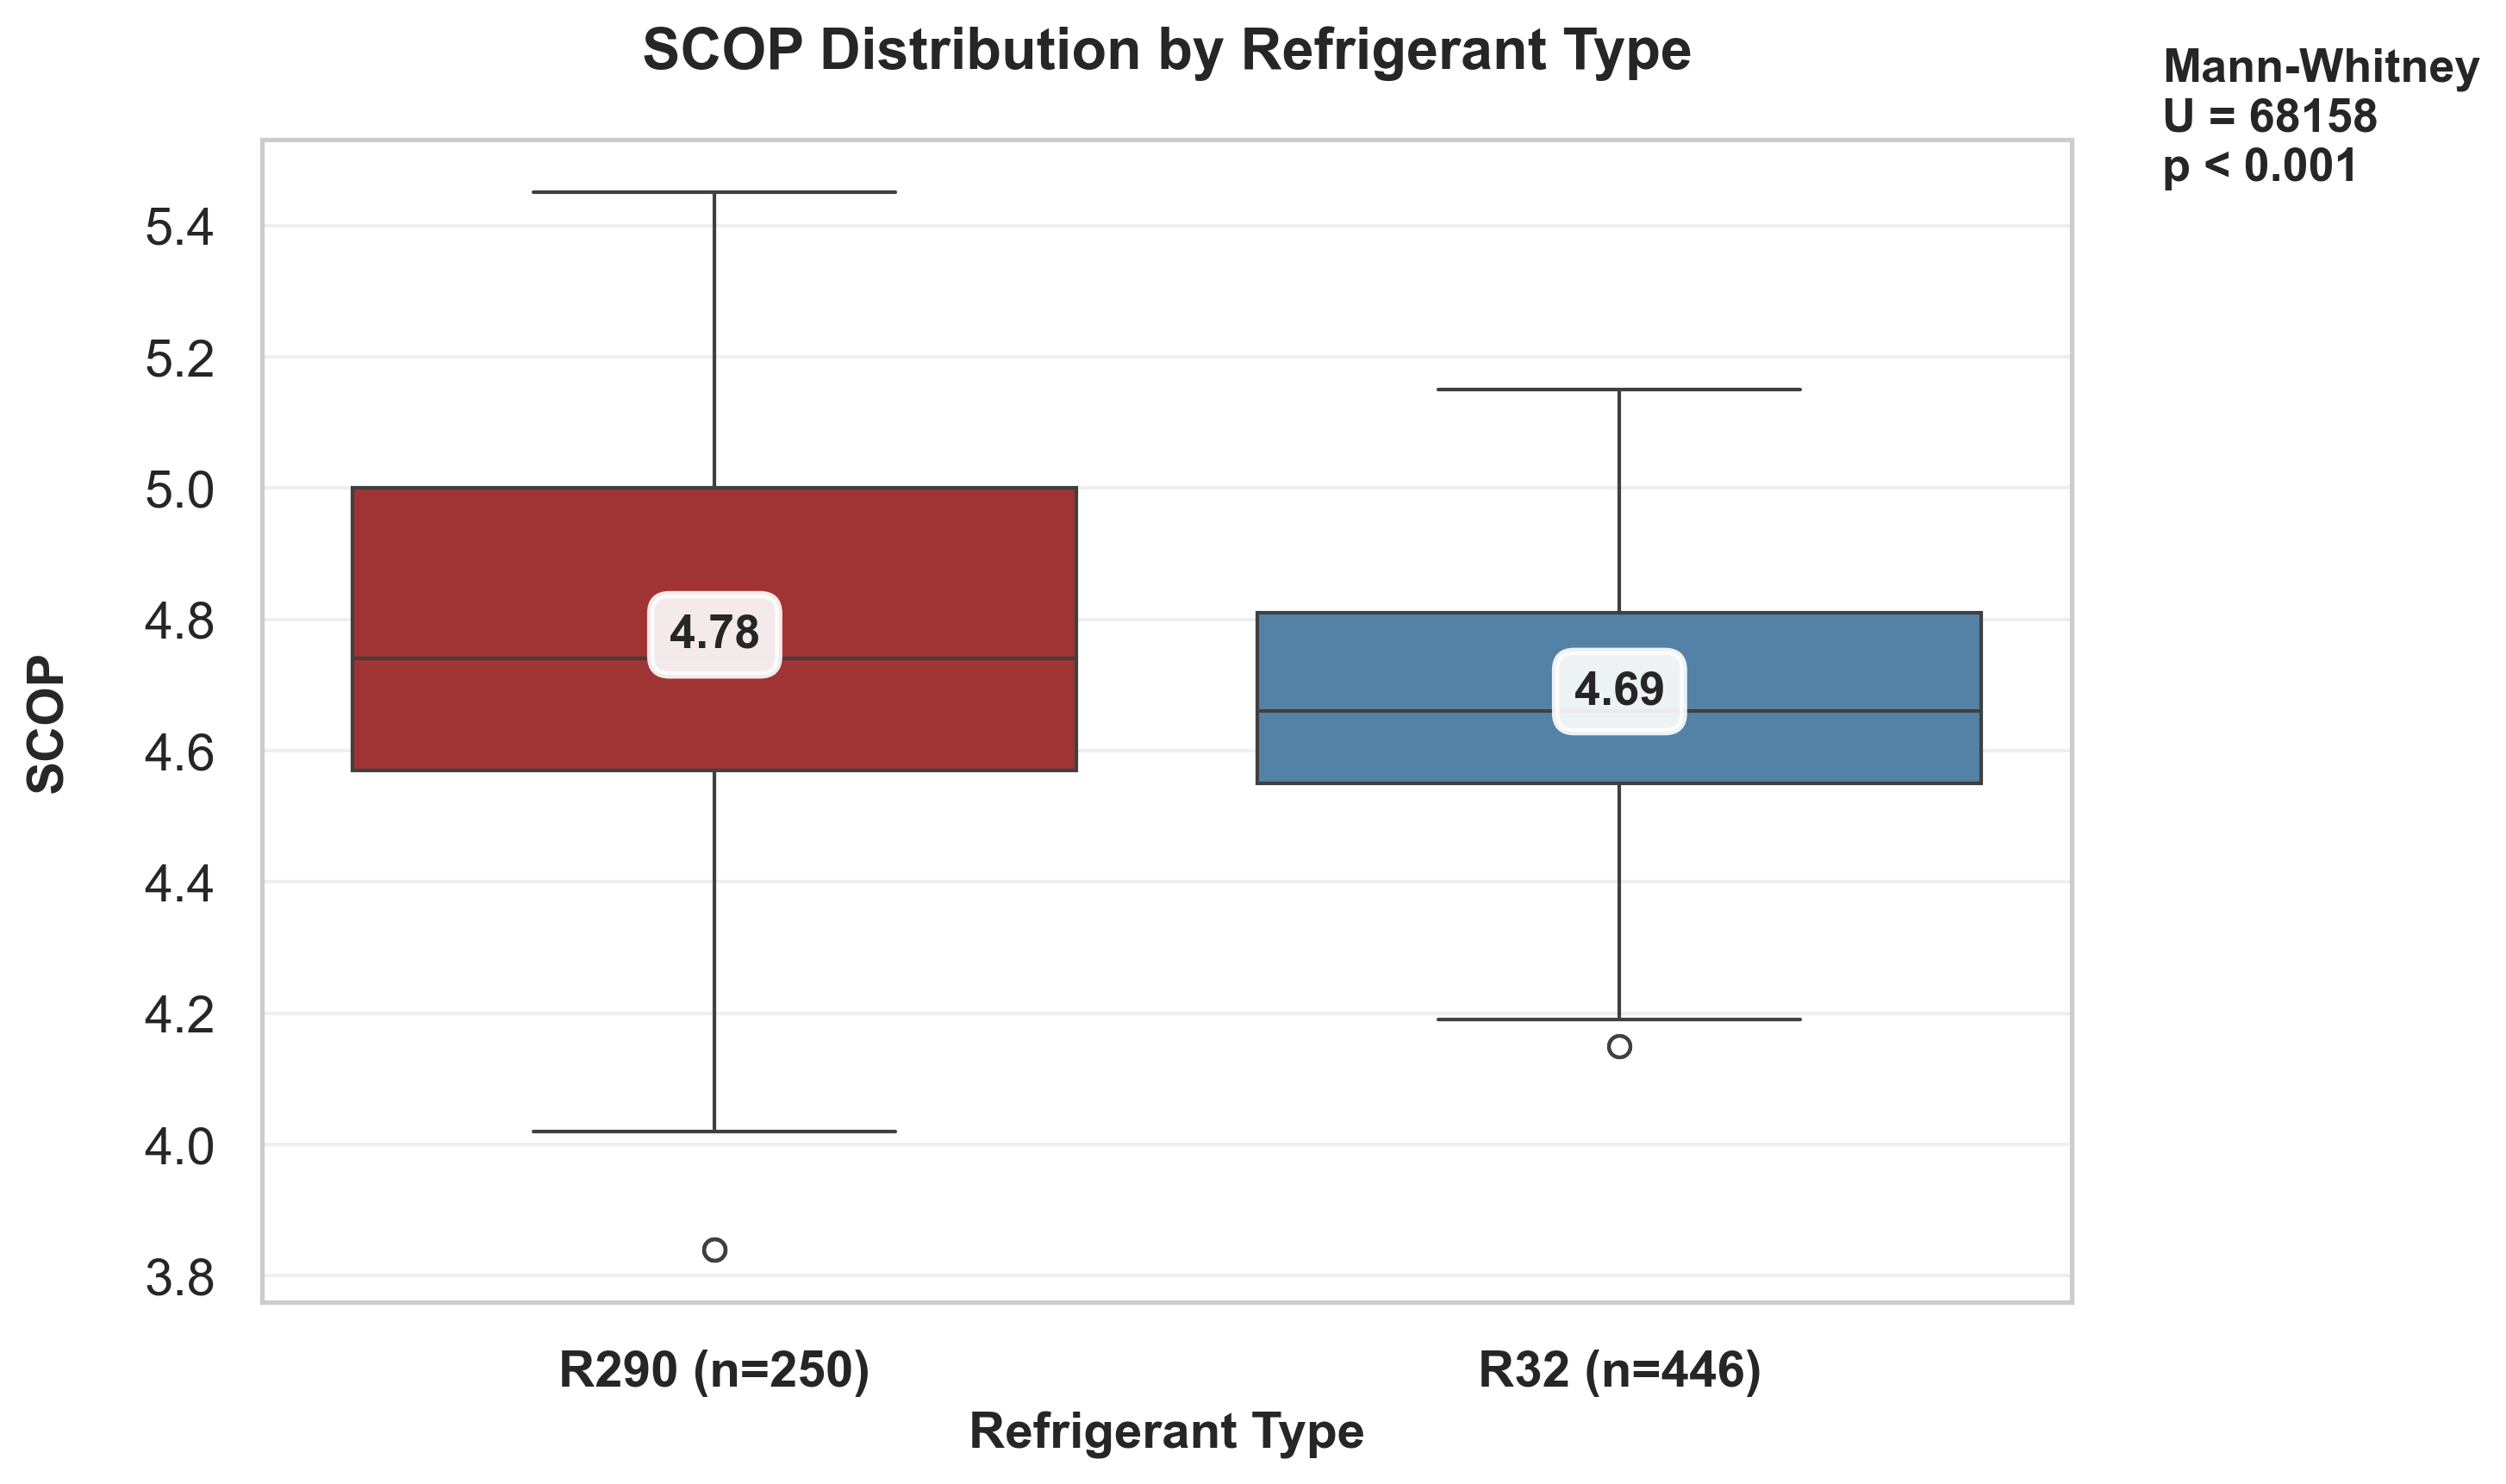

### Scop By Refrigerant Per Configuration

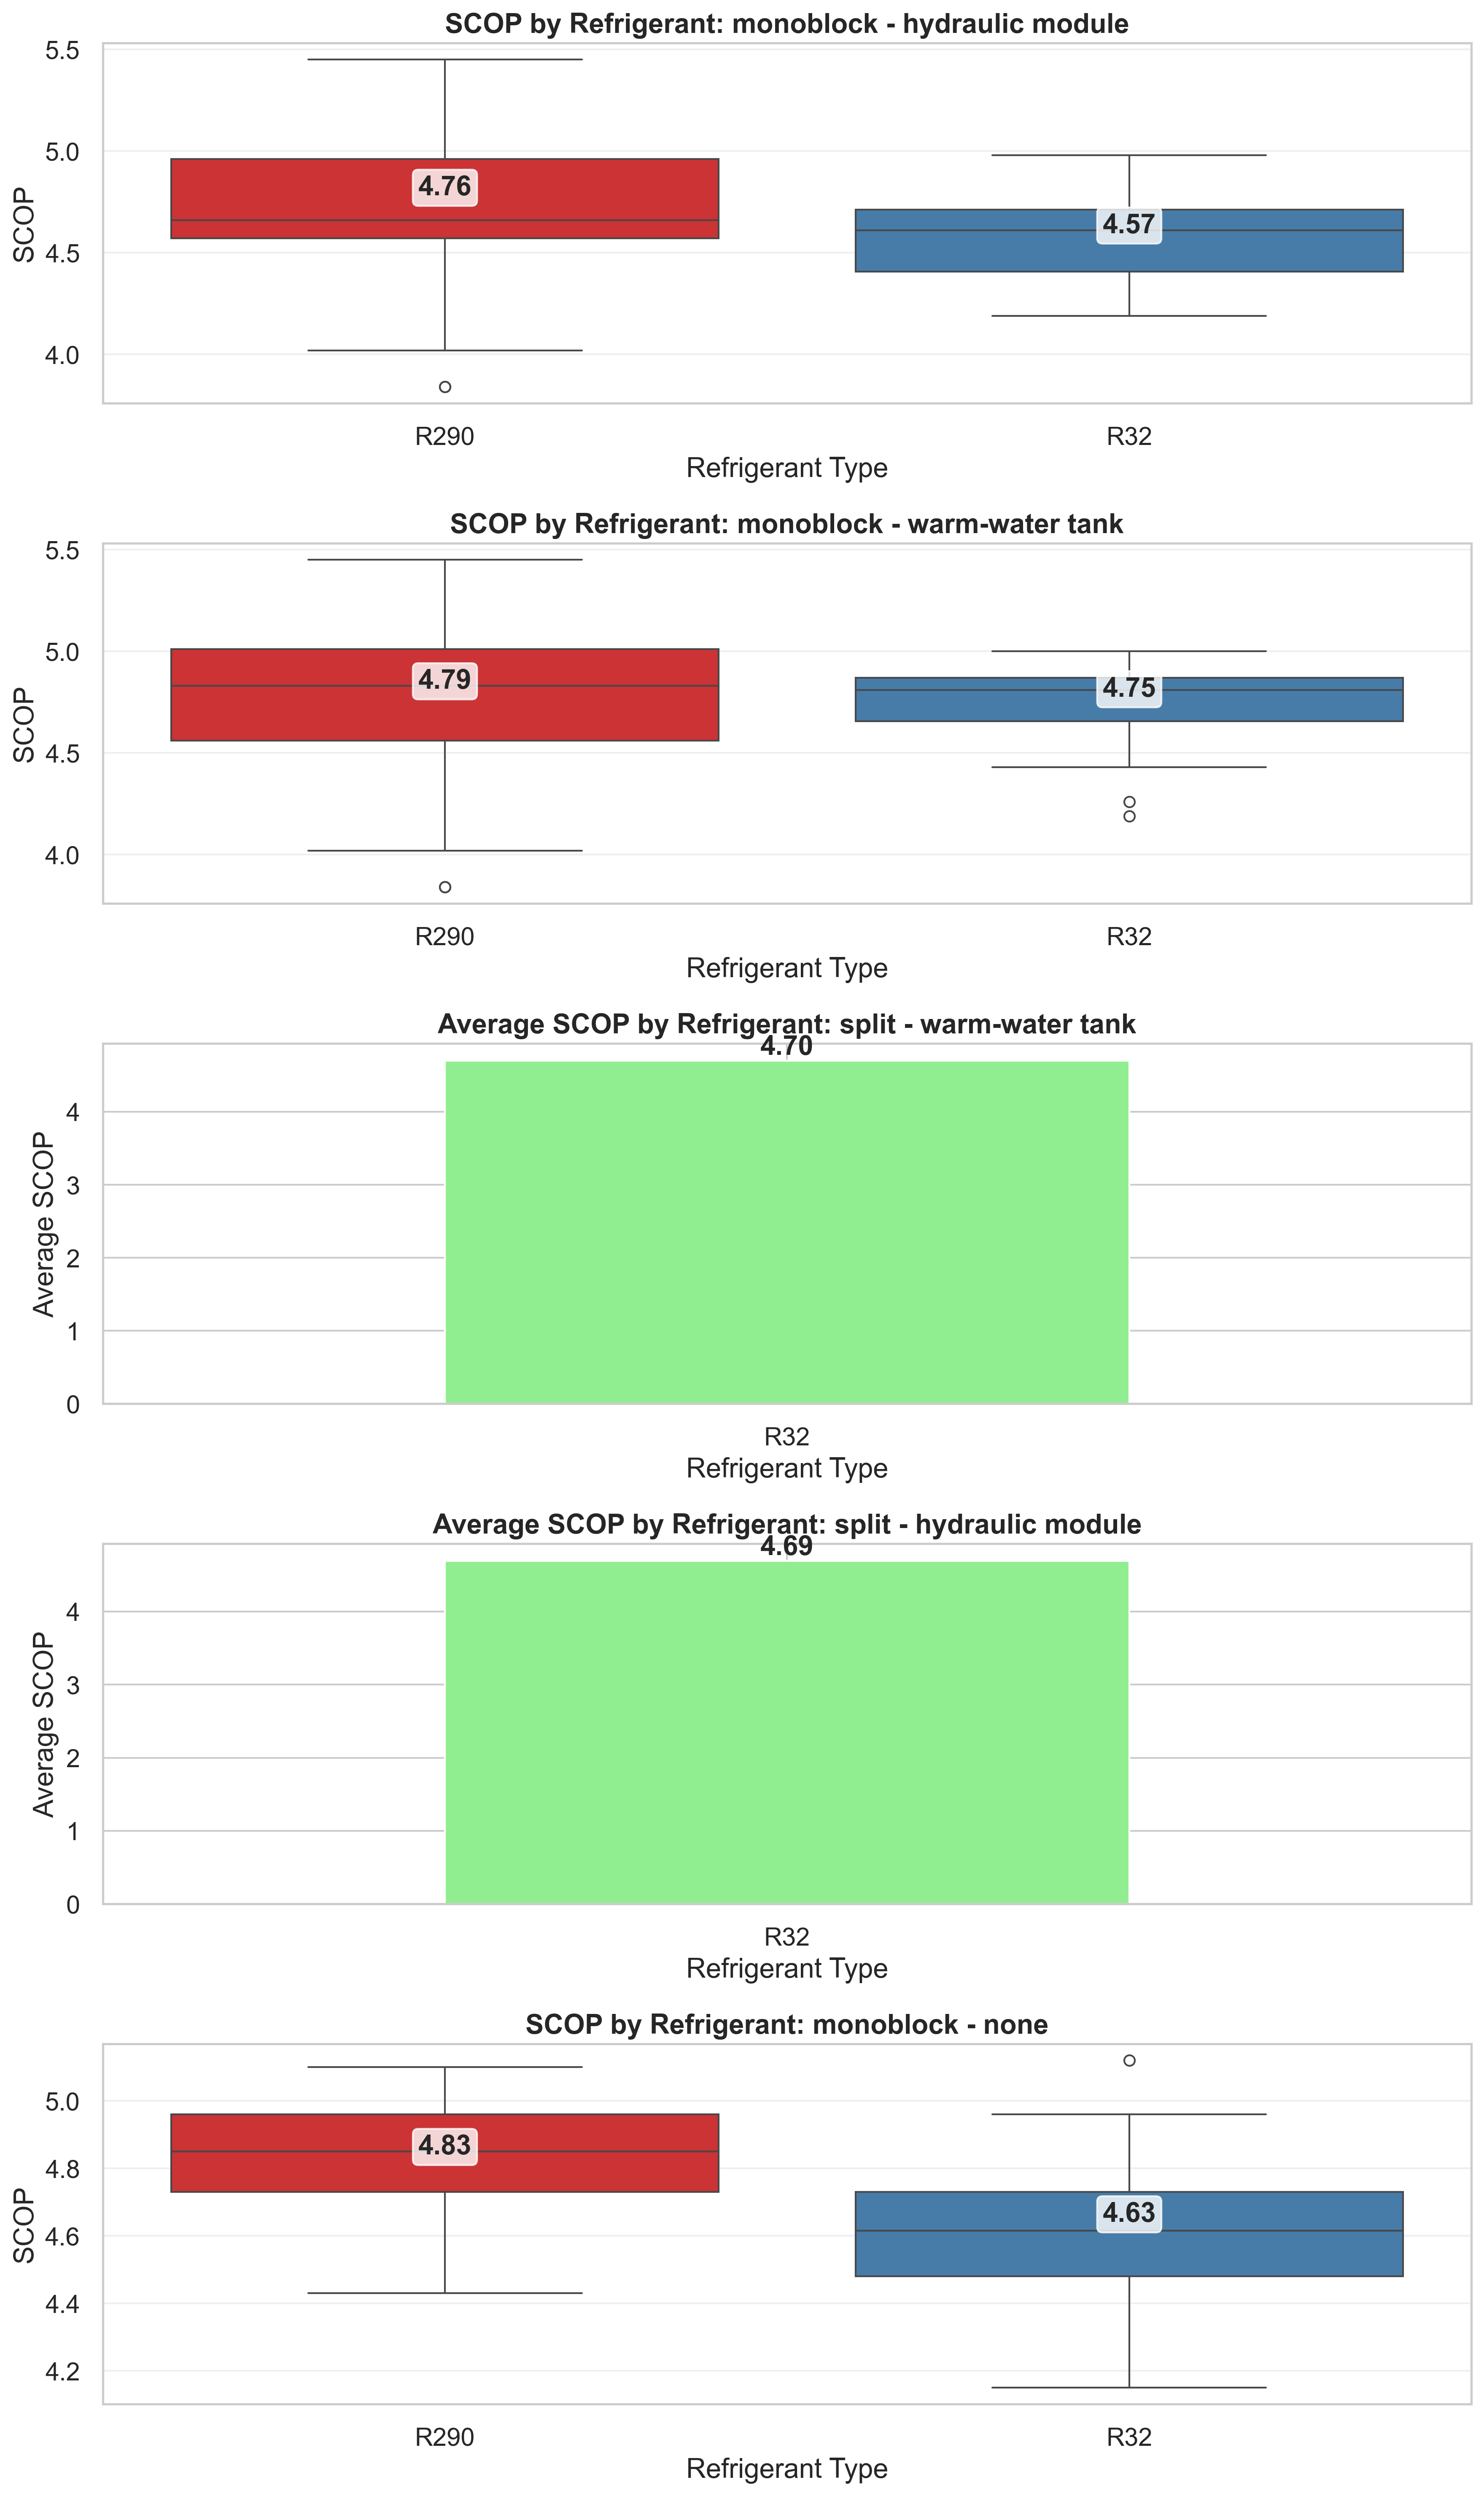

In [ ]:
# Create refrigerant analysis plots and display them inline
desc.create_refrigerant_analysis_plots(df, figures_dir)

# Display refrigerant analysis plots
refrigerant_image_files = [
    'price_by_refrigerant.png',
    'refrigerant_distribution.png',
    'price_by_refrigerant_per_configuration.png',
    'scop_by_refrigerant.png',
    'scop_by_refrigerant_per_configuration.png',
]

for img in refrigerant_image_files:
    path = figures_dir / img
    if path.exists():
        display(Markdown(f"### {img.replace('_', ' ').replace('.png','').title()}"))
        display(Image(filename=str(path)))
    else:
        print(f"Warning: {img} not found")


In [ ]:
# Perform ANOVA analysis
desc.perform_anova_analysis(df)



ANOVA (ANALYSIS OF VARIANCE) RESULTS
Testing for significant differences between configuration groups
Null Hypothesis (H0): All group means are equal
Alternative Hypothesis (H1): At least one group mean is different
Significance level: α = 0.05

Configuration groups being compared (5):
  1. monoblock - hydraulic module (n=150)
  2. monoblock - warm-water tank (n=146)
  3. split - warm-water tank (n=201)
  4. split - hydraulic module (n=122)
  5. monoblock - none (n=77)

ANOVA TEST: Price (EUR)

Group Statistics:
----------------------------------------------------------------------------------------------------
Group                          N     Mean       Std        Min        Max       
----------------------------------------------------------------------------------------------------
monoblock - hydraulic module   150   9723.64    2637.92    3831.00    16599.00  
monoblock - warm-water tank    146   11900.84   2263.32    6469.00    17499.00  
split - warm-water tank        201  

In [ ]:
# Perform refrigerant statistical tests
desc.perform_refrigerant_statistical_tests(df)



STATISTICAL TESTS: REFRIGERANT TYPE COMPARISONS
Testing for significant differences between R290 and R32 refrigerants
Null Hypothesis (H0): No significant difference between refrigerant types
Alternative Hypothesis (H1): Significant difference exists between refrigerant types
Significance level: α = 0.05

Sample sizes:
R290: 250 units
R32: 446 units

STATISTICAL TEST: Price (EUR) - R290 vs R32

Descriptive Statistics:
R290: n=250, mean=10746.476, std=2841.032
R32:  n=446, mean=7862.522, std=2260.397
Difference: 2883.954

Normality Tests (Shapiro-Wilk):
R290: p-value = 0.129008 (Normal)
R32:  p-value = 0.003236 (Non-normal)
Equal variances test (Levene): p-value = 0.000028 (Unequal)

Using: Mann-Whitney U test (non-parametric)
U-statistic: 87526.0000
p-value: 0.000000
Effect size (r): 0.4733
Effect size interpretation: medium

F-statistic Analysis (Variance Comparison):
R290 variance: 8071460.8287
R32 variance: 5109394.0521
F-statistic (variance ratio): 1.5797
F-statistic interpretatio